<div style="padding:30px 32px;border-radius:24px;background:linear-gradient(125deg,#102a43,#0f766e 52%,#f59e0b);color:white;box-shadow:0 16px 40px rgba(15,118,110,.25)">
  <div style="font-size:14px;letter-spacing:.16em;text-transform:uppercase;opacity:.86">Kaggriculture • Public Replay Distillation • Executed Submission</div>
  <h1 style="margin:.35em 0 .18em;font-size:43px;line-height:1.06">The 720-Turn Farm Tape</h1>
  <p style="font-size:19px;max-width:940px;margin:0;opacity:.96">Version 12 turns one publicly downloadable top-player replay into a tiny, no-I/O policy—then stress-tests it across seeds, opponents, and both seats.</p>
</div>

## What this notebook contributes

- the exact, standalone `main.py` and `submission.tar.gz`;
- a visual teardown of the farm's capital curve, crop rotation, herd, labor, geometry, and market actions;
- a broad untouched-seed cross-play gate against public and campaign controls;
- a direct falsification of the tempting **all-melons** strategy;
- an unusually simple starter: return the action scheduled for `obs.step`.

**Provenance first.** The action sequence was distilled from public episode **89256171**, played by [radiant-allomancer](https://www.kaggle.com/radiantallomancer) against **nishchal jain**. The public replay scored **130,895 vs 117,910**. This notebook does **not** claim the player's private source or strategy authorship. Kaggle's [competition rules](https://www.kaggle.com/competitions/kaggriculture/rules) state that replays, including actions, may be made publicly available and downloadable.

> Cross-play below is local evidence from the official simulator. It is not a public leaderboard score; only a completed Kaggle submission can establish that.


In [1]:
import hashlib, importlib.metadata, json, subprocess, sys, tarfile, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
COLORS = ["#0f766e", "#f59e0b", "#2563eb", "#7c3aed", "#dc2626", "#0891b2", "#64748b"]

required = (1, 32, 2)
try:
    installed_text = importlib.metadata.version("kaggle-environments")
    installed = tuple(int(x) for x in installed_text.split(".")[:3])
except Exception:
    installed_text, installed = "missing", (0, 0, 0)
if installed < required:
    print(f"Upgrading kaggle-environments {installed_text} -> 1.32.2")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "--no-deps", "kaggle-environments==1.32.2"],
        check=True,
    )
import kaggle_environments
from kaggle_environments import make
assert tuple(int(x) for x in kaggle_environments.__version__.split(".")[:3]) >= required
print("kaggle-environments", kaggle_environments.__version__)


Upgrading kaggle-environments 1.29.3 -> 1.32.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 29.8 MB/s eta 0:00:00


OpenSpiel exception: Unknown game 'capture_the_flag'. Available games are:
2048
add_noise
amazons
amazons_proxy
ant_foraging_arena
antichess
backgammon
backgammon_proxy
banqi
bargaining
bargaining_proxy
battleship
blackjack
blotto
breakthrough
bridge
bridge_arena
bridge_uncontested_bidding
cached_tree
catch
checkers
chess
chinese_checkers
cliff_walking
clobber
clobber_proxy
coin_game
coin_game_arena
colored_trails
connect_four
coop_box_pushing
coop_to_1p
coordinated_mp
crazy_eights
crazyhouse
cribbage
cursor_go
dark_chess
dark_hex
dark_hex_ir
deep_sea
dots_and_boxes
dots_and_boxes_proxy
dou_dizhu
efg_game
einstein_wurfelt_nicht
euchre
first_sealed_auction
gin_rummy
gin_rummy_proxy
go
gomoku
goofspiel
hanabi
havannah
havannah_proxy
hearts
hex
hive
kriegspiel
kuhn_poker
laser_tag
latent_ttt
leduc_poker
lewis_signaling
liars_dice
liars_dice_ir
lines_of_action
lines_of_action_proxy
maedn
mancala
mancala_proxy
markov_soccer
matching_pennies_3p
matrix_bos
matrix_brps
matrix_cd
matrix_coordin

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 40.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: OpenSpiel games skipped: 1.
kaggle-environments 1.32.2


OpenSpiel exception: Unknown game 'capture_the_flag'. Available games are:
2048
add_noise
amazons
amazons_proxy
ant_foraging_arena
antichess
backgammon
backgammon_proxy
banqi
bargaining
bargaining_proxy
battleship
blackjack
blotto
breakthrough
breakthrough_proxy
bridge
bridge_arena
bridge_uncontested_bidding
cached_tree
catch
chat_game
checkers
checkers_proxy
chess
chinese_checkers
cliff_walking
clobber
clobber_proxy
coin_game
coin_game_arena
coin_game_proxy
colored_trails
connect_four
connect_four_proxy
coop_box_pushing
coop_to_1p
coordinated_mp
crazy_eights
crazyhouse
cribbage
cursor_go
dark_chess
dark_hex
dark_hex_ir
dark_hex_proxy
deep_sea
dots_and_boxes
dots_and_boxes_proxy
dou_dizhu
efg_game
einstein_wurfelt_nicht
euchre
first_sealed_auction
gin_rummy
gin_rummy_proxy
go
go_proxy
gomoku
goofspiel
hanabi
havannah
havannah_proxy
hearts
hex
hive
hive_proxy
kriegspiel
kuhn_poker
laser_tag
latent_ttt
leduc_poker
lewis_signaling
liars_dice
liars_dice_ir
lines_of_action
lines_of_action_p

## 1. Why a fixed tape can work

Kaggriculture has stochastic weeds and shared prices, but the board geometry, 30-day clock, action cadence, and core growth rules are stable. A high-quality tape can therefore encode an entire capital schedule: buy productive assets early, unlock land on time, keep labor ahead of the job queue, and liquidate before the final bell. Invalid or unavailable commands degrade harmlessly while the rest of the day's parallel commands still execute.

The strength is also the limitation: the tape observes only `step`. It does not adapt to a rival's farm or recover intelligently from a major state divergence. Treat it as a high-scoring launchpad and a compressed behavioral dataset—not as the final form of an adaptive agent.


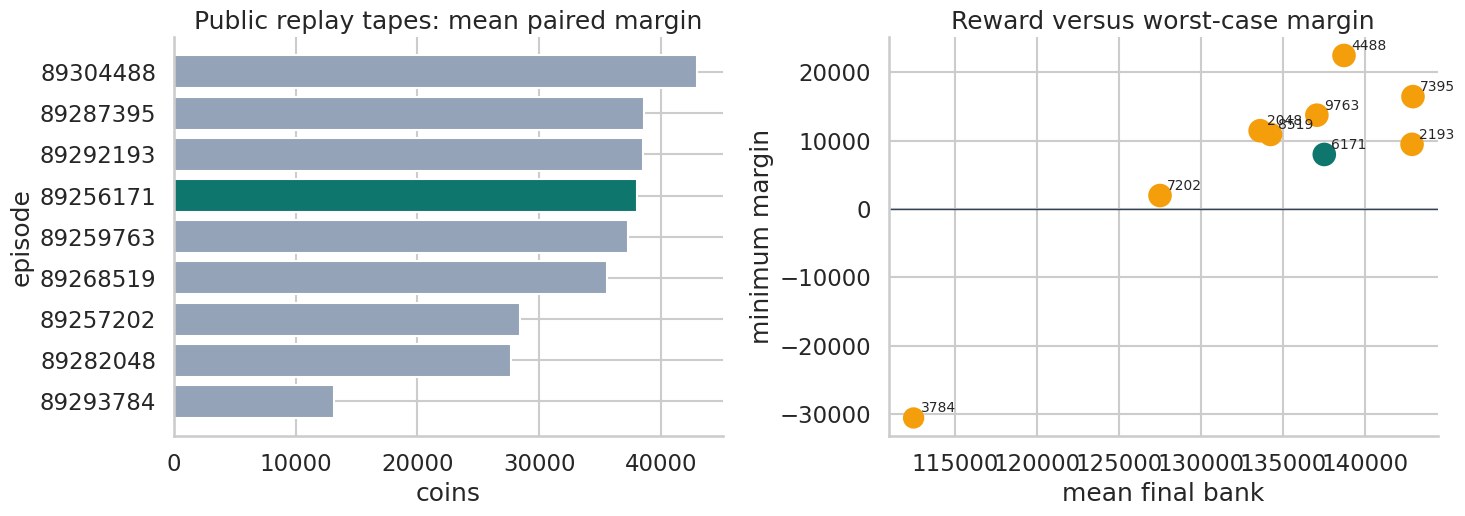

,challenger,games,wins,mean_money,mean_margin,min_margin,win_rate,episode
8,radianttrace:89304488,20,20,138742.30,42923.30,22451.0,1.0,89304488
5,radianttrace:89287395,20,20,142954.70,38599.45,16432.0,1.0,89287395
6,radianttrace:89292193,20,20,142898.45,38525.95,9456.0,1.0,89292193
0,radianttrace:89256171,20,20,137537.05,38044.70,7975.0,1.0,89256171
2,radianttrace:89259763,20,20,137083.95,37307.55,13718.0,1.0,89259763
3,radianttrace:89268519,20,20,134256.60,35561.90,10904.0,1.0,89268519
1,radianttrace:89257202,20,20,127502.65,28383.00,1970.0,1.0,89257202
4,radianttrace:89282048,20,20,133618.85,27673.40,11447.0,1.0,89282048
7,radianttrace:89293784,20,14,112451.80,13166.30,-30556.0,0.7,89293784


In [2]:
SCREEN_ROWS = [{'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 0, 'candidate_money': 112114.0, 'opponent_money': 104139.0, 'margin': 7975.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.476288208999904}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 1, 'candidate_money': 112114.0, 'opponent_money': 104139.0, 'margin': 7975.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.471896625000227}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 0, 'candidate_money': 118660.0, 'opponent_money': 95256.0, 'margin': 23404.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.349183833001007}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 1, 'candidate_money': 129755.0, 'opponent_money': 100182.0, 'margin': 29573.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.503563042002497}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 0, 'candidate_money': 140973.0, 'opponent_money': 117541.0, 'margin': 23432.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.435328416002449}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 1, 'candidate_money': 142978.0, 'opponent_money': 117663.0, 'margin': 25315.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.3117146249969664}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 0, 'candidate_money': 120153.0, 'opponent_money': 96475.0, 'margin': 23678.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.455173583999567}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 1, 'candidate_money': 137266.0, 'opponent_money': 103775.0, 'margin': 33491.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.473970292001468}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 0, 'candidate_money': 150012.0, 'opponent_money': 117116.0, 'margin': 32896.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.4034319589991355}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 1, 'candidate_money': 150018.0, 'opponent_money': 117232.0, 'margin': 32786.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.44050545799837}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 0, 'candidate_money': 133947.0, 'opponent_money': 106212.0, 'margin': 27735.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.491674875000172}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 1, 'candidate_money': 135406.0, 'opponent_money': 96366.0, 'margin': 39040.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.28346645900092}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 0, 'candidate_money': 159394.0, 'opponent_money': 82374.0, 'margin': 77020.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.794199249998201}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 1, 'candidate_money': 158420.0, 'opponent_money': 83923.0, 'margin': 74497.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.839737500002229}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 0, 'candidate_money': 137433.0, 'opponent_money': 68547.0, 'margin': 68886.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.958818874998542}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 1, 'candidate_money': 142897.0, 'opponent_money': 69688.0, 'margin': 73209.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.897799209000368}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 0, 'candidate_money': 141674.0, 'opponent_money': 102268.0, 'margin': 39406.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.8594100839982275}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 1, 'candidate_money': 154057.0, 'opponent_money': 110982.0, 'margin': 43075.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.883904875001463}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 0, 'candidate_money': 123863.0, 'opponent_money': 88117.0, 'margin': 35746.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.95616387499831}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 1, 'candidate_money': 149607.0, 'opponent_money': 107852.0, 'margin': 41755.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.870730000002368}, {'challenger': 'radianttrace:89257202', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 0, 'candidate_money': 117102.0, 'opponent_money': 112154.0, 'margin': 4948.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.425456832999771}, {'challenger': 'radianttrace:89257202', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 1, 'candidate_money': 117317.0, 'opponent_money': 115347.0, 'margin': 1970.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.42841537500135}, {'challenger': 'radianttrace:89257202', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 0, 'candidate_money': 119887.0, 'opponent_money': 114416.0, 'margin': 5471.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.672118832997512}, {'challenger': 'radianttrace:89257202', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 1, 'candidate_money': 126833.0, 'opponent_money': 111462.0, 'margin': 15371.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.625795166997705}, {'challenger': 'radianttrace:89257202', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 0, 'candidate_money': 119312.0, 'opponent_money': 114283.0, 'margin': 5029.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.590500667000015}, {'challenger': 'radianttrace:89257202', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 1, 'candidate_money': 125614.0, 'opponent_money': 115842.0, 'margin': 9772.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.817910707999545}, {'challenger': 'radianttrace:89257202', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 0, 'candidate_money': 123254.0, 'opponent_money': 92578.0, 'margin': 30676.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.689589292000164}, {'challenger': 'radianttrace:89257202', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 1, 'candidate_money': 141241.0, 'opponent_money': 110880.0, 'margin': 30361.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.694020832997921}, {'challenger': 'radianttrace:89257202', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 0, 'candidate_money': 134477.0, 'opponent_money': 115792.0, 'margin': 18685.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.933314958001574}, {'challenger': 'radianttrace:89257202', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 1, 'candidate_money': 134529.0, 'opponent_money': 115909.0, 'margin': 18620.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.747440874998574}, {'challenger': 'radianttrace:89257202', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 0, 'candidate_money': 135701.0, 'opponent_money': 113659.0, 'margin': 22042.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.829776583999774}, {'challenger': 'radianttrace:89257202', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 1, 'candidate_money': 128583.0, 'opponent_money': 100148.0, 'margin': 28435.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.97941116599759}, {'challenger': 'radianttrace:89257202', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 0, 'candidate_money': 152059.0, 'opponent_money': 90632.0, 'margin': 61427.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.811195999998745}, {'challenger': 'radianttrace:89257202', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 1, 'candidate_money': 151377.0, 'opponent_money': 88837.0, 'margin': 62540.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.804820666999149}, {'challenger': 'radianttrace:89257202', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 0, 'candidate_money': 142940.0, 'opponent_money': 71841.0, 'margin': 71099.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.7891763750012615}, {'challenger': 'radianttrace:89257202', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 1, 'candidate_money': 156511.0, 'opponent_money': 98532.0, 'margin': 57979.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.852144625001529}, {'challenger': 'radianttrace:89257202', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 0, 'candidate_money': 102700.0, 'opponent_money': 78178.0, 'margin': 24522.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1423612919970765}, {'challenger': 'radianttrace:89257202', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 1, 'candidate_money': 108312.0, 'opponent_money': 83277.0, 'margin': 25035.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.056925125001726}, {'challenger': 'radianttrace:89257202', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 0, 'candidate_money': 101987.0, 'opponent_money': 68075.0, 'margin': 33912.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0623129999985395}, {'challenger': 'radianttrace:89257202', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 1, 'candidate_money': 110317.0, 'opponent_money': 70551.0, 'margin': 39766.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1535370419987885}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 0, 'candidate_money': 145372.0, 'opponent_money': 123259.0, 'margin': 22113.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.334448042001895}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 1, 'candidate_money': 144840.0, 'opponent_money': 123376.0, 'margin': 21464.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.365787708997232}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 0, 'candidate_money': 127221.0, 'opponent_money': 105877.0, 'margin': 21344.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.380530832997465}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 1, 'candidate_money': 135008.0, 'opponent_money': 107648.0, 'margin': 27360.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.491645250000147}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 0, 'candidate_money': 132584.0, 'opponent_money': 113378.0, 'margin': 19206.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.507338791998336}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 1, 'candidate_money': 125985.0, 'opponent_money': 112267.0, 'margin': 13718.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.58122770800037}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 0, 'candidate_money': 121605.0, 'opponent_money': 102414.0, 'margin': 19191.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.489909667001484}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 1, 'candidate_money': 130893.0, 'opponent_money': 105494.0, 'margin': 25399.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.585681874999864}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 0, 'candidate_money': 141441.0, 'opponent_money': 116664.0, 'margin': 24777.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.577757750001183}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 1, 'candidate_money': 140152.0, 'opponent_money': 117828.0, 'margin': 22324.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.531909416000417}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 0, 'candidate_money': 139802.0, 'opponent_money': 126066.0, 'margin': 13736.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.529050707998977}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 1, 'candidate_money': 138050.0, 'opponent_money': 112500.0, 'margin': 25550.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.504301000000851}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 0, 'candidate_money': 147099.0, 'opponent_money': 67429.0, 'margin': 79670.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.842892499997106}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 1, 'candidate_money': 154078.0, 'opponent_money': 87094.0, 'margin': 66984.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.784868209000706}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 0, 'candidate_money': 144765.0, 'opponent_money': 72312.0, 'margin': 72453.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.91752862499925}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 1, 'candidate_money': 151591.0, 'opponent_money': 69752.0, 'margin': 81839.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.127819874996931}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 0, 'candidate_money': 130490.0, 'opponent_money': 72041.0, 'margin': 58449.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.640084917002241}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 1, 'candidate_money': 124467.0, 'opponent_money': 68775.0, 'margin': 55692.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.700408625001728}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 0, 'candidate_money': 136318.0, 'opponent_money': 103465.0, 'margin': 32853.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.816005791002681}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 1, 'candidate_money': 129918.0, 'opponent_money': 87889.0, 'margin': 42029.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.787398292002763}, {'challenger': 'radianttrace:89268519', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 0, 'candidate_money': 130126.0, 'opponent_money': 110872.0, 'margin': 19254.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.466091667000001}, {'challenger': 'radianttrace:89268519', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 1, 'candidate_money': 132936.0, 'opponent_money': 112982.0, 'margin': 19954.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.509743958002218}, {'challenger': 'radianttrace:89268519', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 0, 'candidate_money': 144901.0, 'opponent_money': 113051.0, 'margin': 31850.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.26866308299941}, {'challenger': 'radianttrace:89268519', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 1, 'candidate_money': 151481.0, 'opponent_money': 109480.0, 'margin': 42001.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.370823540997662}, {'challenger': 'radianttrace:89268519', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 0, 'candidate_money': 149262.0, 'opponent_money': 112371.0, 'margin': 36891.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.475512958000763}, {'challenger': 'radianttrace:89268519', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 1, 'candidate_money': 141663.0, 'opponent_money': 113533.0, 'margin': 28130.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.354063666000002}, {'challenger': 'radianttrace:89268519', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 0, 'candidate_money': 149227.0, 'opponent_money': 114781.0, 'margin': 34446.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.354674499998509}, {'challenger': 'radianttrace:89268519', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 1, 'candidate_money': 154462.0, 'opponent_money': 112221.0, 'margin': 42241.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.426450333001412}, {'challenger': 'radianttrace:89268519', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 0, 'candidate_money': 146015.0, 'opponent_money': 109819.0, 'margin': 36196.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.340182749998348}, {'challenger': 'radianttrace:89268519', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 1, 'candidate_money': 144725.0, 'opponent_money': 112801.0, 'margin': 31924.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.46655408299921}, {'challenger': 'radianttrace:89268519', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 0, 'candidate_money': 115494.0, 'opponent_money': 101342.0, 'margin': 14152.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.476426707999053}, {'challenger': 'radianttrace:89268519', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 1, 'candidate_money': 113193.0, 'opponent_money': 102289.0, 'margin': 10904.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.50770687500335}, {'challenger': 'radianttrace:89268519', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 0, 'candidate_money': 128379.0, 'opponent_money': 70069.0, 'margin': 58310.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.8716923329993733}, {'challenger': 'radianttrace:89268519', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 1, 'candidate_money': 126787.0, 'opponent_money': 71099.0, 'margin': 55688.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.701183790999494}, {'challenger': 'radianttrace:89268519', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 0, 'candidate_money': 120504.0, 'opponent_money': 64900.0, 'margin': 55604.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.698824750001222}, {'challenger': 'radianttrace:89268519', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 1, 'candidate_money': 118772.0, 'opponent_money': 65893.0, 'margin': 52879.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.521248957997159}, {'challenger': 'radianttrace:89268519', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 0, 'candidate_money': 147931.0, 'opponent_money': 90828.0, 'margin': 57103.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.919166125000629}, {'challenger': 'radianttrace:89268519', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 1, 'candidate_money': 146230.0, 'opponent_money': 89925.0, 'margin': 56305.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.801803875001497}, {'challenger': 'radianttrace:89268519', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 0, 'candidate_money': 111356.0, 'opponent_money': 99476.0, 'margin': 11880.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.911747624999407}, {'challenger': 'radianttrace:89268519', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 1, 'candidate_money': 111688.0, 'opponent_money': 96162.0, 'margin': 15526.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.787648500001524}, {'challenger': 'radianttrace:89282048', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 0, 'candidate_money': 135708.0, 'opponent_money': 123497.0, 'margin': 12211.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.655367458002729}, {'challenger': 'radianttrace:89282048', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 1, 'candidate_money': 135515.0, 'opponent_money': 124068.0, 'margin': 11447.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7232220000005327}, {'challenger': 'radianttrace:89282048', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 0, 'candidate_money': 139518.0, 'opponent_money': 124748.0, 'margin': 14770.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.696267708997766}, {'challenger': 'radianttrace:89282048', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 1, 'candidate_money': 139518.0, 'opponent_money': 124748.0, 'margin': 14770.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.6666477090002445}, {'challenger': 'radianttrace:89282048', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 0, 'candidate_money': 141749.0, 'opponent_money': 125682.0, 'margin': 16067.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.6665091670001857}, {'challenger': 'radianttrace:89282048', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 1, 'candidate_money': 141726.0, 'opponent_money': 125682.0, 'margin': 16044.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.5982484159976593}, {'challenger': 'radianttrace:89282048', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 0, 'candidate_money': 129147.0, 'opponent_money': 110217.0, 'margin': 18930.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7738109589990927}, {'challenger': 'radianttrace:89282048', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 1, 'candidate_money': 129128.0, 'opponent_money': 109792.0, 'margin': 19336.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.785834750000504}, {'challenger': 'radianttrace:89282048', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 0, 'candidate_money': 141059.0, 'opponent_money': 121044.0, 'margin': 20015.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.799051916997996}, {'challenger': 'radianttrace:89282048', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 1, 'candidate_money': 139946.0, 'opponent_money': 118623.0, 'margin': 21323.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.867413625001063}, {'challenger': 'radianttrace:89282048', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 0, 'candidate_money': 137152.0, 'opponent_money': 114889.0, 'margin': 22263.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.837575542002014}, {'challenger': 'radianttrace:89282048', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 1, 'candidate_money': 137152.0, 'opponent_money': 114889.0, 'margin': 22263.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.826957875000517}, {'challenger': 'radianttrace:89282048', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 0, 'candidate_money': 115032.0, 'opponent_money': 63739.0, 'margin': 51293.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.428685790997406}, {'challenger': 'radianttrace:89282048', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 1, 'candidate_money': 117555.0, 'opponent_money': 61525.0, 'margin': 56030.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.4794733750022715}, {'challenger': 'radianttrace:89282048', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 0, 'candidate_money': 128062.0, 'opponent_money': 69440.0, 'margin': 58622.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.63346591699883}, {'challenger': 'radianttrace:89282048', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 1, 'candidate_money': 131772.0, 'opponent_money': 72757.0, 'margin': 59015.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.681772459000058}, {'challenger': 'radianttrace:89282048', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 0, 'candidate_money': 126081.0, 'opponent_money': 99203.0, 'margin': 26878.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.3435588749998715}, {'challenger': 'radianttrace:89282048', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 1, 'candidate_money': 132723.0, 'opponent_money': 94522.0, 'margin': 38201.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.320568416998867}, {'challenger': 'radianttrace:89282048', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 0, 'candidate_money': 138394.0, 'opponent_money': 109952.0, 'margin': 28442.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.30893504100095}, {'challenger': 'radianttrace:89282048', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 1, 'candidate_money': 135440.0, 'opponent_money': 109892.0, 'margin': 25548.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.338873500000773}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 0, 'candidate_money': 140641.0, 'opponent_money': 120881.0, 'margin': 19760.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.176284957997268}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 1, 'candidate_money': 138645.0, 'opponent_money': 122213.0, 'margin': 16432.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.081025333998696}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 0, 'candidate_money': 151559.0, 'opponent_money': 117089.0, 'margin': 34470.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.242623750000348}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 1, 'candidate_money': 151559.0, 'opponent_money': 116945.0, 'margin': 34614.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.236802708001051}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 0, 'candidate_money': 129851.0, 'opponent_money': 110535.0, 'margin': 19316.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.15808562500024}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 1, 'candidate_money': 137672.0, 'opponent_money': 112777.0, 'margin': 24895.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.276698916000896}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 0, 'candidate_money': 152981.0, 'opponent_money': 108591.0, 'margin': 44390.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.276912875000562}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 1, 'candidate_money': 152060.0, 'opponent_money': 111913.0, 'margin': 40147.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.311478166997404}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 0, 'candidate_money': 146560.0, 'opponent_money': 118738.0, 'margin': 27822.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.183029790998262}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 1, 'candidate_money': 148674.0, 'opponent_money': 119569.0, 'margin': 29105.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.174153375002788}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 0, 'candidate_money': 130053.0, 'opponent_money': 91267.0, 'margin': 38786.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1816963749988645}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 1, 'candidate_money': 130252.0, 'opponent_money': 91320.0, 'margin': 38932.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.16441812499761}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 0, 'candidate_money': 127301.0, 'opponent_money': 75000.0, 'margin': 52301.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.6511612920003245}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 1, 'candidate_money': 125337.0, 'opponent_money': 75405.0, 'margin': 49932.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.671205165999709}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 0, 'candidate_money': 148182.0, 'opponent_money': 91561.0, 'margin': 56621.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.790353124997637}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 1, 'candidate_money': 157387.0, 'opponent_money': 95796.0, 'margin': 61591.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.868461582998862}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 0, 'candidate_money': 137996.0, 'opponent_money': 94145.0, 'margin': 43851.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.66203674999997}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 1, 'candidate_money': 138304.0, 'opponent_money': 91482.0, 'margin': 46822.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.603762415998062}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 0, 'candidate_money': 157886.0, 'opponent_money': 111791.0, 'margin': 46095.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.639085459002672}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 1, 'candidate_money': 156194.0, 'opponent_money': 110087.0, 'margin': 46107.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.566078916999686}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 0, 'candidate_money': 129775.0, 'opponent_money': 120319.0, 'margin': 9456.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.269235416999436}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 1, 'candidate_money': 128636.0, 'opponent_money': 118627.0, 'margin': 10009.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.273622374999832}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 0, 'candidate_money': 143353.0, 'opponent_money': 122783.0, 'margin': 20570.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.317928667001979}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 1, 'candidate_money': 143353.0, 'opponent_money': 122783.0, 'margin': 20570.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.226296875000116}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 0, 'candidate_money': 125493.0, 'opponent_money': 114562.0, 'margin': 10931.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.323906375000661}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 1, 'candidate_money': 142802.0, 'opponent_money': 117474.0, 'margin': 25328.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.170589624998684}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 0, 'candidate_money': 139931.0, 'opponent_money': 91004.0, 'margin': 48927.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.2114106669978355}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 1, 'candidate_money': 136196.0, 'opponent_money': 91554.0, 'margin': 44642.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.229823040997871}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 0, 'candidate_money': 136145.0, 'opponent_money': 116602.0, 'margin': 19543.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.28426600000239}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 1, 'candidate_money': 137917.0, 'opponent_money': 115382.0, 'margin': 22535.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.340652999999293}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 0, 'candidate_money': 150921.0, 'opponent_money': 110790.0, 'margin': 40131.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.216948750003212}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 1, 'candidate_money': 150921.0, 'opponent_money': 110790.0, 'margin': 40131.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.266541375000088}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 0, 'candidate_money': 141647.0, 'opponent_money': 66885.0, 'margin': 74762.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.733869208001124}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 1, 'candidate_money': 126646.0, 'opponent_money': 80176.0, 'margin': 46470.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.867056375001994}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 0, 'candidate_money': 166760.0, 'opponent_money': 93655.0, 'margin': 73105.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.7254730419990665}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 1, 'candidate_money': 167880.0, 'opponent_money': 94011.0, 'margin': 73869.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.807791666000412}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 0, 'candidate_money': 136601.0, 'opponent_money': 83052.0, 'margin': 53549.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.639290082999651}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 1, 'candidate_money': 144056.0, 'opponent_money': 100171.0, 'margin': 43885.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.600036707997788}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 0, 'candidate_money': 152096.0, 'opponent_money': 105927.0, 'margin': 46169.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.596505166999123}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 1, 'candidate_money': 156840.0, 'opponent_money': 110903.0, 'margin': 45937.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.6824183340031595}, {'challenger': 'radianttrace:89293784', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 0, 'candidate_money': 90504.0, 'opponent_money': 112225.0, 'margin': -21721.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.229744708001817}, {'challenger': 'radianttrace:89293784', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 1, 'candidate_money': 99683.0, 'opponent_money': 113500.0, 'margin': -13817.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.264909874997102}, {'challenger': 'radianttrace:89293784', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 0, 'candidate_money': 141189.0, 'opponent_money': 91623.0, 'margin': 49566.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.245906708998518}, {'challenger': 'radianttrace:89293784', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 1, 'candidate_money': 141189.0, 'opponent_money': 91623.0, 'margin': 49566.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.257759583000734}, {'challenger': 'radianttrace:89293784', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 0, 'candidate_money': 78867.0, 'opponent_money': 107829.0, 'margin': -28962.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.216744707999169}, {'challenger': 'radianttrace:89293784', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 1, 'candidate_money': 77330.0, 'opponent_money': 107886.0, 'margin': -30556.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.326777750000474}, {'challenger': 'radianttrace:89293784', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 0, 'candidate_money': 130936.0, 'opponent_money': 119501.0, 'margin': 11435.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.291987500000687}, {'challenger': 'radianttrace:89293784', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 1, 'candidate_money': 130936.0, 'opponent_money': 119501.0, 'margin': 11435.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.279418457997963}, {'challenger': 'radianttrace:89293784', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 0, 'candidate_money': 80935.0, 'opponent_money': 109146.0, 'margin': -28211.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1902453750008135}, {'challenger': 'radianttrace:89293784', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 1, 'candidate_money': 79124.0, 'opponent_money': 107921.0, 'margin': -28797.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.212191333001101}, {'challenger': 'radianttrace:89293784', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 0, 'candidate_money': 114019.0, 'opponent_money': 109834.0, 'margin': 4185.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.2168172919991775}, {'challenger': 'radianttrace:89293784', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 1, 'candidate_money': 114209.0, 'opponent_money': 111373.0, 'margin': 2836.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.340723790999618}, {'challenger': 'radianttrace:89293784', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 0, 'candidate_money': 138835.0, 'opponent_money': 87277.0, 'margin': 51558.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.695779000001494}, {'challenger': 'radianttrace:89293784', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 1, 'candidate_money': 114653.0, 'opponent_money': 75154.0, 'margin': 39499.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.69520724999893}, {'challenger': 'radianttrace:89293784', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 0, 'candidate_money': 146253.0, 'opponent_money': 92805.0, 'margin': 53448.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.699777583999094}, {'challenger': 'radianttrace:89293784', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 1, 'candidate_money': 144457.0, 'opponent_money': 93439.0, 'margin': 51018.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.682847000000038}, {'challenger': 'radianttrace:89293784', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 0, 'candidate_money': 95065.0, 'opponent_money': 87869.0, 'margin': 7196.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.740662459000305}, {'challenger': 'radianttrace:89293784', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 1, 'candidate_money': 91610.0, 'opponent_money': 87354.0, 'margin': 4256.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.724993749998248}, {'challenger': 'radianttrace:89293784', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 0, 'candidate_money': 119621.0, 'opponent_money': 79925.0, 'margin': 39696.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.636355916998582}, {'challenger': 'radianttrace:89293784', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 1, 'candidate_money': 119621.0, 'opponent_money': 79925.0, 'margin': 39696.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.7646811669983435}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 0, 'candidate_money': 135658.0, 'opponent_money': 113207.0, 'margin': 22451.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.743500000000495}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6001, 'side': 1, 'candidate_money': 132613.0, 'opponent_money': 109302.0, 'margin': 23311.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.779949374998978}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 0, 'candidate_money': 132173.0, 'opponent_money': 97591.0, 'margin': 34582.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.7112797500012675}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 6002, 'side': 1, 'candidate_money': 133317.0, 'opponent_money': 102159.0, 'margin': 31158.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.731163583001035}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 0, 'candidate_money': 139154.0, 'opponent_money': 104026.0, 'margin': 35128.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.845602332999988}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 6001, 'side': 1, 'candidate_money': 138612.0, 'opponent_money': 102155.0, 'margin': 36457.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.681776707999234}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 0, 'candidate_money': 123818.0, 'opponent_money': 85520.0, 'margin': 38298.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.836028417001216}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 6002, 'side': 1, 'candidate_money': 134871.0, 'opponent_money': 99800.0, 'margin': 35071.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.804735500001698}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 0, 'candidate_money': 142236.0, 'opponent_money': 107772.0, 'margin': 34464.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.498748292000528}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 6001, 'side': 1, 'candidate_money': 138535.0, 'opponent_money': 106864.0, 'margin': 31671.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.549936666997382}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 0, 'candidate_money': 134133.0, 'opponent_money': 100474.0, 'margin': 33659.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.542140916997596}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 6002, 'side': 1, 'candidate_money': 134454.0, 'opponent_money': 100495.0, 'margin': 33959.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.593190750001668}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 0, 'candidate_money': 142225.0, 'opponent_money': 66250.0, 'margin': 75975.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.933197165999445}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 6001, 'side': 1, 'candidate_money': 134874.0, 'opponent_money': 64666.0, 'margin': 70208.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.958619625002029}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 0, 'candidate_money': 150608.0, 'opponent_money': 84125.0, 'margin': 66483.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.908802499998274}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 6002, 'side': 1, 'candidate_money': 140152.0, 'opponent_money': 69736.0, 'margin': 70416.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.066134749999037}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 0, 'candidate_money': 155094.0, 'opponent_money': 111361.0, 'margin': 43733.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.791148166001221}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6001, 'side': 1, 'candidate_money': 127715.0, 'opponent_money': 95361.0, 'margin': 32354.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.934058208000351}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 0, 'candidate_money': 144954.0, 'opponent_money': 96187.0, 'margin': 48767.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.786253165999369}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 6002, 'side': 1, 'candidate_money': 159650.0, 'opponent_money': 99329.0, 'margin': 60321.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.878159833002428}]
screen = pd.DataFrame(SCREEN_ROWS)
candidate_summary = screen.groupby("challenger", as_index=False).agg(
    games=("win", "size"), wins=("win", "sum"), mean_money=("candidate_money", "mean"),
    mean_margin=("margin", "mean"), min_margin=("margin", "min")
)
candidate_summary["win_rate"] = candidate_summary.wins / candidate_summary.games
candidate_summary["episode"] = candidate_summary.challenger.str.split(":").str[-1]
candidate_summary = candidate_summary.sort_values(["wins", "mean_margin"], ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
order = candidate_summary.sort_values("mean_margin")
colors = [COLORS[0] if x == "89256171" else "#94a3b8" for x in order.episode]
axes[0].barh(order.episode, order.mean_margin, color=colors)
axes[0].set(title="Public replay tapes: mean paired margin", xlabel="coins", ylabel="episode")
axes[1].scatter(candidate_summary.mean_money, candidate_summary.min_margin,
                s=80 + 8*candidate_summary.wins, c=[COLORS[0] if x == "89256171" else COLORS[1] for x in candidate_summary.episode])
for row in candidate_summary.itertuples():
    axes[1].annotate(row.episode[-4:], (row.mean_money, row.min_margin), xytext=(5,4), textcoords="offset points", fontsize=10)
axes[1].axhline(0, color="#334155", lw=1)
axes[1].set(title="Reward versus worst-case margin", xlabel="mean final bank", ylabel="minimum margin")
sns.despine(); plt.tight_layout(); plt.show()
display(candidate_summary.round(2))


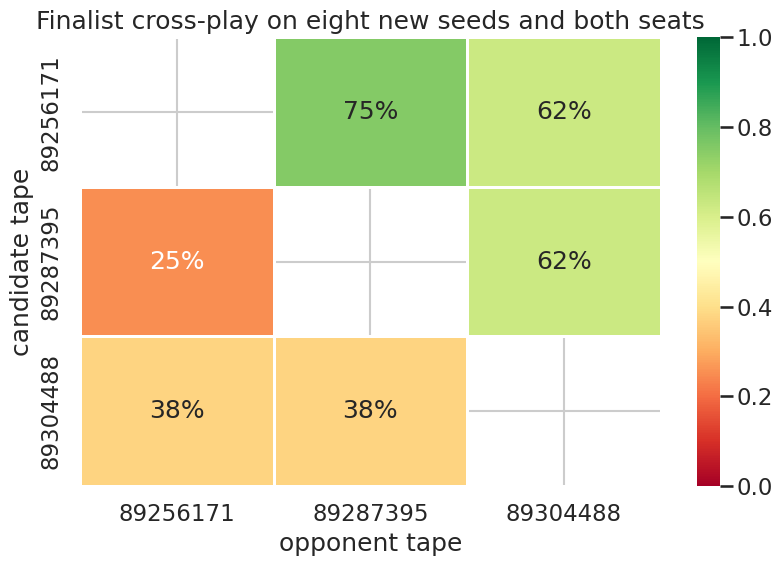

,candidate_episode,opponent_episode,games,wins,mean_margin,win_rate
0,89256171,89287395,16,12,3398.750,0.750
1,89256171,89304488,16,10,2684.125,0.625
2,89287395,89256171,16,4,-3398.750,0.250
3,89287395,89304488,16,10,2467.250,0.625
4,89304488,89256171,16,6,-2684.125,0.375
5,89304488,89287395,16,6,-2467.250,0.375


In [3]:
CROSSPLAY_ROWS = [{'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8001, 'side': 0, 'candidate_money': 113296.0, 'opponent_money': 104577.0, 'margin': 8719.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.118014832998597}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8001, 'side': 1, 'candidate_money': 104577.0, 'opponent_money': 113296.0, 'margin': -8719.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0791231250004785}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8002, 'side': 0, 'candidate_money': 126748.0, 'opponent_money': 126748.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0912547090010776}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8002, 'side': 1, 'candidate_money': 126748.0, 'opponent_money': 126748.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1503683339979034}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8003, 'side': 0, 'candidate_money': 118384.0, 'opponent_money': 118384.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1418271670008835}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8003, 'side': 1, 'candidate_money': 118384.0, 'opponent_money': 118384.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1891159170008905}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8004, 'side': 0, 'candidate_money': 139367.0, 'opponent_money': 151677.0, 'margin': -12310.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.196176208999532}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8004, 'side': 1, 'candidate_money': 151677.0, 'opponent_money': 139367.0, 'margin': 12310.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2122464159983792}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8005, 'side': 0, 'candidate_money': 128002.0, 'opponent_money': 125394.0, 'margin': 2608.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.6187147500022547}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8005, 'side': 1, 'candidate_money': 125394.0, 'opponent_money': 128002.0, 'margin': -2608.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.499785999996675}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8006, 'side': 0, 'candidate_money': 121478.0, 'opponent_money': 124280.0, 'margin': -2802.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.4606950409979618}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8006, 'side': 1, 'candidate_money': 124280.0, 'opponent_money': 121478.0, 'margin': 2802.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.5887934589991346}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8007, 'side': 0, 'candidate_money': 86909.0, 'opponent_money': 88143.0, 'margin': -1234.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.59906270799911}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8007, 'side': 1, 'candidate_money': 88143.0, 'opponent_money': 86909.0, 'margin': 1234.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.556064583000989}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8008, 'side': 0, 'candidate_money': 120757.0, 'opponent_money': 120757.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.4307609999996203}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89256171', 'seed': 8008, 'side': 1, 'candidate_money': 120757.0, 'opponent_money': 120757.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.49342420800167}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8001, 'side': 0, 'candidate_money': 96156.0, 'opponent_money': 81785.0, 'margin': 14371.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0338973340003577}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8001, 'side': 1, 'candidate_money': 84688.0, 'opponent_money': 86214.0, 'margin': -1526.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.098763166999561}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8002, 'side': 0, 'candidate_money': 106848.0, 'opponent_money': 101262.0, 'margin': 5586.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.083841374998883}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8002, 'side': 1, 'candidate_money': 106848.0, 'opponent_money': 101262.0, 'margin': 5586.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.074895084002492}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8003, 'side': 0, 'candidate_money': 132837.0, 'opponent_money': 132413.0, 'margin': 424.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1207354580001265}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8003, 'side': 1, 'candidate_money': 132837.0, 'opponent_money': 132413.0, 'margin': 424.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.130210667000938}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8004, 'side': 0, 'candidate_money': 135085.0, 'opponent_money': 144386.0, 'margin': -9301.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.137372208002489}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8004, 'side': 1, 'candidate_money': 145993.0, 'opponent_money': 135358.0, 'margin': 10635.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1256234159991436}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8005, 'side': 0, 'candidate_money': 111288.0, 'opponent_money': 112341.0, 'margin': -1053.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.264531790999172}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8005, 'side': 1, 'candidate_money': 109357.0, 'opponent_money': 115075.0, 'margin': -5718.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1453336250015127}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8006, 'side': 0, 'candidate_money': 115756.0, 'opponent_money': 112703.0, 'margin': 3053.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.137692000000243}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8006, 'side': 1, 'candidate_money': 125817.0, 'opponent_money': 120938.0, 'margin': 4879.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.276918792002107}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8007, 'side': 0, 'candidate_money': 114282.0, 'opponent_money': 106700.0, 'margin': 7582.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1651603749996866}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8007, 'side': 1, 'candidate_money': 116740.0, 'opponent_money': 104972.0, 'margin': 11768.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1526822919986444}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8008, 'side': 0, 'candidate_money': 134738.0, 'opponent_money': 130903.0, 'margin': 3835.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3309347920003347}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89287395', 'seed': 8008, 'side': 1, 'candidate_money': 134738.0, 'opponent_money': 130903.0, 'margin': 3835.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2877761669988104}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8001, 'side': 0, 'candidate_money': 96983.0, 'opponent_money': 86423.0, 'margin': 10560.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1730996249971213}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8001, 'side': 1, 'candidate_money': 93750.0, 'opponent_money': 88624.0, 'margin': 5126.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.120064541002648}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8002, 'side': 0, 'candidate_money': 101583.0, 'opponent_money': 104476.0, 'margin': -2893.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1490291669979342}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8002, 'side': 1, 'candidate_money': 101583.0, 'opponent_money': 104476.0, 'margin': -2893.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1432000000022526}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8003, 'side': 0, 'candidate_money': 122940.0, 'opponent_money': 125371.0, 'margin': -2431.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.116853874998924}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8003, 'side': 1, 'candidate_money': 122940.0, 'opponent_money': 125371.0, 'margin': -2431.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1823839579992637}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8004, 'side': 0, 'candidate_money': 129591.0, 'opponent_money': 143637.0, 'margin': -14046.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1171187499967346}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8004, 'side': 1, 'candidate_money': 137890.0, 'opponent_money': 118331.0, 'margin': 19559.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.167882334000751}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8005, 'side': 0, 'candidate_money': 113193.0, 'opponent_money': 107975.0, 'margin': 5218.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.043130458001542}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8005, 'side': 1, 'candidate_money': 111625.0, 'opponent_money': 111081.0, 'margin': 544.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.092344458000298}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8006, 'side': 0, 'candidate_money': 109094.0, 'opponent_money': 111677.0, 'margin': -2583.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0832106660018326}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8006, 'side': 1, 'candidate_money': 111007.0, 'opponent_money': 109715.0, 'margin': 1292.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.090645709002274}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8007, 'side': 0, 'candidate_money': 126568.0, 'opponent_money': 119308.0, 'margin': 7260.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0947836250015825}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8007, 'side': 1, 'candidate_money': 128584.0, 'opponent_money': 117206.0, 'margin': 11378.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.099038249998557}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8008, 'side': 0, 'candidate_money': 119359.0, 'opponent_money': 114716.0, 'margin': 4643.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1557371670023713}, {'challenger': 'radianttrace:89256171', 'opponent': 'radianttrace:89304488', 'seed': 8008, 'side': 1, 'candidate_money': 119359.0, 'opponent_money': 114716.0, 'margin': 4643.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1678802909991646}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8001, 'side': 0, 'candidate_money': 86214.0, 'opponent_money': 84688.0, 'margin': 1526.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.888049291999778}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8001, 'side': 1, 'candidate_money': 81785.0, 'opponent_money': 96156.0, 'margin': -14371.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.973460083001555}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8002, 'side': 0, 'candidate_money': 101262.0, 'opponent_money': 106848.0, 'margin': -5586.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9113492500000575}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8002, 'side': 1, 'candidate_money': 101262.0, 'opponent_money': 106848.0, 'margin': -5586.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.84627087500121}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8003, 'side': 0, 'candidate_money': 132413.0, 'opponent_money': 132837.0, 'margin': -424.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.960255166002753}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8003, 'side': 1, 'candidate_money': 132413.0, 'opponent_money': 132837.0, 'margin': -424.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.8850911669978814}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8004, 'side': 0, 'candidate_money': 135358.0, 'opponent_money': 145993.0, 'margin': -10635.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9111886659993615}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8004, 'side': 1, 'candidate_money': 144386.0, 'opponent_money': 135085.0, 'margin': 9301.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0003762080013985}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8005, 'side': 0, 'candidate_money': 115075.0, 'opponent_money': 109357.0, 'margin': 5718.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.159389750002447}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8005, 'side': 1, 'candidate_money': 112341.0, 'opponent_money': 111288.0, 'margin': 1053.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.075480041999981}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8006, 'side': 0, 'candidate_money': 120938.0, 'opponent_money': 125817.0, 'margin': -4879.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.138044458002696}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8006, 'side': 1, 'candidate_money': 112703.0, 'opponent_money': 115756.0, 'margin': -3053.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1229808749994845}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8007, 'side': 0, 'candidate_money': 104972.0, 'opponent_money': 116740.0, 'margin': -11768.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0169219999988854}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8007, 'side': 1, 'candidate_money': 106700.0, 'opponent_money': 114282.0, 'margin': -7582.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0817936660023406}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8008, 'side': 0, 'candidate_money': 130903.0, 'opponent_money': 134738.0, 'margin': -3835.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.365113042000303}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89256171', 'seed': 8008, 'side': 1, 'candidate_money': 130903.0, 'opponent_money': 134738.0, 'margin': -3835.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3376986249968468}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8001, 'side': 0, 'candidate_money': 100771.0, 'opponent_money': 88018.0, 'margin': 12753.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.8330082499996934}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8001, 'side': 1, 'candidate_money': 88018.0, 'opponent_money': 100771.0, 'margin': -12753.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9290763749995676}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8002, 'side': 0, 'candidate_money': 127038.0, 'opponent_money': 127038.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9740202499997395}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8002, 'side': 1, 'candidate_money': 127038.0, 'opponent_money': 127038.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.030712040999788}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8003, 'side': 0, 'candidate_money': 83706.0, 'opponent_money': 83706.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9618630000004487}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8003, 'side': 1, 'candidate_money': 83706.0, 'opponent_money': 83706.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.8771618749997288}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8004, 'side': 0, 'candidate_money': 143749.0, 'opponent_money': 152799.0, 'margin': -9050.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9256475410002167}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8004, 'side': 1, 'candidate_money': 152799.0, 'opponent_money': 143749.0, 'margin': 9050.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.007849500001612}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8005, 'side': 0, 'candidate_money': 127454.0, 'opponent_money': 125609.0, 'margin': 1845.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.956288000001223}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8005, 'side': 1, 'candidate_money': 125609.0, 'opponent_money': 127454.0, 'margin': -1845.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9489313749982102}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8006, 'side': 0, 'candidate_money': 115795.0, 'opponent_money': 117981.0, 'margin': -2186.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9192226250015665}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8006, 'side': 1, 'candidate_money': 117981.0, 'opponent_money': 115795.0, 'margin': 2186.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.8405519999978424}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8007, 'side': 0, 'candidate_money': 85784.0, 'opponent_money': 87604.0, 'margin': -1820.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.8137783340025635}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8007, 'side': 1, 'candidate_money': 87604.0, 'opponent_money': 85784.0, 'margin': 1820.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.927944833998481}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8008, 'side': 0, 'candidate_money': 132785.0, 'opponent_money': 132785.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.875477375000628}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89287395', 'seed': 8008, 'side': 1, 'candidate_money': 132785.0, 'opponent_money': 132785.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.876030041999911}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8001, 'side': 0, 'candidate_money': 120866.0, 'opponent_money': 114474.0, 'margin': 6392.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2511558330006665}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8001, 'side': 1, 'candidate_money': 85600.0, 'opponent_money': 95437.0, 'margin': -9837.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.219916750000266}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8002, 'side': 0, 'candidate_money': 119329.0, 'opponent_money': 115417.0, 'margin': 3912.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1378721250002855}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8002, 'side': 1, 'candidate_money': 119329.0, 'opponent_money': 115417.0, 'margin': 3912.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.150362625001435}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8003, 'side': 0, 'candidate_money': 120933.0, 'opponent_money': 122528.0, 'margin': -1595.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2044045419970644}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8003, 'side': 1, 'candidate_money': 120933.0, 'opponent_money': 122528.0, 'margin': -1595.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2456331249995856}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8004, 'side': 0, 'candidate_money': 126864.0, 'opponent_money': 137396.0, 'margin': -10532.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2045726659998763}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8004, 'side': 1, 'candidate_money': 128506.0, 'opponent_money': 112769.0, 'margin': 15737.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1803122499986785}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8005, 'side': 0, 'candidate_money': 117689.0, 'opponent_money': 117210.0, 'margin': 479.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.030533416000253}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8005, 'side': 1, 'candidate_money': 116324.0, 'opponent_money': 119219.0, 'margin': -2895.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.997471875001793}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8006, 'side': 0, 'candidate_money': 117020.0, 'opponent_money': 110448.0, 'margin': 6572.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0299924169994483}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8006, 'side': 1, 'candidate_money': 118536.0, 'opponent_money': 107918.0, 'margin': 10618.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.003416042000026}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8007, 'side': 0, 'candidate_money': 94376.0, 'opponent_money': 96979.0, 'margin': -2603.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0318372500005353}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8007, 'side': 1, 'candidate_money': 97459.0, 'opponent_money': 94669.0, 'margin': 2790.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.957931875000213}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8008, 'side': 0, 'candidate_money': 134172.0, 'opponent_money': 124517.0, 'margin': 9655.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.080157041000348}, {'challenger': 'radianttrace:89287395', 'opponent': 'radianttrace:89304488', 'seed': 8008, 'side': 1, 'candidate_money': 133721.0, 'opponent_money': 125255.0, 'margin': 8466.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0408780409998144}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8001, 'side': 0, 'candidate_money': 88624.0, 'opponent_money': 93750.0, 'margin': -5126.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.149563250000938}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8001, 'side': 1, 'candidate_money': 86423.0, 'opponent_money': 96983.0, 'margin': -10560.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.148762959001033}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8002, 'side': 0, 'candidate_money': 104476.0, 'opponent_money': 101583.0, 'margin': 2893.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.135319917000743}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8002, 'side': 1, 'candidate_money': 104476.0, 'opponent_money': 101583.0, 'margin': 2893.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2152306249990943}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8003, 'side': 0, 'candidate_money': 125371.0, 'opponent_money': 122940.0, 'margin': 2431.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.186578584001836}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8003, 'side': 1, 'candidate_money': 125371.0, 'opponent_money': 122940.0, 'margin': 2431.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1765557500002615}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8004, 'side': 0, 'candidate_money': 118331.0, 'opponent_money': 137890.0, 'margin': -19559.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.140324125000916}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8004, 'side': 1, 'candidate_money': 143637.0, 'opponent_money': 129591.0, 'margin': 14046.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.13807208399885}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8005, 'side': 0, 'candidate_money': 111081.0, 'opponent_money': 111625.0, 'margin': -544.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0887110420007957}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8005, 'side': 1, 'candidate_money': 107975.0, 'opponent_money': 113193.0, 'margin': -5218.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0610029579984257}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8006, 'side': 0, 'candidate_money': 109715.0, 'opponent_money': 111007.0, 'margin': -1292.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1646698330005165}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8006, 'side': 1, 'candidate_money': 111677.0, 'opponent_money': 109094.0, 'margin': 2583.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0948489170004905}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8007, 'side': 0, 'candidate_money': 117206.0, 'opponent_money': 128584.0, 'margin': -11378.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1225000000013097}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8007, 'side': 1, 'candidate_money': 119308.0, 'opponent_money': 126568.0, 'margin': -7260.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1917235420005454}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8008, 'side': 0, 'candidate_money': 114716.0, 'opponent_money': 119359.0, 'margin': -4643.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1575017499999376}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89256171', 'seed': 8008, 'side': 1, 'candidate_money': 114716.0, 'opponent_money': 119359.0, 'margin': -4643.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2315060420005466}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8001, 'side': 0, 'candidate_money': 95437.0, 'opponent_money': 85600.0, 'margin': 9837.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1333495830003812}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8001, 'side': 1, 'candidate_money': 114474.0, 'opponent_money': 120866.0, 'margin': -6392.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0708743750001304}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8002, 'side': 0, 'candidate_money': 115417.0, 'opponent_money': 119329.0, 'margin': -3912.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0648808749974705}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8002, 'side': 1, 'candidate_money': 115417.0, 'opponent_money': 119329.0, 'margin': -3912.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.053142167002079}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8003, 'side': 0, 'candidate_money': 122528.0, 'opponent_money': 120933.0, 'margin': 1595.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.127908375001425}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8003, 'side': 1, 'candidate_money': 122528.0, 'opponent_money': 120933.0, 'margin': 1595.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1738265000021784}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8004, 'side': 0, 'candidate_money': 112769.0, 'opponent_money': 128506.0, 'margin': -15737.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1136832909978693}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8004, 'side': 1, 'candidate_money': 137396.0, 'opponent_money': 126864.0, 'margin': 10532.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0662302919990907}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8005, 'side': 0, 'candidate_money': 119219.0, 'opponent_money': 116324.0, 'margin': 2895.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.014344250001159}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8005, 'side': 1, 'candidate_money': 117210.0, 'opponent_money': 117689.0, 'margin': -479.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0204030829991098}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8006, 'side': 0, 'candidate_money': 107918.0, 'opponent_money': 118536.0, 'margin': -10618.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1256753750021744}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8006, 'side': 1, 'candidate_money': 110448.0, 'opponent_money': 117020.0, 'margin': -6572.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.061822415998904}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8007, 'side': 0, 'candidate_money': 94669.0, 'opponent_money': 97459.0, 'margin': -2790.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0055207910008903}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8007, 'side': 1, 'candidate_money': 96979.0, 'opponent_money': 94376.0, 'margin': 2603.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.013205082999775}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8008, 'side': 0, 'candidate_money': 125255.0, 'opponent_money': 133721.0, 'margin': -8466.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0843170840016683}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89287395', 'seed': 8008, 'side': 1, 'candidate_money': 124517.0, 'opponent_money': 134172.0, 'margin': -9655.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1918844579995493}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8001, 'side': 0, 'candidate_money': 109479.0, 'opponent_money': 107196.0, 'margin': 2283.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.134264207998058}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8001, 'side': 1, 'candidate_money': 107196.0, 'opponent_money': 109479.0, 'margin': -2283.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.065365499998734}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8002, 'side': 0, 'candidate_money': 118024.0, 'opponent_money': 118024.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.132481791999453}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8002, 'side': 1, 'candidate_money': 118024.0, 'opponent_money': 118024.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1636582920000365}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8003, 'side': 0, 'candidate_money': 110482.0, 'opponent_money': 110482.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1762461250000342}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8003, 'side': 1, 'candidate_money': 110482.0, 'opponent_money': 110482.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1519655830015836}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8004, 'side': 0, 'candidate_money': 117831.0, 'opponent_money': 140799.0, 'margin': -22968.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1809878749991185}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8004, 'side': 1, 'candidate_money': 140799.0, 'opponent_money': 117831.0, 'margin': 22968.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.127323875000002}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8005, 'side': 0, 'candidate_money': 129414.0, 'opponent_money': 128144.0, 'margin': 1270.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1508869169992977}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8005, 'side': 1, 'candidate_money': 128144.0, 'opponent_money': 129414.0, 'margin': -1270.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.148768833001668}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8006, 'side': 0, 'candidate_money': 119314.0, 'opponent_money': 120678.0, 'margin': -1364.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2422308340028394}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8006, 'side': 1, 'candidate_money': 120678.0, 'opponent_money': 119314.0, 'margin': 1364.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1682554169965442}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8007, 'side': 0, 'candidate_money': 97812.0, 'opponent_money': 99037.0, 'margin': -1225.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1944044589981786}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8007, 'side': 1, 'candidate_money': 99037.0, 'opponent_money': 97812.0, 'margin': 1225.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.198750250001467}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8008, 'side': 0, 'candidate_money': 140456.0, 'opponent_money': 140194.0, 'margin': 262.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2065949169991654}, {'challenger': 'radianttrace:89304488', 'opponent': 'radianttrace:89304488', 'seed': 8008, 'side': 1, 'candidate_money': 140194.0, 'opponent_money': 140456.0, 'margin': -262.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1727371659981145}]
crossplay = pd.DataFrame(CROSSPLAY_ROWS)
crossplay["candidate_episode"] = crossplay.challenger.str.split(":").str[-1]
crossplay["opponent_episode"] = crossplay.opponent.str.split(":").str[-1]
duel = crossplay[crossplay.candidate_episode != crossplay.opponent_episode]
duel_view = duel.groupby(["candidate_episode", "opponent_episode"], as_index=False).agg(
    games=("win", "size"), wins=("win", "sum"), mean_margin=("margin", "mean")
)
duel_view["win_rate"] = duel_view.wins / duel_view.games
matrix = duel_view.pivot(index="candidate_episode", columns="opponent_episode", values="win_rate")
fig, ax = plt.subplots(figsize=(8.5, 6))
sns.heatmap(matrix, annot=True, fmt=".0%", vmin=0, vmax=1, center=.5, cmap="RdYlGn", linewidths=.8, ax=ax)
ax.set(title="Finalist cross-play on eight new seeds and both seats", xlabel="opponent tape", ylabel="candidate tape")
plt.tight_layout(); plt.show()
display(duel_view.sort_values(["candidate_episode", "opponent_episode"]).round(3))


## 2. Mathematical control: all melons is an opening, not a strategy

A watered melon tile can produce six premium units, but the sale curve is quadratic in glut. Dumping a whole monoculture into the same market makes each later tile sharply less valuable. The replay uses a small early melon tranche for explosive capital, then rotates into strawberries while livestock adds diversified milk, wool, and fertilizer value.


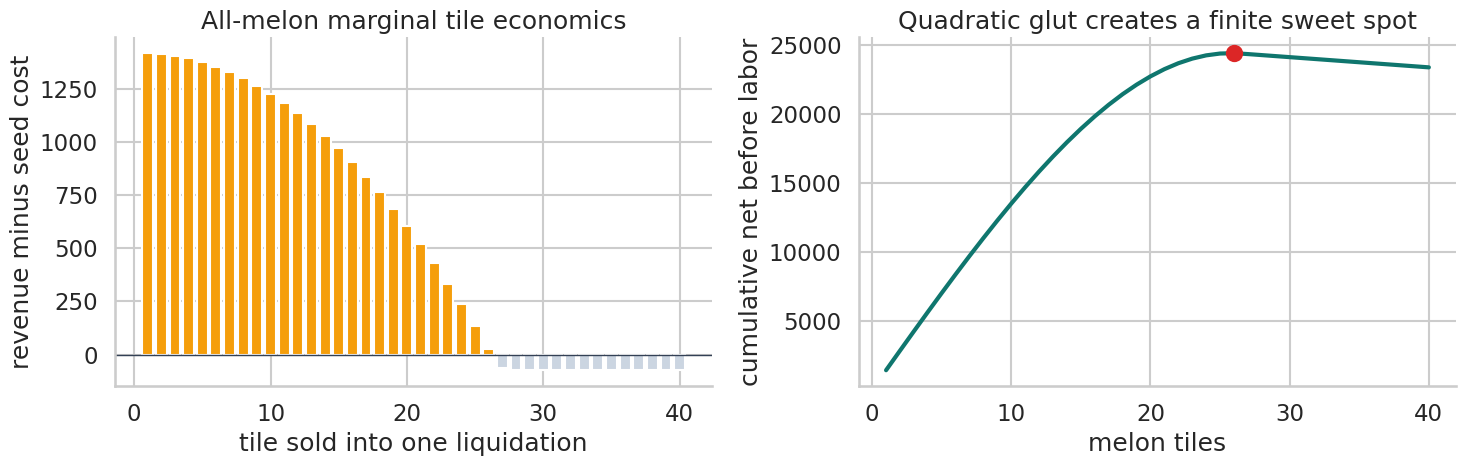

{'best_static_tile_count': 26, 'first_tile_net': 1420.0, 'fortieth_tile_net': -74.0}


In [4]:
def melon_price(glut):
    glut = np.maximum(0, np.asarray(glut))
    return np.maximum(1, np.rint(250 - (3.6 * 250 / 300**2) * glut**2))

tiles = np.arange(1, 41)
tile_net = np.array([melon_price(np.arange((i-1)*6, i*6)).sum() - 80 for i in tiles])
cumulative_net = np.cumsum(tile_net)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(tiles, tile_net, color=[COLORS[1] if x > 0 else "#cbd5e1" for x in tile_net])
axes[0].axhline(0, color="#334155", lw=1)
axes[0].set(title="All-melon marginal tile economics", xlabel="tile sold into one liquidation", ylabel="revenue minus seed cost")
axes[1].plot(tiles, cumulative_net, lw=3, color=COLORS[0])
axes[1].scatter([tiles[np.argmax(cumulative_net)]], [cumulative_net.max()], s=120, color=COLORS[4], zorder=3)
axes[1].set(title="Quadratic glut creates a finite sweet spot", xlabel="melon tiles", ylabel="cumulative net before labor")
sns.despine(); plt.tight_layout(); plt.show()
print({"best_static_tile_count": int(tiles[np.argmax(cumulative_net)]), "first_tile_net": float(tile_net[0]), "fortieth_tile_net": float(tile_net[-1])})


## 3. Teardown of public episode 89256171

These plots are descriptive measurements of the public replay—not evidence about hidden implementation. The farm front-loads four animals and six melon seeds in the first market turn, uses 4 hands on day 0, expands to a 16-animal mixed herd, then sustains roughly a dozen hands while the crop book rotates toward strawberries.


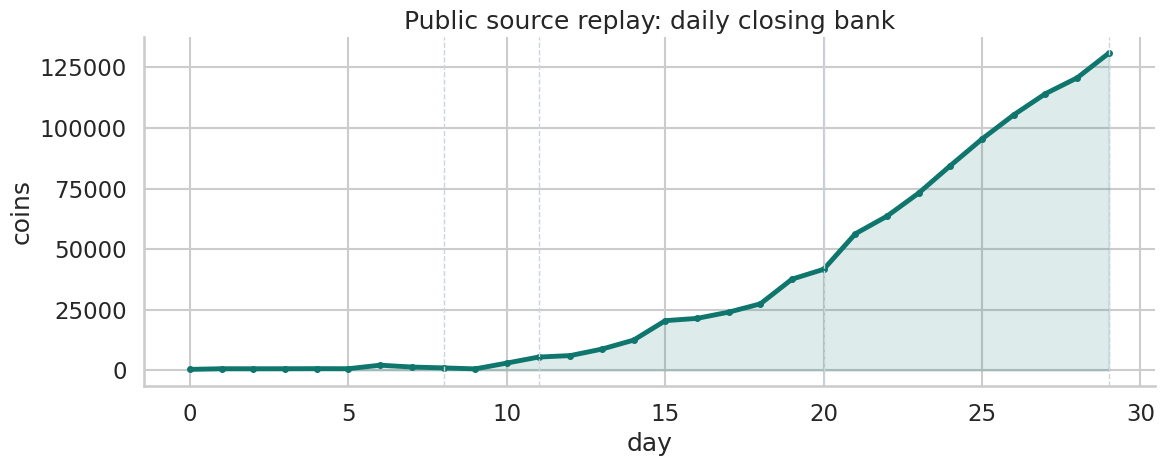

{'episode': 89256171, 'public_reward': 130895.0, 'public_opponent_reward': 117910.0}


In [5]:
DAILY_ROWS = [{'day': 0, 'money': 352.0, 'hands': 4, 'unlocked_quadrants': 1, 'crop_melon': 6, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 1, 'money': 628.0, 'hands': 5, 'unlocked_quadrants': 1, 'crop_melon': 7, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 2, 'money': 610.0, 'hands': 5, 'unlocked_quadrants': 1, 'crop_melon': 8, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 3, 'money': 627.0, 'hands': 5, 'unlocked_quadrants': 1, 'crop_melon': 10, 'crop_strawberry': 1, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 4, 'money': 659.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 10, 'crop_strawberry': 3, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 5, 'money': 631.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 10, 'crop_strawberry': 7, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 6, 'money': 2083.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 10, 'crop_strawberry': 9, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 7, 'money': 1322.0, 'hands': 7, 'unlocked_quadrants': 1, 'crop_melon': 10, 'crop_strawberry': 9, 'animal_sheep': 1, 'animal_buildings': 6, 'animal_cow': 5}, {'day': 8, 'money': 967.0, 'hands': 7, 'unlocked_quadrants': 2, 'crop_melon': 10, 'crop_strawberry': 10, 'animal_sheep': 2, 'animal_buildings': 9, 'animal_cow': 5}, {'day': 9, 'money': 559.0, 'hands': 9, 'unlocked_quadrants': 2, 'crop_melon': 10, 'crop_strawberry': 13, 'animal_sheep': 4, 'animal_buildings': 9, 'animal_cow': 5}, {'day': 10, 'money': 2962.0, 'hands': 10, 'unlocked_quadrants': 2, 'crop_melon': 9, 'crop_strawberry': 16, 'animal_sheep': 4, 'animal_buildings': 10, 'animal_cow': 5}, {'day': 11, 'money': 5438.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 11, 'crop_strawberry': 26, 'animal_sheep': 4, 'animal_buildings': 12, 'animal_cow': 8}, {'day': 12, 'money': 6046.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 10, 'crop_strawberry': 35, 'animal_sheep': 4, 'animal_buildings': 12, 'animal_cow': 8}, {'day': 13, 'money': 8723.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 8, 'crop_strawberry': 43, 'animal_sheep': 4, 'animal_buildings': 12, 'animal_cow': 8}, {'day': 14, 'money': 12435.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 9, 'crop_strawberry': 45, 'animal_sheep': 4, 'animal_buildings': 12, 'animal_cow': 8}, {'day': 15, 'money': 20466.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 9, 'crop_strawberry': 47, 'animal_sheep': 4, 'animal_buildings': 12, 'animal_cow': 8}, {'day': 16, 'money': 21407.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 9, 'crop_strawberry': 47, 'animal_sheep': 6, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 17, 'money': 23976.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 9, 'crop_strawberry': 47, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 18, 'money': 27402.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 9, 'crop_strawberry': 47, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 19, 'money': 37608.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 9, 'crop_strawberry': 47, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 20, 'money': 41682.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 5, 'crop_strawberry': 47, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 21, 'money': 56338.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_melon': 4, 'crop_strawberry': 45, 'weed': 2, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 22, 'money': 63619.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_strawberry': 41, 'weed': 4, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7, 'crop_melon': 2}, {'day': 23, 'money': 73153.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_strawberry': 39, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7, 'weed': 1, 'crop_melon': 1}, {'day': 24, 'money': 84477.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_strawberry': 39, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 25, 'money': 95486.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_strawberry': 38, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 26, 'money': 105432.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_strawberry': 35, 'weed': 1, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 27, 'money': 114177.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_strawberry': 32, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 28, 'money': 120709.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_strawberry': 22, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}, {'day': 29, 'money': 130895.0, 'hands': 10, 'unlocked_quadrants': 3, 'crop_strawberry': 13, 'weed': 9, 'animal_sheep': 7, 'animal_buildings': 14, 'animal_cow': 7}]
daily = pd.DataFrame(DAILY_ROWS).fillna(0)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily.day, daily.money, lw=3.5, color=COLORS[0], marker="o", ms=4)
ax.fill_between(daily.day, daily.money, alpha=.14, color=COLORS[0])
for day in (8, 11, 20, 29): ax.axvline(day, color="#cbd5e1", ls="--", lw=1)
ax.set(title="Public source replay: daily closing bank", xlabel="day", ylabel="coins")
sns.despine(); plt.tight_layout(); plt.show()
print({"episode": 89256171, "public_reward": 130895.0, "public_opponent_reward": 117910.0})


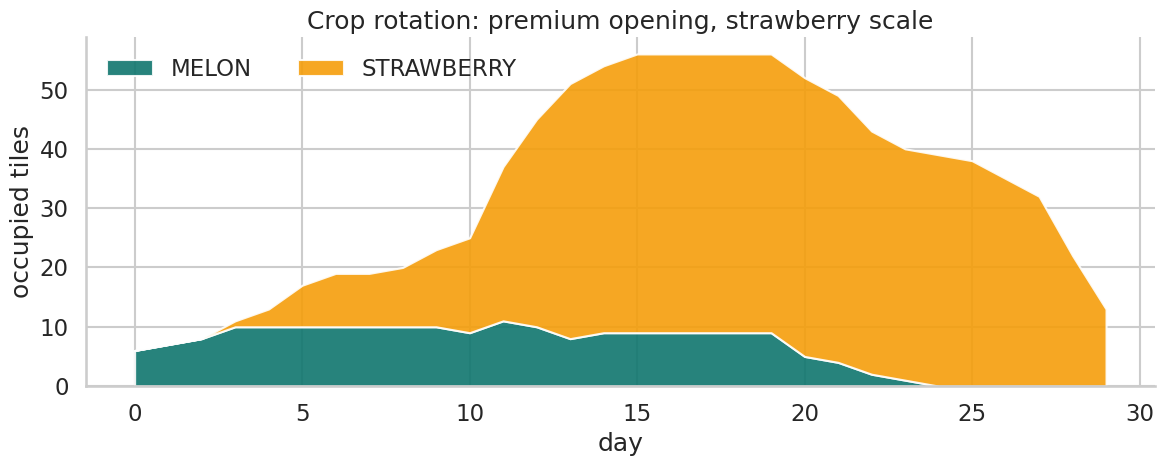

In [6]:
crop_cols = [c for c in daily if c.startswith("crop_")]
crop_labels = [c.replace("crop_", "").upper() for c in crop_cols]
fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(daily.day, *[daily[c] for c in crop_cols], labels=crop_labels,
             colors=COLORS[:len(crop_cols)], alpha=.9)
ax.set(title="Crop rotation: premium opening, strawberry scale", xlabel="day", ylabel="occupied tiles")
ax.legend(frameon=False, ncol=4, loc="upper left")
sns.despine(); plt.tight_layout(); plt.show()


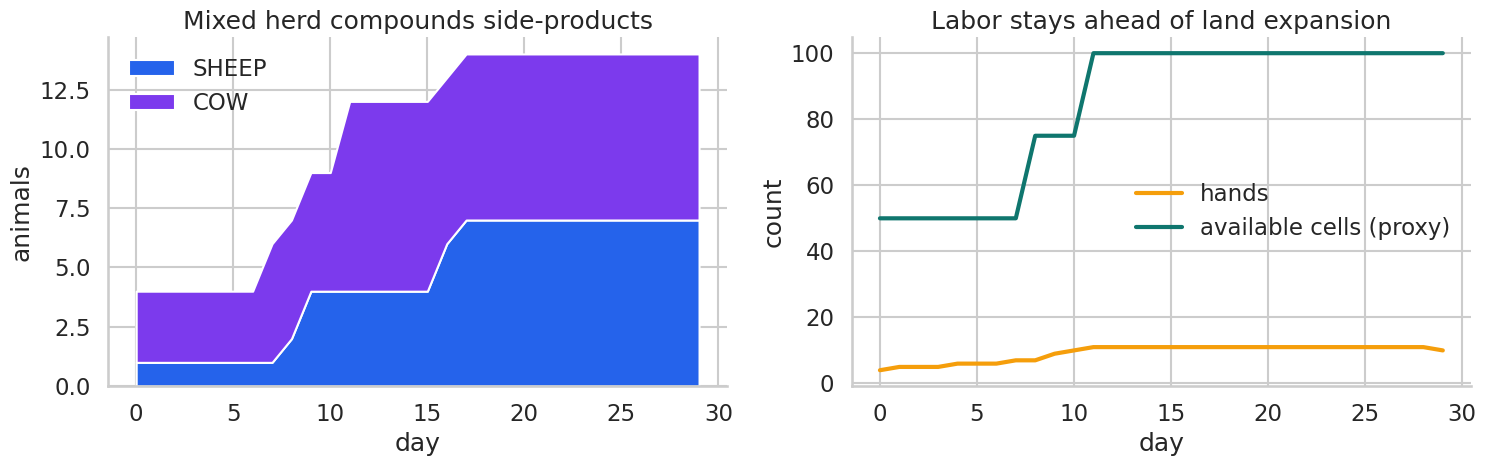

In [7]:
animal_cols = [c for c in daily if c.startswith("animal_") and c != "animal_buildings"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].stackplot(daily.day, *[daily[c] for c in animal_cols],
                  labels=[c.replace("animal_", "").upper() for c in animal_cols], colors=COLORS[2:2+len(animal_cols)])
axes[0].set(title="Mixed herd compounds side-products", xlabel="day", ylabel="animals")
axes[0].legend(frameon=False)
axes[1].plot(daily.day, daily.hands, lw=3, color=COLORS[1], label="hands")
axes[1].plot(daily.day, 25 * (1 + daily.unlocked_quadrants), lw=3, color=COLORS[0], label="available cells (proxy)")
axes[1].set(title="Labor stays ahead of land expansion", xlabel="day", ylabel="count")
axes[1].legend(frameon=False)
sns.despine(); plt.tight_layout(); plt.show()


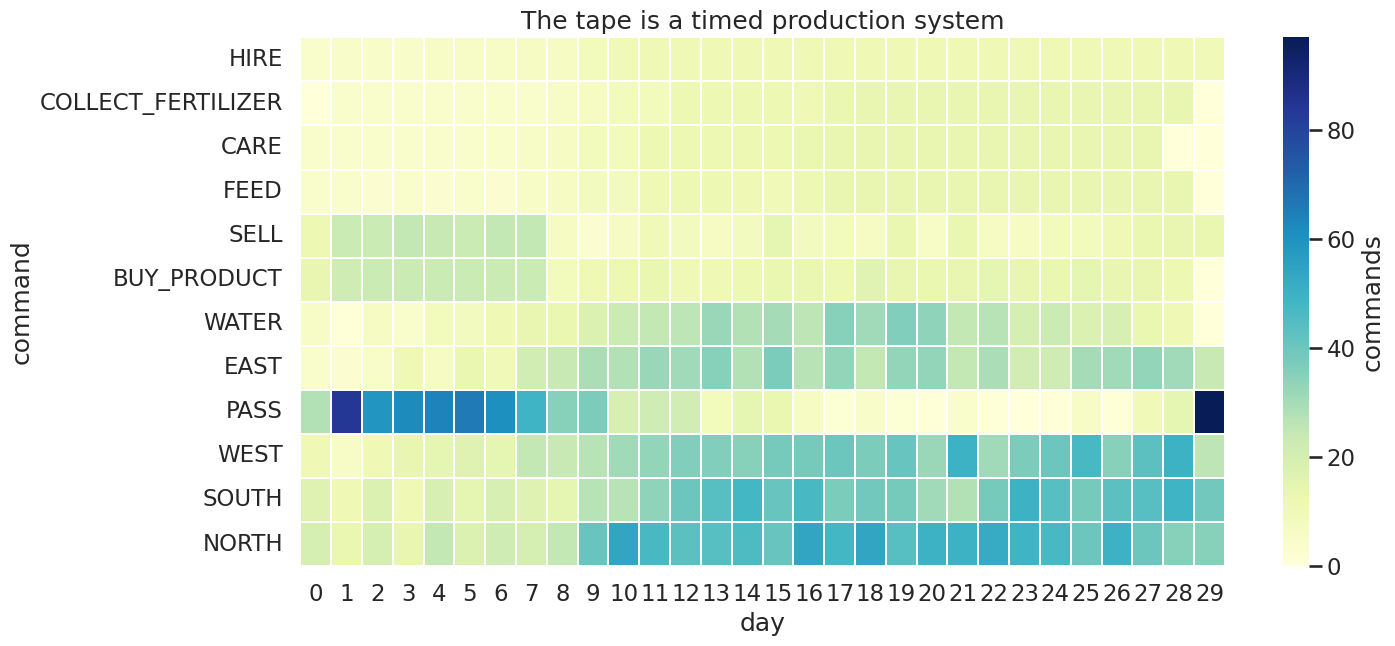

In [8]:
ACTION_ROWS = [{'day': 0, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'HIRE'}, {'day': 0, 'actor': 'market', 'verb': 'HIRE'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_ANIMAL'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 0, 'actor': 'farmer', 'verb': 'BUILD_PASTURE'}, {'day': 0, 'actor': 'hands', 'verb': 'WEST'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'market', 'verb': 'HIRE'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_ANIMAL'}, {'day': 0, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 0, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'WEST'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'market', 'verb': 'HIRE'}, {'day': 0, 'actor': 'farmer', 'verb': 'PLACE'}, {'day': 0, 'actor': 'hands', 'verb': 'WEST'}, {'day': 0, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'WEST'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 0, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 0, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 0, 'actor': 'hands', 'verb': 'CARE'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'EAST'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 0, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 0, 'actor': 'hands', 'verb': 'CARE'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 0, 'actor': 'hands', 'verb': 'CARE'}, {'day': 0, 'actor': 'hands', 'verb': 'WATER'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'WEST'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'WEST'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'WATER'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'CARE'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 0, 'actor': 'hands', 'verb': 'WEST'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'EAST'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 0, 'actor': 'hands', 'verb': 'WATER'}, {'day': 0, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'WATER'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'WEST'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'WEST'}, {'day': 0, 'actor': 'hands', 'verb': 'WATER'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'WEST'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'WATER'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 0, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 0, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'EAST'}, {'day': 0, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'hands', 'verb': 'PASS'}, {'day': 0, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'market', 'verb': 'HIRE'}, {'day': 1, 'actor': 'market', 'verb': 'HIRE'}, {'day': 1, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 1, 'actor': 'hands', 'verb': 'WEST'}, {'day': 1, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 1, 'actor': 'market', 'verb': 'HIRE'}, {'day': 1, 'actor': 'market', 'verb': 'HIRE'}, {'day': 1, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 1, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 1, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'WEST'}, {'day': 1, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'market', 'verb': 'HIRE'}, {'day': 1, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'WEST'}, {'day': 1, 'actor': 'hands', 'verb': 'CARE'}, {'day': 1, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'WEST'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 1, 'actor': 'hands', 'verb': 'CARE'}, {'day': 1, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 1, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'WEST'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 1, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'CARE'}, {'day': 1, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 1, 'actor': 'hands', 'verb': 'EAST'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 1, 'actor': 'hands', 'verb': 'EAST'}, {'day': 1, 'actor': 'hands', 'verb': 'DROP'}, {'day': 1, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'DROP'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'DROP'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 1, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 1, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'PLANT'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 1, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'hands', 'verb': 'PASS'}, {'day': 1, 'actor': 'market', 'verb': 'SELL'}, {'day': 1, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'market', 'verb': 'HIRE'}, {'day': 2, 'actor': 'market', 'verb': 'HIRE'}, {'day': 2, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 2, 'actor': 'hands', 'verb': 'WEST'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'market', 'verb': 'HIRE'}, {'day': 2, 'actor': 'market', 'verb': 'HIRE'}, {'day': 2, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 2, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'WEST'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'market', 'verb': 'HIRE'}, {'day': 2, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'CARE'}, {'day': 2, 'actor': 'hands', 'verb': 'WEST'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'WEST'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 2, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'CARE'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'WEST'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'CARE'}, {'day': 2, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 2, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 2, 'actor': 'hands', 'verb': 'EAST'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'EAST'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'WATER'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'DROP'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'DROP'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 2, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 2, 'actor': 'hands', 'verb': 'WEST'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 2, 'actor': 'hands', 'verb': 'WEST'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'WATER'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 2, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 2, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 2, 'actor': 'hands', 'verb': 'EAST'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'hands', 'verb': 'PASS'}, {'day': 2, 'actor': 'market', 'verb': 'SELL'}, {'day': 2, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'market', 'verb': 'HIRE'}, {'day': 3, 'actor': 'market', 'verb': 'HIRE'}, {'day': 3, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'market', 'verb': 'HIRE'}, {'day': 3, 'actor': 'market', 'verb': 'HIRE'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 3, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 3, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'market', 'verb': 'HIRE'}, {'day': 3, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'CARE'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 3, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'CARE'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'CARE'}, {'day': 3, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 3, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'EAST'}, {'day': 3, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'DROP'}, {'day': 3, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'hands', 'verb': 'EAST'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'hands', 'verb': 'WATER'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'DROP'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 3, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'WATER'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'WEST'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 3, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'WATER'}, {'day': 3, 'actor': 'hands', 'verb': 'WATER'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'EAST'}, {'day': 3, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'EAST'}, {'day': 3, 'actor': 'hands', 'verb': 'EAST'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'EAST'}, {'day': 3, 'actor': 'hands', 'verb': 'EAST'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'EAST'}, {'day': 3, 'actor': 'hands', 'verb': 'EAST'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'DROP'}, {'day': 3, 'actor': 'hands', 'verb': 'EAST'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 3, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'hands', 'verb': 'PASS'}, {'day': 3, 'actor': 'market', 'verb': 'SELL'}, {'day': 3, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'market', 'verb': 'HIRE'}, {'day': 4, 'actor': 'market', 'verb': 'HIRE'}, {'day': 4, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'market', 'verb': 'HIRE'}, {'day': 4, 'actor': 'market', 'verb': 'HIRE'}, {'day': 4, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 4, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'market', 'verb': 'HIRE'}, {'day': 4, 'actor': 'market', 'verb': 'HIRE'}, {'day': 4, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'CARE'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 4, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'CARE'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'CARE'}, {'day': 4, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 4, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'EAST'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'WATER'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'DROP'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'EAST'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'DROP'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'WATER'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'WATER'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'EAST'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'WATER'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'DROP'}, {'day': 4, 'actor': 'hands', 'verb': 'EAST'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'EAST'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 4, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 4, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 4, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'WEST'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'hands', 'verb': 'PASS'}, {'day': 4, 'actor': 'market', 'verb': 'SELL'}, {'day': 4, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'market', 'verb': 'HIRE'}, {'day': 5, 'actor': 'market', 'verb': 'HIRE'}, {'day': 5, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'market', 'verb': 'HIRE'}, {'day': 5, 'actor': 'market', 'verb': 'HIRE'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 5, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 5, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'market', 'verb': 'HIRE'}, {'day': 5, 'actor': 'market', 'verb': 'HIRE'}, {'day': 5, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'CARE'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 5, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'CARE'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'CARE'}, {'day': 5, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 5, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 5, 'actor': 'hands', 'verb': 'DROP'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'WATER'}, {'day': 5, 'actor': 'hands', 'verb': 'WATER'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'WATER'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'WATER'}, {'day': 5, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'WATER'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'WATER'}, {'day': 5, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'WATER'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'DROP'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'WEST'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'WATER'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 5, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'EAST'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'hands', 'verb': 'PASS'}, {'day': 5, 'actor': 'market', 'verb': 'SELL'}, {'day': 5, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'market', 'verb': 'HIRE'}, {'day': 6, 'actor': 'market', 'verb': 'HIRE'}, {'day': 6, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'market', 'verb': 'HIRE'}, {'day': 6, 'actor': 'market', 'verb': 'HIRE'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 6, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 6, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'market', 'verb': 'HIRE'}, {'day': 6, 'actor': 'market', 'verb': 'HIRE'}, {'day': 6, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'CARE'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 6, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'CARE'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 6, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 6, 'actor': 'hands', 'verb': 'CARE'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 6, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'EAST'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'WATER'}, {'day': 6, 'actor': 'hands', 'verb': 'DROP'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 6, 'actor': 'hands', 'verb': 'DROP'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'WATER'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'EAST'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 6, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'WATER'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'WATER'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'WATER'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'EAST'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'WATER'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'EAST'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'EAST'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'EAST'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'EAST'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'EAST'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'DROP'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'hands', 'verb': 'PASS'}, {'day': 6, 'actor': 'market', 'verb': 'SELL'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 6, 'actor': 'market', 'verb': 'BUY_ANIMAL'}, {'day': 7, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'market', 'verb': 'HIRE'}, {'day': 7, 'actor': 'market', 'verb': 'HIRE'}, {'day': 7, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'market', 'verb': 'HIRE'}, {'day': 7, 'actor': 'market', 'verb': 'HIRE'}, {'day': 7, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 7, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'market', 'verb': 'HIRE'}, {'day': 7, 'actor': 'market', 'verb': 'HIRE'}, {'day': 7, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'CARE'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 7, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'CARE'}, {'day': 7, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'CARE'}, {'day': 7, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'market', 'verb': 'HIRE'}, {'day': 7, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 7, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'CARE'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'WATER'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'CARE'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 7, 'actor': 'hands', 'verb': 'DROP'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'DROP'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'DROP'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'EAST'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 7, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'hands', 'verb': 'PASS'}, {'day': 7, 'actor': 'market', 'verb': 'SELL'}, {'day': 7, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 8, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 8, 'actor': 'market', 'verb': 'SELL'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 8, 'actor': 'market', 'verb': 'HIRE'}, {'day': 8, 'actor': 'market', 'verb': 'HIRE'}, {'day': 8, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 8, 'actor': 'market', 'verb': 'HIRE'}, {'day': 8, 'actor': 'market', 'verb': 'HIRE'}, {'day': 8, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 8, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 8, 'actor': 'hands', 'verb': 'CARE'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'market', 'verb': 'SELL'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 8, 'actor': 'market', 'verb': 'HIRE'}, {'day': 8, 'actor': 'market', 'verb': 'HIRE'}, {'day': 8, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 8, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 8, 'actor': 'market', 'verb': 'HIRE'}, {'day': 8, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 8, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 8, 'actor': 'hands', 'verb': 'CARE'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 8, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'CARE'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'CARE'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'CARE'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'CARE'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 8, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 8, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 8, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'DROP'}, {'day': 8, 'actor': 'hands', 'verb': 'DROP'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'market', 'verb': 'SELL'}, {'day': 8, 'actor': 'market', 'verb': 'SELL'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 8, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 8, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'DROP'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'market', 'verb': 'SELL'}, {'day': 8, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'DROP'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'market', 'verb': 'SELL'}, {'day': 8, 'actor': 'market', 'verb': 'SELL'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_LAND'}, {'day': 8, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_ANIMAL'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 8, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 8, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 8, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'WEST'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 8, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'WATER'}, {'day': 8, 'actor': 'farmer', 'verb': 'PLACE'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 8, 'actor': 'hands', 'verb': 'CARE'}, {'day': 8, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'EAST'}, {'day': 8, 'actor': 'hands', 'verb': 'PASS'}, {'day': 8, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 9, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 9, 'actor': 'market', 'verb': 'SELL'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'market', 'verb': 'HIRE'}, {'day': 9, 'actor': 'market', 'verb': 'HIRE'}, {'day': 9, 'actor': 'market', 'verb': 'HIRE'}, {'day': 9, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 9, 'actor': 'hands', 'verb': 'CARE'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'market', 'verb': 'HIRE'}, {'day': 9, 'actor': 'market', 'verb': 'HIRE'}, {'day': 9, 'actor': 'market', 'verb': 'HIRE'}, {'day': 9, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 9, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 9, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'market', 'verb': 'SELL'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'market', 'verb': 'HIRE'}, {'day': 9, 'actor': 'market', 'verb': 'HIRE'}, {'day': 9, 'actor': 'market', 'verb': 'HIRE'}, {'day': 9, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'CARE'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'CARE'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 9, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 9, 'actor': 'hands', 'verb': 'CARE'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'CARE'}, {'day': 9, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 9, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 9, 'actor': 'hands', 'verb': 'CARE'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'CARE'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'CARE'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'FEED'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'DIG'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'CARE'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'DROP'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 9, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'WATER'}, {'day': 9, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 9, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'DROP'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 9, 'actor': 'hands', 'verb': 'EAST'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'DROP'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PASS'}, {'day': 9, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 9, 'actor': 'market', 'verb': 'SELL'}, {'day': 10, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 10, 'actor': 'market', 'verb': 'SELL'}, {'day': 10, 'actor': 'market', 'verb': 'HIRE'}, {'day': 10, 'actor': 'market', 'verb': 'HIRE'}, {'day': 10, 'actor': 'market', 'verb': 'HIRE'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 10, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 10, 'actor': 'hands', 'verb': 'CARE'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'market', 'verb': 'HIRE'}, {'day': 10, 'actor': 'market', 'verb': 'HIRE'}, {'day': 10, 'actor': 'market', 'verb': 'HIRE'}, {'day': 10, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 10, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 10, 'actor': 'hands', 'verb': 'CARE'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'market', 'verb': 'SELL'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'market', 'verb': 'HIRE'}, {'day': 10, 'actor': 'market', 'verb': 'HIRE'}, {'day': 10, 'actor': 'market', 'verb': 'HIRE'}, {'day': 10, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 10, 'actor': 'hands', 'verb': 'CARE'}, {'day': 10, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'market', 'verb': 'HIRE'}, {'day': 10, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 10, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'CARE'}, {'day': 10, 'actor': 'hands', 'verb': 'CARE'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'CARE'}, {'day': 10, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 10, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 10, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'CARE'}, {'day': 10, 'actor': 'hands', 'verb': 'CARE'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'CARE'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 10, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 10, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 10, 'actor': 'hands', 'verb': 'DROP'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'FEED'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 10, 'actor': 'hands', 'verb': 'DROP'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'market', 'verb': 'SELL'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'FEED'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'DROP'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'DROP'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'market', 'verb': 'SELL'}, {'day': 10, 'actor': 'market', 'verb': 'SELL'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'DIG'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_ANIMAL'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 10, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 10, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'DROP'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'WEST'}, {'day': 10, 'actor': 'market', 'verb': 'SELL'}, {'day': 10, 'actor': 'market', 'verb': 'SELL'}, {'day': 10, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'PASS'}, {'day': 10, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_ANIMAL'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 10, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 10, 'actor': 'hands', 'verb': 'EAST'}, {'day': 10, 'actor': 'hands', 'verb': 'WATER'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 10, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 11, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'market', 'verb': 'SELL'}, {'day': 11, 'actor': 'market', 'verb': 'SELL'}, {'day': 11, 'actor': 'market', 'verb': 'SELL'}, {'day': 11, 'actor': 'market', 'verb': 'SELL'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 11, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'market', 'verb': 'SELL'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'market', 'verb': 'HIRE'}, {'day': 11, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'market', 'verb': 'SELL'}, {'day': 11, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 11, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 11, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 11, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'DROP'}, {'day': 11, 'actor': 'hands', 'verb': 'DIG'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'market', 'verb': 'SELL'}, {'day': 11, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'DROP'}, {'day': 11, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'market', 'verb': 'SELL'}, {'day': 11, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_LAND'}, {'day': 11, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 11, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'CARE'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 11, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 11, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'EAST'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 11, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'DROP'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'FEED'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'market', 'verb': 'SELL'}, {'day': 11, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'DROP'}, {'day': 11, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 11, 'actor': 'hands', 'verb': 'WEST'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 11, 'actor': 'hands', 'verb': 'WATER'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'hands', 'verb': 'PASS'}, {'day': 11, 'actor': 'market', 'verb': 'SELL'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 11, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 12, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 12, 'actor': 'market', 'verb': 'SELL'}, {'day': 12, 'actor': 'market', 'verb': 'SELL'}, {'day': 12, 'actor': 'market', 'verb': 'SELL'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 12, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'market', 'verb': 'SELL'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'market', 'verb': 'HIRE'}, {'day': 12, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 12, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'DIG'}, {'day': 12, 'actor': 'hands', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'CARE'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 12, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 12, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'DROP'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'market', 'verb': 'SELL'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 12, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 12, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'DROP'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'market', 'verb': 'SELL'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 12, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'FEED'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 12, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'WATER'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 12, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'EAST'}, {'day': 12, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'hands', 'verb': 'WEST'}, {'day': 12, 'actor': 'hands', 'verb': 'DROP'}, {'day': 12, 'actor': 'hands', 'verb': 'PASS'}, {'day': 12, 'actor': 'market', 'verb': 'SELL'}, {'day': 12, 'actor': 'market', 'verb': 'SELL'}, {'day': 13, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 13, 'actor': 'market', 'verb': 'SELL'}, {'day': 13, 'actor': 'market', 'verb': 'SELL'}, {'day': 13, 'actor': 'market', 'verb': 'SELL'}, {'day': 13, 'actor': 'market', 'verb': 'SELL'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 13, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'market', 'verb': 'SELL'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'market', 'verb': 'HIRE'}, {'day': 13, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 13, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 13, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 13, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 13, 'actor': 'hands', 'verb': 'CARE'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 13, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'DIG'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 13, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'PASS'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'FEED'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'PASS'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 13, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'DROP'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'PASS'}, {'day': 13, 'actor': 'market', 'verb': 'SELL'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 13, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'PASS'}, {'day': 13, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'PASS'}, {'day': 13, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 13, 'actor': 'hands', 'verb': 'DROP'}, {'day': 13, 'actor': 'hands', 'verb': 'PASS'}, {'day': 13, 'actor': 'hands', 'verb': 'WEST'}, {'day': 13, 'actor': 'hands', 'verb': 'WATER'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 13, 'actor': 'hands', 'verb': 'PASS'}, {'day': 13, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 13, 'actor': 'hands', 'verb': 'EAST'}, {'day': 13, 'actor': 'hands', 'verb': 'PASS'}, {'day': 13, 'actor': 'market', 'verb': 'SELL'}, {'day': 13, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 14, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 14, 'actor': 'market', 'verb': 'SELL'}, {'day': 14, 'actor': 'market', 'verb': 'SELL'}, {'day': 14, 'actor': 'market', 'verb': 'SELL'}, {'day': 14, 'actor': 'market', 'verb': 'SELL'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'market', 'verb': 'SELL'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'market', 'verb': 'HIRE'}, {'day': 14, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 14, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'CARE'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 14, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 14, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'DIG'}, {'day': 14, 'actor': 'hands', 'verb': 'DROP'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'DROP'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'market', 'verb': 'SELL'}, {'day': 14, 'actor': 'market', 'verb': 'SELL'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_SEED'}, {'day': 14, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'DROP'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'market', 'verb': 'SELL'}, {'day': 14, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 14, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'WATER'}, {'day': 14, 'actor': 'hands', 'verb': 'WEST'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'PASS'}, {'day': 14, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 14, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'market', 'verb': 'HIRE'}, {'day': 15, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'FEED'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'FEED'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'FEED'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'FEED'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'farmer', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'DROP'}, {'day': 15, 'actor': 'hands', 'verb': 'CARE'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 15, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 15, 'actor': 'hands', 'verb': 'DROP'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'DROP'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 15, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'WEST'}, {'day': 15, 'actor': 'hands', 'verb': 'DROP'}, {'day': 15, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 15, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 15, 'actor': 'hands', 'verb': 'DROP'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'DROP'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'DROP'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'WATER'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'EAST'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'hands', 'verb': 'PASS'}, {'day': 15, 'actor': 'market', 'verb': 'SELL'}, {'day': 15, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'market', 'verb': 'SELL'}, {'day': 16, 'actor': 'market', 'verb': 'SELL'}, {'day': 16, 'actor': 'market', 'verb': 'SELL'}, {'day': 16, 'actor': 'market', 'verb': 'SELL'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_ANIMAL'}, {'day': 16, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'market', 'verb': 'SELL'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'BUILD_PASTURE'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'market', 'verb': 'HIRE'}, {'day': 16, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 16, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 16, 'actor': 'hands', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 16, 'actor': 'hands', 'verb': 'CARE'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WATER'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'DROP'}, {'day': 16, 'actor': 'hands', 'verb': 'FEED'}, {'day': 16, 'actor': 'hands', 'verb': 'DROP'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'market', 'verb': 'SELL'}, {'day': 16, 'actor': 'market', 'verb': 'SELL'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'PASS'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'PASS'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'DROP'}, {'day': 16, 'actor': 'market', 'verb': 'SELL'}, {'day': 16, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 16, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'WEST'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'PASS'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'PASS'}, {'day': 16, 'actor': 'hands', 'verb': 'EAST'}, {'day': 16, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 16, 'actor': 'hands', 'verb': 'PASS'}, {'day': 17, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'market', 'verb': 'SELL'}, {'day': 17, 'actor': 'market', 'verb': 'SELL'}, {'day': 17, 'actor': 'market', 'verb': 'SELL'}, {'day': 17, 'actor': 'market', 'verb': 'SELL'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'market', 'verb': 'SELL'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'market', 'verb': 'HIRE'}, {'day': 17, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'farmer', 'verb': 'COLLECT_FERTILIZER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'PLACE'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'CARE'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 17, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 17, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'WATER'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'DROP'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'market', 'verb': 'SELL'}, {'day': 17, 'actor': 'farmer', 'verb': 'DROP'}, {'day': 17, 'actor': 'hands', 'verb': 'DROP'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'PASS'}, {'day': 17, 'actor': 'hands', 'verb': 'PASS'}, {'day': 17, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 17, 'actor': 'hands', 'verb': 'EAST'}, {'day': 17, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 17, 'actor': 'hands', 'verb': 'WEST'}, {'day': 17, 'actor': 'hands', 'verb': 'FEED'}, {'day': 17, 'actor': 'hands', 'verb': 'DROP'}, {'day': 17, 'actor': 'market', 'verb': 'SELL'}, {'day': 17, 'actor': 'market', 'verb': 'SELL'}, {'day': 17, 'actor': 'market', 'verb': 'SELL'}, {'day': 17, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 18, 'actor': 'market', 'verb': 'SELL'}, {'day': 18, 'actor': 'market', 'verb': 'SELL'}, {'day': 18, 'actor': 'market', 'verb': 'SELL'}, {'day': 18, 'actor': 'market', 'verb': 'SELL'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'market', 'verb': 'SELL'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'market', 'verb': 'SELL'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'market', 'verb': 'SELL'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'market', 'verb': 'HIRE'}, {'day': 18, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 18, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'CARE'}, {'day': 18, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 18, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 18, 'actor': 'hands', 'verb': 'DROP'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 18, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'PASS'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'PASS'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'WATER'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'WEST'}, {'day': 18, 'actor': 'hands', 'verb': 'EAST'}, {'day': 18, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'market', 'verb': 'HIRE'}, {'day': 19, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'CARE'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 19, 'actor': 'farmer', 'verb': 'COLLECT_FERTILIZER'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'farmer', 'verb': 'DROP'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'WATER'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'DROP'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 19, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'PASS'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 19, 'actor': 'hands', 'verb': 'WEST'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 19, 'actor': 'hands', 'verb': 'DROP'}, {'day': 19, 'actor': 'hands', 'verb': 'EAST'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'SELL'}, {'day': 19, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'market', 'verb': 'SELL'}, {'day': 20, 'actor': 'market', 'verb': 'SELL'}, {'day': 20, 'actor': 'market', 'verb': 'SELL'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'market', 'verb': 'SELL'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'market', 'verb': 'HIRE'}, {'day': 20, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'DIG'}, {'day': 20, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 20, 'actor': 'hands', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'CARE'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'PLANT'}, {'day': 20, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 20, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'DROP'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'hands', 'verb': 'PASS'}, {'day': 20, 'actor': 'hands', 'verb': 'WATER'}, {'day': 20, 'actor': 'hands', 'verb': 'EAST'}, {'day': 20, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 20, 'actor': 'market', 'verb': 'SELL'}, {'day': 20, 'actor': 'market', 'verb': 'SELL'}, {'day': 20, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'market', 'verb': 'HIRE'}, {'day': 21, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'CARE'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'DROP'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'FEED'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 21, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'DROP'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'DROP'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'market', 'verb': 'SELL'}, {'day': 21, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'PASS'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'PASS'}, {'day': 21, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WATER'}, {'day': 21, 'actor': 'hands', 'verb': 'EAST'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'PASS'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 21, 'actor': 'hands', 'verb': 'WEST'}, {'day': 21, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 21, 'actor': 'hands', 'verb': 'PASS'}, {'day': 22, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'market', 'verb': 'SELL'}, {'day': 22, 'actor': 'market', 'verb': 'SELL'}, {'day': 22, 'actor': 'market', 'verb': 'SELL'}, {'day': 22, 'actor': 'market', 'verb': 'SELL'}, {'day': 22, 'actor': 'market', 'verb': 'SELL'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'market', 'verb': 'SELL'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'market', 'verb': 'HIRE'}, {'day': 22, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 22, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 22, 'actor': 'hands', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'CARE'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 22, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'DIG'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WEST'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'DROP'}, {'day': 22, 'actor': 'hands', 'verb': 'DIG'}, {'day': 22, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 22, 'actor': 'market', 'verb': 'SELL'}, {'day': 22, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'EAST'}, {'day': 22, 'actor': 'hands', 'verb': 'DIG'}, {'day': 22, 'actor': 'hands', 'verb': 'PASS'}, {'day': 22, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'WATER'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'hands', 'verb': 'DIG'}, {'day': 22, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 22, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'market', 'verb': 'SELL'}, {'day': 23, 'actor': 'market', 'verb': 'SELL'}, {'day': 23, 'actor': 'market', 'verb': 'SELL'}, {'day': 23, 'actor': 'market', 'verb': 'SELL'}, {'day': 23, 'actor': 'market', 'verb': 'SELL'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'market', 'verb': 'SELL'}, {'day': 23, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'market', 'verb': 'SELL'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'market', 'verb': 'HIRE'}, {'day': 23, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 23, 'actor': 'hands', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'DIG'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'DIG'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 23, 'actor': 'hands', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'DIG'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'CARE'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WATER'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'FEED'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'DIG'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 23, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'WEST'}, {'day': 23, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 23, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 23, 'actor': 'hands', 'verb': 'DIG'}, {'day': 23, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'market', 'verb': 'SELL'}, {'day': 24, 'actor': 'market', 'verb': 'SELL'}, {'day': 24, 'actor': 'market', 'verb': 'SELL'}, {'day': 24, 'actor': 'market', 'verb': 'SELL'}, {'day': 24, 'actor': 'market', 'verb': 'SELL'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'market', 'verb': 'SELL'}, {'day': 24, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'market', 'verb': 'SELL'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'market', 'verb': 'HIRE'}, {'day': 24, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 24, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'CARE'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 24, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'EAST'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'FEED'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 24, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'farmer', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'DROP'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'market', 'verb': 'SELL'}, {'day': 24, 'actor': 'market', 'verb': 'SELL'}, {'day': 24, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WATER'}, {'day': 24, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 24, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 24, 'actor': 'hands', 'verb': 'WEST'}, {'day': 24, 'actor': 'hands', 'verb': 'PASS'}, {'day': 24, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 25, 'actor': 'market', 'verb': 'SELL'}, {'day': 25, 'actor': 'market', 'verb': 'SELL'}, {'day': 25, 'actor': 'market', 'verb': 'SELL'}, {'day': 25, 'actor': 'market', 'verb': 'SELL'}, {'day': 25, 'actor': 'market', 'verb': 'SELL'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'market', 'verb': 'SELL'}, {'day': 25, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'market', 'verb': 'SELL'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'market', 'verb': 'HIRE'}, {'day': 25, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'DIG'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'CARE'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'DROP'}, {'day': 25, 'actor': 'market', 'verb': 'SELL'}, {'day': 25, 'actor': 'market', 'verb': 'SELL'}, {'day': 25, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'PASS'}, {'day': 25, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'WATER'}, {'day': 25, 'actor': 'hands', 'verb': 'PASS'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'PASS'}, {'day': 25, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 25, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 25, 'actor': 'hands', 'verb': 'PASS'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'WEST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'EAST'}, {'day': 25, 'actor': 'hands', 'verb': 'PASS'}, {'day': 26, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'market', 'verb': 'HIRE'}, {'day': 26, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'DROP'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'CARE'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'FEED'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 26, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'DIG'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'farmer', 'verb': 'HARVEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'DIG'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 26, 'actor': 'hands', 'verb': 'DROP'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 26, 'actor': 'farmer', 'verb': 'DIG'}, {'day': 26, 'actor': 'hands', 'verb': 'WATER'}, {'day': 26, 'actor': 'hands', 'verb': 'EAST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'DROP'}, {'day': 26, 'actor': 'hands', 'verb': 'WEST'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'DROP'}, {'day': 26, 'actor': 'hands', 'verb': 'PASS'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 26, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'market', 'verb': 'HIRE'}, {'day': 27, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'CARE'}, {'day': 27, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'DIG'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'DIG'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'DIG'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 27, 'actor': 'hands', 'verb': 'DROP'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 27, 'actor': 'hands', 'verb': 'PASS'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 27, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 27, 'actor': 'hands', 'verb': 'PASS'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'DROP'}, {'day': 27, 'actor': 'hands', 'verb': 'WATER'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'market', 'verb': 'SELL'}, {'day': 27, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 27, 'actor': 'hands', 'verb': 'PASS'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'PASS'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 27, 'actor': 'hands', 'verb': 'PASS'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 27, 'actor': 'hands', 'verb': 'PASS'}, {'day': 27, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 27, 'actor': 'hands', 'verb': 'WEST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 27, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 28, 'actor': 'hands', 'verb': 'PICKUP'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'market', 'verb': 'HIRE'}, {'day': 28, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'farmer', 'verb': 'PICKUP'}, {'day': 28, 'actor': 'hands', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'hands', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 28, 'actor': 'hands', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'COLLECT_FERTILIZER'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'farmer', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'farmer', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'DROP'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'FEED'}, {'day': 28, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'market', 'verb': 'BUY_PRODUCT'}, {'day': 28, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'DIG'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'DROP'}, {'day': 28, 'actor': 'hands', 'verb': 'DROP'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'DROP'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'WEST'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'hands', 'verb': 'WATER'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'DROP'}, {'day': 28, 'actor': 'hands', 'verb': 'EAST'}, {'day': 28, 'actor': 'hands', 'verb': 'FERTILIZE'}, {'day': 28, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 28, 'actor': 'hands', 'verb': 'PASS'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 28, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'market', 'verb': 'HIRE'}, {'day': 29, 'actor': 'market', 'verb': 'HIRE'}, {'day': 29, 'actor': 'market', 'verb': 'HIRE'}, {'day': 29, 'actor': 'market', 'verb': 'HIRE'}, {'day': 29, 'actor': 'farmer', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'market', 'verb': 'HIRE'}, {'day': 29, 'actor': 'market', 'verb': 'HIRE'}, {'day': 29, 'actor': 'market', 'verb': 'HIRE'}, {'day': 29, 'actor': 'market', 'verb': 'HIRE'}, {'day': 29, 'actor': 'farmer', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'market', 'verb': 'HIRE'}, {'day': 29, 'actor': 'market', 'verb': 'HIRE'}, {'day': 29, 'actor': 'farmer', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'farmer', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'farmer', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'farmer', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'farmer', 'verb': 'DROP'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'WEST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'HARVEST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'SOUTH'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'DROP'}, {'day': 29, 'actor': 'hands', 'verb': 'DROP'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'NORTH'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'DROP'}, {'day': 29, 'actor': 'hands', 'verb': 'DROP'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'DROP'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'EAST'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'DROP'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'DROP'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'market', 'verb': 'SELL'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'farmer', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}, {'day': 29, 'actor': 'hands', 'verb': 'PASS'}]
actions = pd.DataFrame(ACTION_ROWS)
common = actions.verb.value_counts().head(12).index
action_heat = actions[actions.verb.isin(common)].pivot_table(index="verb", columns="day", values="actor", aggfunc="count", fill_value=0)
action_heat = action_heat.loc[action_heat.sum(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(15, 6.8))
sns.heatmap(action_heat, cmap="YlGnBu", linewidths=.15, cbar_kws={"label":"commands"}, ax=ax)
ax.set(title="The tape is a timed production system", xlabel="day", ylabel="command")
plt.tight_layout(); plt.show()


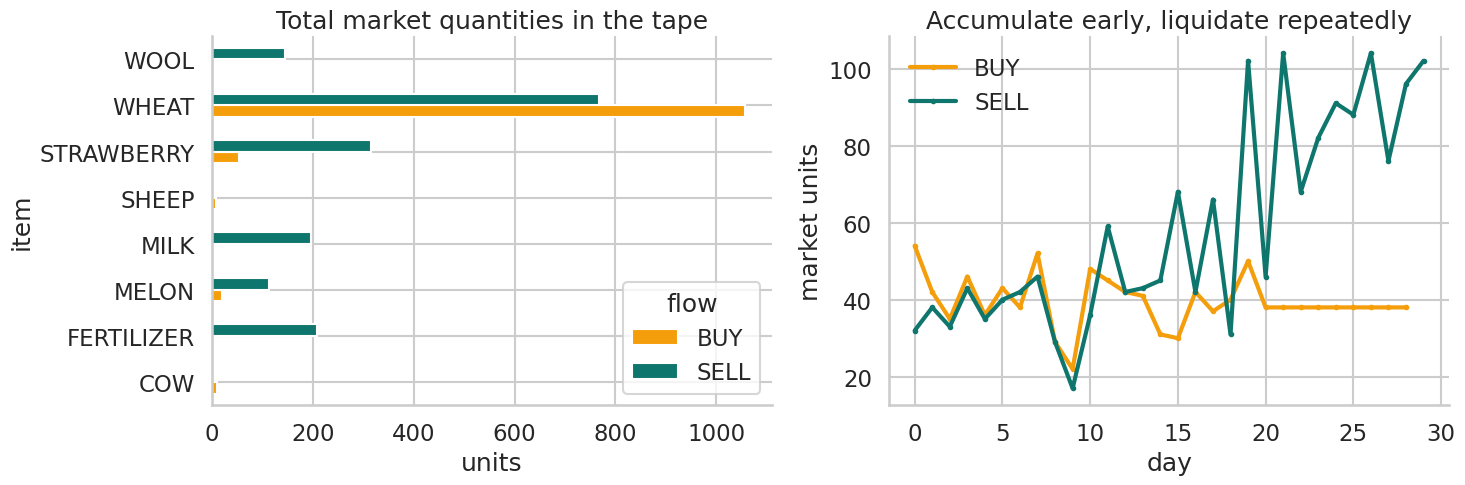

flow,BUY,SELL
item,,
COW,9.0,0.0
FERTILIZER,0.0,209.0
MELON,19.0,113.0
MILK,0.0,197.0
SHEEP,7.0,0.0
STRAWBERRY,53.0,315.0
WHEAT,1057.0,767.0
WOOL,0.0,145.0


In [9]:
MARKET_ROWS = [{'day': 0, 'verb': 'BUY_ANIMAL', 'item': 'COW', 'quantity': 3.0}, {'day': 0, 'verb': 'BUY_SEED', 'item': 'MELON', 'quantity': 6.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 0, 'verb': 'BUY_ANIMAL', 'item': 'SHEEP', 'quantity': 1.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 0, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 0, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 1, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 1, 'verb': 'BUY_SEED', 'item': 'MELON', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 1, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'BUY_SEED', 'item': 'MELON', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 2, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 3, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'BUY_SEED', 'item': 'MELON', 'quantity': 2.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 3, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 3, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 3, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 3, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 4, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 5, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 6, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 6, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 6.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 6, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 6, 'verb': 'BUY_ANIMAL', 'item': 'COW', 'quantity': 2.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 5.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 4.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 7, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 8, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 5.0}, {'day': 8, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 8, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 5.0}, {'day': 8, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 8, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 8, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 8, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 8, 'verb': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 8, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 8, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 8, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 8, 'verb': 'SELL', 'item': 'MILK', 'quantity': 5.0}, {'day': 8, 'verb': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 8, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 8, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 8, 'verb': 'BUY_ANIMAL', 'item': 'SHEEP', 'quantity': 3.0}, {'day': 8, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 6.0}, {'day': 8, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 7.0}, {'day': 9, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 9, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 5.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 5.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 9, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 9, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 10, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 9.0}, {'day': 10, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 3.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 9.0}, {'day': 10, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 5.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 5.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 10, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 10, 'verb': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 10, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 10, 'verb': 'BUY_ANIMAL', 'item': 'COW', 'quantity': 1.0}, {'day': 10, 'verb': 'BUY_SEED', 'item': 'MELON', 'quantity': 6.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 10, 'verb': 'SELL', 'item': 'MELON', 'quantity': 12.0}, {'day': 10, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 10, 'verb': 'BUY_ANIMAL', 'item': 'COW', 'quantity': 3.0}, {'day': 10, 'verb': 'BUY_SEED', 'item': 'MELON', 'quantity': 2.0}, {'day': 10, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 10, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 3.0}, {'day': 11, 'verb': 'SELL', 'item': 'MELON', 'quantity': 24.0}, {'day': 11, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 11, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 11, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 12.0}, {'day': 11, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 11, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 11, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 6.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 3.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 11, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 11, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 11, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 11, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 11, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 12, 'verb': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 12, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 12.0}, {'day': 12, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 12, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 12.0}, {'day': 12, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 12, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 12, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 12, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 12, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 12, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 12, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 12, 'verb': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 12, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 13, 'verb': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 13, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 13, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 7.0}, {'day': 13, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 12.0}, {'day': 13, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 12.0}, {'day': 13, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 13, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 13, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 13, 'verb': 'BUY_SEED', 'item': 'MELON', 'quantity': 1.0}, {'day': 13, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 13, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 13, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 13, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 13, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 13, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 13, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 14, 'verb': 'SELL', 'item': 'MELON', 'quantity': 12.0}, {'day': 14, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 12.0}, {'day': 14, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 14, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 4.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 12.0}, {'day': 14, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 14, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 14, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 14, 'verb': 'BUY_SEED', 'item': 'STRAWBERRY', 'quantity': 1.0}, {'day': 14, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 14, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 6.0}, {'day': 15, 'verb': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 15, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 11.0}, {'day': 15, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 15, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 6.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 11.0}, {'day': 15, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 8.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 15, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 15, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 15, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 15, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 15, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 10.0}, {'day': 15, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 15, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 15, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 15, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 16, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 6.0}, {'day': 16, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 16, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 13.0}, {'day': 16, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 16, 'verb': 'BUY_ANIMAL', 'item': 'SHEEP', 'quantity': 3.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 17.0}, {'day': 16, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 16, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 16, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 16, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 16, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 17, 'verb': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 17, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 17, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 17, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 8.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 17, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 17, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 17, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 17, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 12.0}, {'day': 17, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 4.0}, {'day': 17, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 10.0}, {'day': 18, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 18, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 18, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 13.0}, {'day': 18, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 9.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 18, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 18, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 19, 'verb': 'SELL', 'item': 'MILK', 'quantity': 15.0}, {'day': 19, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 12.0}, {'day': 19, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 10.0}, {'day': 19, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 19, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 7.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 19, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 19, 'verb': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 19, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 12.0}, {'day': 19, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 19, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 19, 'verb': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 19, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 19, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 19, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 12.0}, {'day': 20, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 12.0}, {'day': 20, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 13.0}, {'day': 20, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 7.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 13.0}, {'day': 20, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 20, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 20, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 20, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'SELL', 'item': 'MELON', 'quantity': 24.0}, {'day': 21, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 16.0}, {'day': 21, 'verb': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 21, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 21, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 21, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 21, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 21, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 21, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 21, 'verb': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 21, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 21, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 22, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 18.0}, {'day': 22, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 8.0}, {'day': 22, 'verb': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 22, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 22, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 9.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 22, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 22, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 22, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 23, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 20.0}, {'day': 23, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 11.0}, {'day': 23, 'verb': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 23, 'verb': 'SELL', 'item': 'MELON', 'quantity': 11.0}, {'day': 23, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 23, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 7.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 23, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 23, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 24, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 25.0}, {'day': 24, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 10.0}, {'day': 24, 'verb': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 24, 'verb': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 24, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 24, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 8.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 24, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 24, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 24, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 6.0}, {'day': 24, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 25, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 22.0}, {'day': 25, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 12.0}, {'day': 25, 'verb': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 25, 'verb': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 25, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 25, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 25, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 25, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 6.0}, {'day': 25, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 25, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 36.0}, {'day': 26, 'verb': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 26, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 26, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 26, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 9.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 26, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 26, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 26, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 26, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 8.0}, {'day': 26, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 26, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 27, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 8.0}, {'day': 27, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 12.0}, {'day': 27, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 27, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 27, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 8.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 27, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 27, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 27, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 6.0}, {'day': 27, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 27, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 27, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 27, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 27, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 27, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 28, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 26.0}, {'day': 28, 'verb': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 28, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 28, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 28, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 10.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 28, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 28, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 28, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 6.0}, {'day': 28, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 28, 'verb': 'BUY_PRODUCT', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 28, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 28, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 6.0}, {'day': 28, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 28, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 28, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 1.0}, {'day': 29, 'verb': 'SELL', 'item': 'MILK', 'quantity': 12.0}, {'day': 29, 'verb': 'SELL', 'item': 'WHEAT', 'quantity': 32.0}, {'day': 29, 'verb': 'SELL', 'item': 'FERTILIZER', 'quantity': 15.0}, {'day': 29, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 29, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 29, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 29, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 5.0}, {'day': 29, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 3.0}, {'day': 29, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 29, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 29, 'verb': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 29, 'verb': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 29, 'verb': 'SELL', 'item': 'STRAWBERRY', 'quantity': 10.0}]
market = pd.DataFrame(MARKET_ROWS)
market["flow"] = np.where(market.verb.str.startswith("SELL"), "SELL", "BUY")
product_flow = market.pivot_table(index="item", columns="flow", values="quantity", aggfunc="sum", fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
product_flow.plot(kind="barh", ax=axes[0], color=[COLORS[1], COLORS[0]])
axes[0].set(title="Total market quantities in the tape", xlabel="units", ylabel="item")
by_day = market.groupby(["day", "flow"], as_index=False).quantity.sum()
for flow, color in (("BUY", COLORS[1]), ("SELL", COLORS[0])):
    part = by_day[by_day.flow == flow]
    axes[1].plot(part.day, part.quantity, lw=3, marker="o", ms=3, color=color, label=flow)
axes[1].set(title="Accumulate early, liquidate repeatedly", xlabel="day", ylabel="market units")
axes[1].legend(frameon=False)
sns.despine(); plt.tight_layout(); plt.show()
display(product_flow)


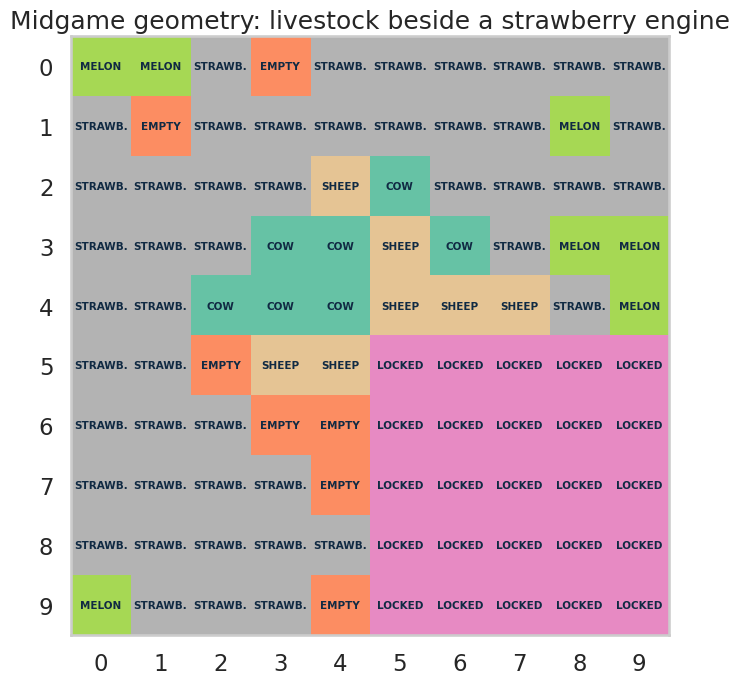

In [10]:
GEOMETRY = [['MELON', 'MELON', 'STRAWBERRY', 'EMPTY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY'], ['STRAWBERRY', 'EMPTY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'MELON', 'STRAWBERRY'], ['STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'SHEEP', 'COW', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY'], ['STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'COW', 'COW', 'SHEEP', 'COW', 'STRAWBERRY', 'MELON', 'MELON'], ['STRAWBERRY', 'STRAWBERRY', 'COW', 'COW', 'COW', 'SHEEP', 'SHEEP', 'SHEEP', 'STRAWBERRY', 'MELON'], ['STRAWBERRY', 'STRAWBERRY', 'EMPTY', 'SHEEP', 'SHEEP', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'EMPTY', 'EMPTY', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'EMPTY', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['MELON', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'EMPTY', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED']]
labels = np.array(GEOMETRY)
categories = sorted(set(labels.ravel()))
palette = {name: i for i, name in enumerate(categories)}
grid = np.vectorize(palette.get)(labels)
fig, ax = plt.subplots(figsize=(9, 7.2))
cmap = sns.color_palette("Set2", n_colors=max(3, len(categories)), as_cmap=True)
ax.imshow(grid, cmap=cmap, vmin=0, vmax=max(1, len(categories)-1))
for y in range(labels.shape[0]):
    for x in range(labels.shape[1]):
        text = labels[y, x].replace("STRAWBERRY", "STRAWB.")
        ax.text(x, y, text, ha="center", va="center", fontsize=7.5, color="#102a43", fontweight="bold")
ax.set(title="Midgame geometry: livestock beside a strawberry engine", xticks=range(10), yticks=range(10))
ax.grid(False); plt.tight_layout(); plt.show()


## 4. Untouched-seed promotion gate

The candidate below was frozen before this larger matrix. Each pairing uses complete 720-turn games from both player positions. Opponents include strong public notebooks, prior versions, fixed portfolio counters, and freshly downloaded public agents. The heatmaps expose failures instead of hiding them behind one aggregate.


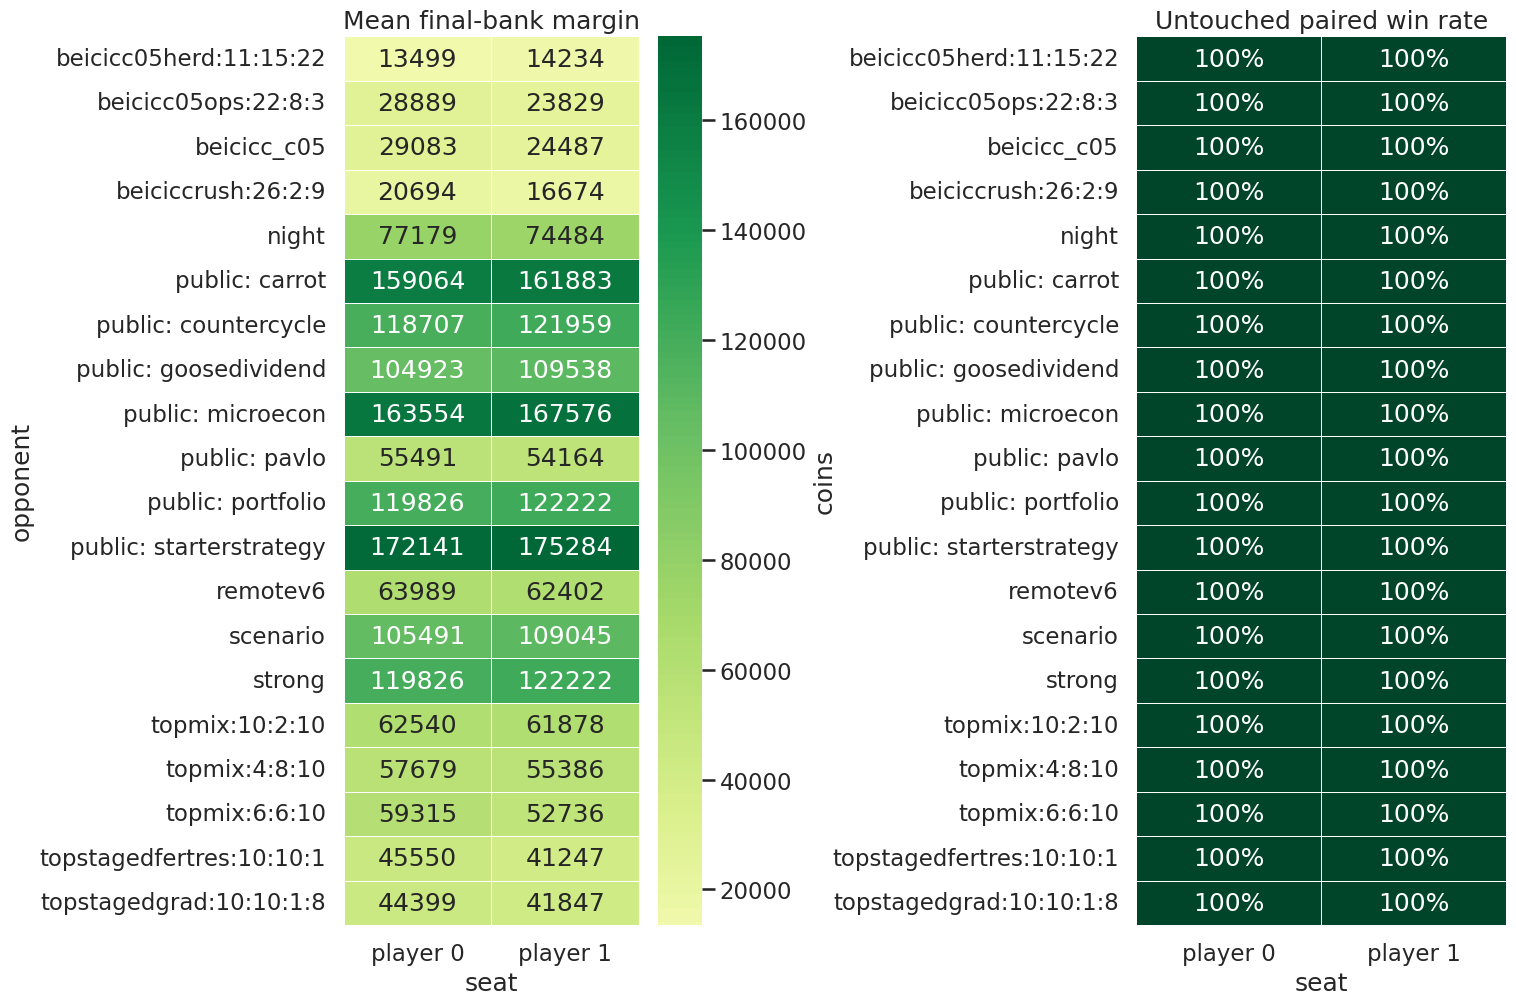

{'games': 160, 'wins': 160, 'win_rate': 1.0, 'mean_money': 145818.775, 'mean_margin': 80873.325, 'minimum_margin': 4708.0, 'all_done': True}


,opponent_label,side,games,wins,mean_margin,min_margin,mean_money,win_rate
23,public: starterstrategy,1,4,4,175284.25,159175.0,177222.00,1.0
22,public: starterstrategy,0,4,4,172140.75,165226.0,174086.00,1.0
17,public: microecon,1,4,4,167576.25,145388.0,167656.25,1.0
16,public: microecon,0,4,4,163553.75,153642.0,163633.75,1.0
11,public: carrot,1,4,4,161883.00,157630.0,171104.25,1.0
10,public: carrot,0,4,4,159064.50,147255.0,168075.00,1.0
21,public: portfolio,1,4,4,122221.50,115459.0,162812.25,1.0
29,strong,1,4,4,122221.50,115459.0,162812.25,1.0
13,public: countercycle,1,4,4,121959.25,113778.0,159713.75,1.0
20,public: portfolio,0,4,4,119825.50,113750.0,160240.25,1.0


In [11]:
BENCHMARK_ROWS = [{'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 0, 'candidate_money': 103631.0, 'opponent_money': 103720.0, 'margin': -89.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 12.356459958002233}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 1, 'candidate_money': 103720.0, 'opponent_money': 103631.0, 'margin': 89.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 12.139992999997048}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 0, 'candidate_money': 112362.0, 'opponent_money': 112362.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 12.61575270799949}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 1, 'candidate_money': 112362.0, 'opponent_money': 112362.0, 'margin': 0.0, 'win': False, 'tie': True, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 12.41544445800173}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 0, 'candidate_money': 119260.0, 'opponent_money': 119025.0, 'margin': 235.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 12.381592500001716}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 1, 'candidate_money': 119025.0, 'opponent_money': 119260.0, 'margin': -235.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 12.186106000001018}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 0, 'candidate_money': 94231.0, 'opponent_money': 96708.0, 'margin': -2477.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 12.683731959001307}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 1, 'candidate_money': 96708.0, 'opponent_money': 94231.0, 'margin': 2477.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 12.414178499999252}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 0, 'candidate_money': 115180.0, 'opponent_money': 111724.0, 'margin': 3456.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 11.80560287499975}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 1, 'candidate_money': 115180.0, 'opponent_money': 111724.0, 'margin': 3456.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 12.10847108300004}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 0, 'candidate_money': 99548.0, 'opponent_money': 98696.0, 'margin': 852.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 11.989610500000708}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 1, 'candidate_money': 110963.0, 'opponent_money': 102460.0, 'margin': 8503.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 11.952426040999853}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 0, 'candidate_money': 121130.0, 'opponent_money': 121546.0, 'margin': -416.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 11.775358291000884}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 1, 'candidate_money': 115264.0, 'opponent_money': 122581.0, 'margin': -7317.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 11.028180666999106}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 0, 'candidate_money': 83499.0, 'opponent_money': 76139.0, 'margin': 7360.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.567997500002093}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 1, 'candidate_money': 101913.0, 'opponent_money': 94618.0, 'margin': 7295.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.392020375002176}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 0, 'candidate_money': 115126.0, 'opponent_money': 110304.0, 'margin': 4822.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.05037295800139}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 1, 'candidate_money': 115126.0, 'opponent_money': 110304.0, 'margin': 4822.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.76969333300076}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 0, 'candidate_money': 99467.0, 'opponent_money': 97781.0, 'margin': 1686.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.62063662500077}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 1, 'candidate_money': 110905.0, 'opponent_money': 101568.0, 'margin': 9337.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.660169832997781}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 0, 'candidate_money': 121092.0, 'opponent_money': 119861.0, 'margin': 1231.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.571424207999371}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 1, 'candidate_money': 115257.0, 'opponent_money': 120107.0, 'margin': -4850.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.543895666000026}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 0, 'candidate_money': 83452.0, 'opponent_money': 76144.0, 'margin': 7308.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.643017333000898}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 1, 'candidate_money': 102034.0, 'opponent_money': 93712.0, 'margin': 8322.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.614739667002141}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 0, 'candidate_money': 105854.0, 'opponent_money': 96618.0, 'margin': 9236.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.4819503750004515}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 1, 'candidate_money': 117241.0, 'opponent_money': 100264.0, 'margin': 16977.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.241056667000521}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 0, 'candidate_money': 84541.0, 'opponent_money': 72910.0, 'margin': 11631.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.373977333998482}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 1, 'candidate_money': 93840.0, 'opponent_money': 82925.0, 'margin': 10915.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.476986917001341}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 0, 'candidate_money': 117466.0, 'opponent_money': 116039.0, 'margin': 1427.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.573996666997118}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 1, 'candidate_money': 118648.0, 'opponent_money': 119077.0, 'margin': -429.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.621992542000953}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 0, 'candidate_money': 111451.0, 'opponent_money': 112342.0, 'margin': -891.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.575431917000969}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 1, 'candidate_money': 107929.0, 'opponent_money': 104730.0, 'margin': 3199.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.489476499999}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'night', 'seed': 7001, 'side': 0, 'candidate_money': 127299.0, 'opponent_money': 76589.0, 'margin': 50710.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 8.083797332998074}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'night', 'seed': 7001, 'side': 1, 'candidate_money': 125896.0, 'opponent_money': 77830.0, 'margin': 48066.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 8.117126334000204}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'night', 'seed': 7002, 'side': 0, 'candidate_money': 108870.0, 'opponent_money': 76257.0, 'margin': 32613.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 8.281476916999964}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'night', 'seed': 7002, 'side': 1, 'candidate_money': 116605.0, 'opponent_money': 73555.0, 'margin': 43050.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 8.296021957998164}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'night', 'seed': 7003, 'side': 0, 'candidate_money': 129338.0, 'opponent_money': 88357.0, 'margin': 40981.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 8.286660083002062}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'night', 'seed': 7003, 'side': 1, 'candidate_money': 126815.0, 'opponent_money': 88525.0, 'margin': 38290.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 8.29519912500109}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'night', 'seed': 7004, 'side': 0, 'candidate_money': 123834.0, 'opponent_money': 80083.0, 'margin': 43751.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 8.142805249997764}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'night', 'seed': 7004, 'side': 1, 'candidate_money': 115794.0, 'opponent_money': 79853.0, 'margin': 35941.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 8.016949708999164}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 0, 'candidate_money': 130933.0, 'opponent_money': 7086.0, 'margin': 123847.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0012767919979524}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 1, 'candidate_money': 130933.0, 'opponent_money': 7086.0, 'margin': 123847.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.959200207998947}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 0, 'candidate_money': 136725.0, 'opponent_money': 5795.0, 'margin': 130930.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9882063749973895}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 1, 'candidate_money': 139435.0, 'opponent_money': 7289.0, 'margin': 132146.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.8948894169989217}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 0, 'candidate_money': 136500.0, 'opponent_money': 7486.0, 'margin': 129014.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0006774159992347}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 1, 'candidate_money': 138467.0, 'opponent_money': 8258.0, 'margin': 130209.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.8788941249986237}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 0, 'candidate_money': 136688.0, 'opponent_money': 7409.0, 'margin': 129279.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9287932089973765}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 1, 'candidate_money': 144694.0, 'opponent_money': 7049.0, 'margin': 137645.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.9809472919987456}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 0, 'candidate_money': 121284.0, 'opponent_money': 41394.0, 'margin': 79890.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.367316625000967}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 1, 'candidate_money': 131060.0, 'opponent_money': 37338.0, 'margin': 93722.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.372380791999603}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 0, 'candidate_money': 129728.0, 'opponent_money': 36191.0, 'margin': 93537.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.312051500000962}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 1, 'candidate_money': 125410.0, 'opponent_money': 30746.0, 'margin': 94664.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.337434375000157}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 0, 'candidate_money': 120540.0, 'opponent_money': 44750.0, 'margin': 75790.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.28688316699845}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 1, 'candidate_money': 122893.0, 'opponent_money': 44787.0, 'margin': 78106.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.303953999999067}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 0, 'candidate_money': 129740.0, 'opponent_money': 42840.0, 'margin': 86900.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.436630415999389}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 1, 'candidate_money': 128402.0, 'opponent_money': 44510.0, 'margin': 83892.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.352206874998956}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 0, 'candidate_money': 132347.0, 'opponent_money': 47108.0, 'margin': 85239.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.686003124999843}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 1, 'candidate_money': 132323.0, 'opponent_money': 47135.0, 'margin': 85188.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.704757499999687}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 0, 'candidate_money': 121197.0, 'opponent_money': 46834.0, 'margin': 74363.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.702556584001286}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 1, 'candidate_money': 126491.0, 'opponent_money': 47868.0, 'margin': 78623.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.733486666002136}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 0, 'candidate_money': 132330.0, 'opponent_money': 47451.0, 'margin': 84879.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.688000457997987}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 1, 'candidate_money': 132336.0, 'opponent_money': 47189.0, 'margin': 85147.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.6166011249988514}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 0, 'candidate_money': 130697.0, 'opponent_money': 47532.0, 'margin': 83165.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.735669290999795}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 1, 'candidate_money': 132208.0, 'opponent_money': 46784.0, 'margin': 85424.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.731320958999277}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 0, 'candidate_money': 146983.0, 'opponent_money': 80.0, 'margin': 146903.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.541495458001009}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 1, 'candidate_money': 148204.0, 'opponent_money': 80.0, 'margin': 148124.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.5965586670026823}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 0, 'candidate_money': 141807.0, 'opponent_money': 80.0, 'margin': 141727.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.488109792000614}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 1, 'candidate_money': 145294.0, 'opponent_money': 80.0, 'margin': 145214.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.5386886250016687}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 0, 'candidate_money': 144880.0, 'opponent_money': 80.0, 'margin': 144800.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.5810479589999886}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 1, 'candidate_money': 148749.0, 'opponent_money': 80.0, 'margin': 148669.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.5381457500006945}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 0, 'candidate_money': 143832.0, 'opponent_money': 80.0, 'margin': 143752.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.5693288750007923}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 1, 'candidate_money': 142174.0, 'opponent_money': 80.0, 'margin': 142094.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.5972815830027685}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 0, 'candidate_money': 115204.0, 'opponent_money': 99099.0, 'margin': 16105.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7161457919974055}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 1, 'candidate_money': 113668.0, 'opponent_money': 78649.0, 'margin': 35019.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.754053374999785}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 0, 'candidate_money': 124724.0, 'opponent_money': 89785.0, 'margin': 34939.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.68147558399869}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 1, 'candidate_money': 115588.0, 'opponent_money': 88937.0, 'margin': 26651.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7352027080014523}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 0, 'candidate_money': 117004.0, 'opponent_money': 91093.0, 'margin': 25911.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.727650625001843}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 1, 'candidate_money': 118330.0, 'opponent_money': 90260.0, 'margin': 28070.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.6326501660005306}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 0, 'candidate_money': 116048.0, 'opponent_money': 91974.0, 'margin': 24074.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.6551775830012048}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 1, 'candidate_money': 108329.0, 'opponent_money': 87616.0, 'margin': 20713.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.621968375002325}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 0, 'candidate_money': 107752.0, 'opponent_money': 36928.0, 'margin': 70824.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.206530249997741}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 1, 'candidate_money': 110616.0, 'opponent_money': 36667.0, 'margin': 73949.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.193190792000678}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 0, 'candidate_money': 126567.0, 'opponent_money': 37145.0, 'margin': 89422.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.170747249998385}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 1, 'candidate_money': 131774.0, 'opponent_money': 37703.0, 'margin': 94071.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.1349663750006584}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 0, 'candidate_money': 121908.0, 'opponent_money': 39911.0, 'margin': 81997.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.300559416999022}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 1, 'candidate_money': 125862.0, 'opponent_money': 37698.0, 'margin': 88164.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.091146415998082}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 0, 'candidate_money': 112137.0, 'opponent_money': 37754.0, 'margin': 74383.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.1250796250023996}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 1, 'candidate_money': 112077.0, 'opponent_money': 36936.0, 'margin': 75141.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.2364019169981475}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 0, 'candidate_money': 141580.0, 'opponent_money': 1961.0, 'margin': 139619.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.7554694169994036}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 1, 'candidate_money': 141580.0, 'opponent_money': 1961.0, 'margin': 139619.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.7845763329969486}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 0, 'candidate_money': 128730.0, 'opponent_money': 1891.0, 'margin': 126839.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.7188929170006304}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 1, 'candidate_money': 131618.0, 'opponent_money': 1879.0, 'margin': 129739.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.690585166001256}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 0, 'candidate_money': 135919.0, 'opponent_money': 1954.0, 'margin': 133965.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.710660541000834}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 1, 'candidate_money': 135919.0, 'opponent_money': 1954.0, 'margin': 133965.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.6617674160006572}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 0, 'candidate_money': 148307.0, 'opponent_money': 1738.0, 'margin': 146569.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.664317583999946}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 1, 'candidate_money': 142988.0, 'opponent_money': 2002.0, 'margin': 140986.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.715029125000001}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'remotev6', 'seed': 7001, 'side': 0, 'candidate_money': 112575.0, 'opponent_money': 73730.0, 'margin': 38845.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.826831750000565}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'remotev6', 'seed': 7001, 'side': 1, 'candidate_money': 113420.0, 'opponent_money': 73750.0, 'margin': 39670.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.86825666599907}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'remotev6', 'seed': 7002, 'side': 0, 'candidate_money': 110968.0, 'opponent_money': 85484.0, 'margin': 25484.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.783757875000447}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'remotev6', 'seed': 7002, 'side': 1, 'candidate_money': 112999.0, 'opponent_money': 79618.0, 'margin': 33381.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.861571583998739}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'remotev6', 'seed': 7003, 'side': 0, 'candidate_money': 128992.0, 'opponent_money': 91784.0, 'margin': 37208.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.92123087499931}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'remotev6', 'seed': 7003, 'side': 1, 'candidate_money': 127935.0, 'opponent_money': 91675.0, 'margin': 36260.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.84879170899876}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'remotev6', 'seed': 7004, 'side': 0, 'candidate_money': 128840.0, 'opponent_money': 87901.0, 'margin': 40939.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.8108273329999065}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'remotev6', 'seed': 7004, 'side': 1, 'candidate_money': 127402.0, 'opponent_money': 87090.0, 'margin': 40312.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.686991542002943}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'scenario', 'seed': 7001, 'side': 0, 'candidate_money': 118747.0, 'opponent_money': 44863.0, 'margin': 73884.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.209882499999367}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'scenario', 'seed': 7001, 'side': 1, 'candidate_money': 118733.0, 'opponent_money': 44798.0, 'margin': 73935.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.174870790997375}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'scenario', 'seed': 7002, 'side': 0, 'candidate_money': 110061.0, 'opponent_money': 48661.0, 'margin': 61400.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.22955945799913}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'scenario', 'seed': 7002, 'side': 1, 'candidate_money': 111283.0, 'opponent_money': 49131.0, 'margin': 62152.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.432153542002197}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'scenario', 'seed': 7003, 'side': 0, 'candidate_money': 127610.0, 'opponent_money': 51817.0, 'margin': 75793.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.4490828340021835}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'scenario', 'seed': 7003, 'side': 1, 'candidate_money': 134125.0, 'opponent_money': 49960.0, 'margin': 84165.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.328857084001356}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'scenario', 'seed': 7004, 'side': 0, 'candidate_money': 122052.0, 'opponent_money': 46255.0, 'margin': 75797.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.495491792000394}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'scenario', 'seed': 7004, 'side': 1, 'candidate_money': 119272.0, 'opponent_money': 47338.0, 'margin': 71934.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.400863124999887}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'strong', 'seed': 7001, 'side': 0, 'candidate_money': 107752.0, 'opponent_money': 36928.0, 'margin': 70824.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.71823837500051}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'strong', 'seed': 7001, 'side': 1, 'candidate_money': 110616.0, 'opponent_money': 36667.0, 'margin': 73949.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.653152207996754}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'strong', 'seed': 7002, 'side': 0, 'candidate_money': 126567.0, 'opponent_money': 37145.0, 'margin': 89422.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.714425750000373}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'strong', 'seed': 7002, 'side': 1, 'candidate_money': 131774.0, 'opponent_money': 37703.0, 'margin': 94071.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.654039291999652}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'strong', 'seed': 7003, 'side': 0, 'candidate_money': 121908.0, 'opponent_money': 39911.0, 'margin': 81997.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.662915208999038}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'strong', 'seed': 7003, 'side': 1, 'candidate_money': 125862.0, 'opponent_money': 37698.0, 'margin': 88164.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.669209667001269}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'strong', 'seed': 7004, 'side': 0, 'candidate_money': 112137.0, 'opponent_money': 37754.0, 'margin': 74383.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.602430083999934}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'strong', 'seed': 7004, 'side': 1, 'candidate_money': 112077.0, 'opponent_money': 36936.0, 'margin': 75141.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.646442208002554}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 0, 'candidate_money': 113339.0, 'opponent_money': 71147.0, 'margin': 42192.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.865545500000735}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 1, 'candidate_money': 111430.0, 'opponent_money': 71721.0, 'margin': 39709.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.930395957999281}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 0, 'candidate_money': 115225.0, 'opponent_money': 98627.0, 'margin': 16598.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.9459557079972}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 1, 'candidate_money': 119440.0, 'opponent_money': 96875.0, 'margin': 22565.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.99892616699799}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 0, 'candidate_money': 113391.0, 'opponent_money': 95010.0, 'margin': 18381.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.7673288750011125}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 1, 'candidate_money': 108585.0, 'opponent_money': 94679.0, 'margin': 13906.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.778788291998353}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 0, 'candidate_money': 105757.0, 'opponent_money': 93420.0, 'margin': 12337.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.58985258300163}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 1, 'candidate_money': 110314.0, 'opponent_money': 95281.0, 'margin': 15033.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.586853125001653}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 0, 'candidate_money': 111829.0, 'opponent_money': 92144.0, 'margin': 19685.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.65998983299869}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 1, 'candidate_money': 114794.0, 'opponent_money': 92184.0, 'margin': 22610.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.708329084001889}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 0, 'candidate_money': 105805.0, 'opponent_money': 84879.0, 'margin': 20926.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.536663792001491}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 1, 'candidate_money': 114021.0, 'opponent_money': 79924.0, 'margin': 34097.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.30559758399977}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 0, 'candidate_money': 119657.0, 'opponent_money': 97286.0, 'margin': 22371.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.4625018750011805}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 1, 'candidate_money': 116900.0, 'opponent_money': 98449.0, 'margin': 18451.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.524208041999373}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 0, 'candidate_money': 121178.0, 'opponent_money': 88017.0, 'margin': 33161.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.304295042002195}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 1, 'candidate_money': 126478.0, 'opponent_money': 66344.0, 'margin': 60134.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.346311583001807}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 0, 'candidate_money': 105426.0, 'opponent_money': 77297.0, 'margin': 28129.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.889654124999652}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 1, 'candidate_money': 111816.0, 'opponent_money': 89601.0, 'margin': 22215.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.7272020839991455}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 0, 'candidate_money': 112010.0, 'opponent_money': 86646.0, 'margin': 25364.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.572270791999472}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 1, 'candidate_money': 111220.0, 'opponent_money': 84281.0, 'margin': 26939.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.750973375001195}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 0, 'candidate_money': 122392.0, 'opponent_money': 94993.0, 'margin': 27399.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.5563199169992}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 1, 'candidate_money': 118014.0, 'opponent_money': 96565.0, 'margin': 21449.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.529218790998129}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 0, 'candidate_money': 122476.0, 'opponent_money': 84955.0, 'margin': 37521.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.583772624999256}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 1, 'candidate_money': 114654.0, 'opponent_money': 83748.0, 'margin': 30906.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.506068041999242}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 0, 'candidate_money': 120784.0, 'opponent_money': 102094.0, 'margin': 18690.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.858542167003179}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 1, 'candidate_money': 123886.0, 'opponent_money': 101378.0, 'margin': 22508.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.9188324160022603}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 0, 'candidate_money': 111400.0, 'opponent_money': 94882.0, 'margin': 16518.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.8814663750017644}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 1, 'candidate_money': 110375.0, 'opponent_money': 98351.0, 'margin': 12024.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.853168999998161}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 0, 'candidate_money': 107543.0, 'opponent_money': 92743.0, 'margin': 14800.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.8727334169998358}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 1, 'candidate_money': 104086.0, 'opponent_money': 87142.0, 'margin': 16944.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.8903269590009586}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 0, 'candidate_money': 97171.0, 'opponent_money': 83778.0, 'margin': 13393.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.745388291998097}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 1, 'candidate_money': 110760.0, 'opponent_money': 97746.0, 'margin': 13014.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7606342090002727}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 0, 'candidate_money': 96087.0, 'opponent_money': 78388.0, 'margin': 17699.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.626534292001452}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 1, 'candidate_money': 94947.0, 'opponent_money': 90861.0, 'margin': 4086.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.6404843749987776}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 0, 'candidate_money': 106929.0, 'opponent_money': 103278.0, 'margin': 3651.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.667459583000891}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 1, 'candidate_money': 103880.0, 'opponent_money': 101342.0, 'margin': 2538.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.729849750001449}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 0, 'candidate_money': 111371.0, 'opponent_money': 98371.0, 'margin': 13000.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.700031583000964}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 1, 'candidate_money': 122636.0, 'opponent_money': 102309.0, 'margin': 20327.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7657270829986373}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 0, 'candidate_money': 105258.0, 'opponent_money': 96485.0, 'margin': 8773.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.713646249998419}, {'challenger': 'beicicc05herd:11:15:22', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 1, 'candidate_money': 108770.0, 'opponent_money': 94214.0, 'margin': 14556.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.758295999999973}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 0, 'candidate_money': 108198.0, 'opponent_money': 103490.0, 'margin': 4708.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.077853707996837}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 1, 'candidate_money': 108213.0, 'opponent_money': 103497.0, 'margin': 4716.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.850811167001666}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 0, 'candidate_money': 124340.0, 'opponent_money': 101816.0, 'margin': 22524.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.821245207996981}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 1, 'candidate_money': 141949.0, 'opponent_money': 115246.0, 'margin': 26703.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.750617334000708}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 0, 'candidate_money': 112595.0, 'opponent_money': 105571.0, 'margin': 7024.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.826666915996611}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 1, 'candidate_money': 116735.0, 'opponent_money': 104322.0, 'margin': 12413.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.814861541002756}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 0, 'candidate_money': 128468.0, 'opponent_money': 108727.0, 'margin': 19741.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.620899333996931}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 1, 'candidate_money': 120480.0, 'opponent_money': 107378.0, 'margin': 13102.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.772085832999437}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 0, 'candidate_money': 116816.0, 'opponent_money': 105101.0, 'margin': 11715.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.6236930419981945}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 1, 'candidate_money': 116655.0, 'opponent_money': 106139.0, 'margin': 10516.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.699183417000313}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 0, 'candidate_money': 139566.0, 'opponent_money': 105583.0, 'margin': 33983.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.629029333998915}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 1, 'candidate_money': 138999.0, 'opponent_money': 106023.0, 'margin': 32976.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.595479042000079}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 0, 'candidate_money': 125129.0, 'opponent_money': 74250.0, 'margin': 50879.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.540132709000318}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 1, 'candidate_money': 124958.0, 'opponent_money': 78979.0, 'margin': 45979.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.654841083000065}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 0, 'candidate_money': 140408.0, 'opponent_money': 121428.0, 'margin': 18980.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.638948790998256}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 1, 'candidate_money': 118632.0, 'opponent_money': 112787.0, 'margin': 5845.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.628130791999865}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 0, 'candidate_money': 116731.0, 'opponent_money': 104562.0, 'margin': 12169.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.61783608299811}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 1, 'candidate_money': 116556.0, 'opponent_money': 105039.0, 'margin': 11517.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.552458374997514}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 0, 'candidate_money': 139473.0, 'opponent_money': 104934.0, 'margin': 34539.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.749790834001033}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 1, 'candidate_money': 138880.0, 'opponent_money': 104971.0, 'margin': 33909.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.628896042002452}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 0, 'candidate_money': 124995.0, 'opponent_money': 74428.0, 'margin': 50567.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.598045124999771}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 1, 'candidate_money': 124597.0, 'opponent_money': 79248.0, 'margin': 45349.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.627882917000534}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 0, 'candidate_money': 140334.0, 'opponent_money': 121276.0, 'margin': 19058.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.684204334000242}, {'challenger': 'radianttrace:89256171', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 1, 'candidate_money': 118578.0, 'opponent_money': 111406.0, 'margin': 7172.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.751938707999216}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 0, 'candidate_money': 111365.0, 'opponent_money': 103095.0, 'margin': 8270.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.657415290999779}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 1, 'candidate_money': 111365.0, 'opponent_money': 103097.0, 'margin': 8268.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.719985333002114}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 0, 'candidate_money': 128318.0, 'opponent_money': 107218.0, 'margin': 21100.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.6895409999997355}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 1, 'candidate_money': 130082.0, 'opponent_money': 108205.0, 'margin': 21877.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.748106041999563}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 0, 'candidate_money': 138804.0, 'opponent_money': 107193.0, 'margin': 31611.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.733247874999506}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 1, 'candidate_money': 132947.0, 'opponent_money': 107201.0, 'margin': 25746.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.814805707999767}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 0, 'candidate_money': 137196.0, 'opponent_money': 115403.0, 'margin': 21793.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.6980968750031025}, {'challenger': 'radianttrace:89256171', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 1, 'candidate_money': 125078.0, 'opponent_money': 114272.0, 'margin': 10806.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.671447959000943}, {'challenger': 'radianttrace:89256171', 'opponent': 'night', 'seed': 7001, 'side': 0, 'candidate_money': 155164.0, 'opponent_money': 67273.0, 'margin': 87891.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.230336417000217}, {'challenger': 'radianttrace:89256171', 'opponent': 'night', 'seed': 7001, 'side': 1, 'candidate_money': 138918.0, 'opponent_money': 56055.0, 'margin': 82863.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.4096355000001495}, {'challenger': 'radianttrace:89256171', 'opponent': 'night', 'seed': 7002, 'side': 0, 'candidate_money': 135610.0, 'opponent_money': 67273.0, 'margin': 68337.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.313557125002262}, {'challenger': 'radianttrace:89256171', 'opponent': 'night', 'seed': 7002, 'side': 1, 'candidate_money': 141590.0, 'opponent_money': 69769.0, 'margin': 71821.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.259919000000082}, {'challenger': 'radianttrace:89256171', 'opponent': 'night', 'seed': 7003, 'side': 0, 'candidate_money': 151311.0, 'opponent_money': 67494.0, 'margin': 83817.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.391572541000642}, {'challenger': 'radianttrace:89256171', 'opponent': 'night', 'seed': 7003, 'side': 1, 'candidate_money': 149114.0, 'opponent_money': 67330.0, 'margin': 81784.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.3913397079995775}, {'challenger': 'radianttrace:89256171', 'opponent': 'night', 'seed': 7004, 'side': 0, 'candidate_money': 140363.0, 'opponent_money': 71693.0, 'margin': 68670.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.139407291997486}, {'challenger': 'radianttrace:89256171', 'opponent': 'night', 'seed': 7004, 'side': 1, 'candidate_money': 134376.0, 'opponent_money': 72906.0, 'margin': 61470.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.300134916000388}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 0, 'candidate_money': 178854.0, 'opponent_money': 9247.0, 'margin': 169607.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.884038666001288}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 1, 'candidate_money': 166877.0, 'opponent_money': 9247.0, 'margin': 157630.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.795029083001282}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 0, 'candidate_money': 156885.0, 'opponent_money': 9630.0, 'margin': 147255.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.798990874998708}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 1, 'candidate_money': 174520.0, 'opponent_money': 10027.0, 'margin': 164493.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.890514874998189}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 0, 'candidate_money': 176003.0, 'opponent_money': 8702.0, 'margin': 167301.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.8050229999971634}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 1, 'candidate_money': 176003.0, 'opponent_money': 9148.0, 'margin': 166855.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.9200504580003326}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 0, 'candidate_money': 160558.0, 'opponent_money': 8463.0, 'margin': 152095.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.780553708998923}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 1, 'candidate_money': 167017.0, 'opponent_money': 8463.0, 'margin': 158554.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.743298457997298}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 0, 'candidate_money': 157905.0, 'opponent_money': 35407.0, 'margin': 122498.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.455899458000204}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 1, 'candidate_money': 155406.0, 'opponent_money': 36077.0, 'margin': 119329.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.841935166001349}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 0, 'candidate_money': 168359.0, 'opponent_money': 41159.0, 'margin': 127200.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.509078874998522}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 1, 'candidate_money': 169821.0, 'opponent_money': 35163.0, 'margin': 134658.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.324563166999724}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 0, 'candidate_money': 157572.0, 'opponent_money': 37500.0, 'margin': 120072.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.488885957998718}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 1, 'candidate_money': 157572.0, 'opponent_money': 37500.0, 'margin': 120072.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.520322249998571}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 0, 'candidate_money': 144923.0, 'opponent_money': 39864.0, 'margin': 105059.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.211405124999146}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 1, 'candidate_money': 156056.0, 'opponent_money': 42278.0, 'margin': 113778.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.302536415998475}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 0, 'candidate_money': 157438.0, 'opponent_money': 52907.0, 'margin': 104531.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.054998958999931}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 1, 'candidate_money': 166181.0, 'opponent_money': 52481.0, 'margin': 113700.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.963752999999997}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 0, 'candidate_money': 159971.0, 'opponent_money': 52350.0, 'margin': 107621.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.92055870799959}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 1, 'candidate_money': 163706.0, 'opponent_money': 53215.0, 'margin': 110491.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.885030749999714}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 0, 'candidate_money': 163773.0, 'opponent_money': 52561.0, 'margin': 111212.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.987892124998325}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 1, 'candidate_money': 163298.0, 'opponent_money': 51735.0, 'margin': 111563.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.811888957996416}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 0, 'candidate_money': 150004.0, 'opponent_money': 53677.0, 'margin': 96327.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.875443708999228}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 1, 'candidate_money': 155435.0, 'opponent_money': 53038.0, 'margin': 102397.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.708771666999382}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 0, 'candidate_money': 175431.0, 'opponent_money': 80.0, 'margin': 175351.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.188996374999988}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 1, 'candidate_money': 177716.0, 'opponent_money': 80.0, 'margin': 177636.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.12839108299886}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 0, 'candidate_money': 169998.0, 'opponent_money': 80.0, 'margin': 169918.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.105518917000154}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 1, 'candidate_money': 178789.0, 'opponent_money': 80.0, 'margin': 178709.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0595897909988707}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 0, 'candidate_money': 153722.0, 'opponent_money': 80.0, 'margin': 153642.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0989740830009396}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 1, 'candidate_money': 145468.0, 'opponent_money': 80.0, 'margin': 145388.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.090925291999156}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 0, 'candidate_money': 155384.0, 'opponent_money': 80.0, 'margin': 155304.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.128023707999091}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 1, 'candidate_money': 168652.0, 'opponent_money': 80.0, 'margin': 168572.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1821429159972467}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 0, 'candidate_money': 161059.0, 'opponent_money': 100182.0, 'margin': 60877.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0902673749988026}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 1, 'candidate_money': 154123.0, 'opponent_money': 97377.0, 'margin': 56746.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.011516374997882}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 0, 'candidate_money': 141218.0, 'opponent_money': 88413.0, 'margin': 52805.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1212782920010795}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 1, 'candidate_money': 142224.0, 'opponent_money': 86846.0, 'margin': 55378.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.9283152089992655}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 0, 'candidate_money': 141893.0, 'opponent_money': 85409.0, 'margin': 56484.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.014846458001557}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 1, 'candidate_money': 132346.0, 'opponent_money': 74901.0, 'margin': 57445.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.125120332999359}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 0, 'candidate_money': 146399.0, 'opponent_money': 94600.0, 'margin': 51799.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.015390166998259}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 1, 'candidate_money': 144778.0, 'opponent_money': 97693.0, 'margin': 47085.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.00198441700195}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 0, 'candidate_money': 165822.0, 'opponent_money': 39696.0, 'margin': 126126.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.773604417001479}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 1, 'candidate_money': 165822.0, 'opponent_money': 39696.0, 'margin': 126126.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.88890425000136}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 0, 'candidate_money': 154256.0, 'opponent_money': 40506.0, 'margin': 113750.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.895794708998437}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 1, 'candidate_money': 156011.0, 'opponent_money': 40552.0, 'margin': 115459.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.058209083999827}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 0, 'candidate_money': 164966.0, 'opponent_money': 39585.0, 'margin': 125381.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.280681750002259}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 1, 'candidate_money': 161676.0, 'opponent_money': 40989.0, 'margin': 120687.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.019913249998353}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 0, 'candidate_money': 155917.0, 'opponent_money': 41872.0, 'margin': 114045.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.15429870799926}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 1, 'candidate_money': 167740.0, 'opponent_money': 41126.0, 'margin': 126614.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.461513707999984}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 0, 'candidate_money': 182687.0, 'opponent_money': 1889.0, 'margin': 180798.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.429294249999657}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 1, 'candidate_money': 185495.0, 'opponent_money': 1892.0, 'margin': 183603.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.440543875000003}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 0, 'candidate_money': 176883.0, 'opponent_money': 1944.0, 'margin': 174939.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.473950125000556}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 1, 'candidate_money': 180025.0, 'opponent_money': 1928.0, 'margin': 178097.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.4112138749987935}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 0, 'candidate_money': 167173.0, 'opponent_money': 1947.0, 'margin': 165226.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3790132499998435}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 1, 'candidate_money': 161122.0, 'opponent_money': 1947.0, 'margin': 159175.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3775301659989054}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 0, 'candidate_money': 169601.0, 'opponent_money': 2001.0, 'margin': 167600.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3439371249987744}, {'challenger': 'radianttrace:89256171', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 1, 'candidate_money': 182246.0, 'opponent_money': 1984.0, 'margin': 180262.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.384066624999832}, {'challenger': 'radianttrace:89256171', 'opponent': 'remotev6', 'seed': 7001, 'side': 0, 'candidate_money': 127714.0, 'opponent_money': 64078.0, 'margin': 63636.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.896102583999891}, {'challenger': 'radianttrace:89256171', 'opponent': 'remotev6', 'seed': 7001, 'side': 1, 'candidate_money': 142463.0, 'opponent_money': 79955.0, 'margin': 62508.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.013800333999825}, {'challenger': 'radianttrace:89256171', 'opponent': 'remotev6', 'seed': 7002, 'side': 0, 'candidate_money': 136235.0, 'opponent_money': 75619.0, 'margin': 60616.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.071449624996603}, {'challenger': 'radianttrace:89256171', 'opponent': 'remotev6', 'seed': 7002, 'side': 1, 'candidate_money': 144840.0, 'opponent_money': 82520.0, 'margin': 62320.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.048382249999122}, {'challenger': 'radianttrace:89256171', 'opponent': 'remotev6', 'seed': 7003, 'side': 0, 'candidate_money': 137357.0, 'opponent_money': 68346.0, 'margin': 69011.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.988207374997728}, {'challenger': 'radianttrace:89256171', 'opponent': 'remotev6', 'seed': 7003, 'side': 1, 'candidate_money': 141896.0, 'opponent_money': 72872.0, 'margin': 69024.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.028943332999916}, {'challenger': 'radianttrace:89256171', 'opponent': 'remotev6', 'seed': 7004, 'side': 0, 'candidate_money': 143395.0, 'opponent_money': 80702.0, 'margin': 62693.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.015687667000748}, {'challenger': 'radianttrace:89256171', 'opponent': 'remotev6', 'seed': 7004, 'side': 1, 'candidate_money': 137187.0, 'opponent_money': 81433.0, 'margin': 55754.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0156071669989615}, {'challenger': 'radianttrace:89256171', 'opponent': 'scenario', 'seed': 7001, 'side': 0, 'candidate_money': 158529.0, 'opponent_money': 48113.0, 'margin': 110416.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.777423999999883}, {'challenger': 'radianttrace:89256171', 'opponent': 'scenario', 'seed': 7001, 'side': 1, 'candidate_money': 158557.0, 'opponent_money': 47849.0, 'margin': 110708.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.9175512500005425}, {'challenger': 'radianttrace:89256171', 'opponent': 'scenario', 'seed': 7002, 'side': 0, 'candidate_money': 154495.0, 'opponent_money': 48030.0, 'margin': 106465.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.842668167002557}, {'challenger': 'radianttrace:89256171', 'opponent': 'scenario', 'seed': 7002, 'side': 1, 'candidate_money': 155934.0, 'opponent_money': 47553.0, 'margin': 108381.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.733813999999256}, {'challenger': 'radianttrace:89256171', 'opponent': 'scenario', 'seed': 7003, 'side': 0, 'candidate_money': 160075.0, 'opponent_money': 49460.0, 'margin': 110615.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.750456707999547}, {'challenger': 'radianttrace:89256171', 'opponent': 'scenario', 'seed': 7003, 'side': 1, 'candidate_money': 153881.0, 'opponent_money': 46758.0, 'margin': 107123.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.749382209000032}, {'challenger': 'radianttrace:89256171', 'opponent': 'scenario', 'seed': 7004, 'side': 0, 'candidate_money': 147445.0, 'opponent_money': 52978.0, 'margin': 94467.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.747659666998516}, {'challenger': 'radianttrace:89256171', 'opponent': 'scenario', 'seed': 7004, 'side': 1, 'candidate_money': 160776.0, 'opponent_money': 50809.0, 'margin': 109967.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.803640000001906}, {'challenger': 'radianttrace:89256171', 'opponent': 'strong', 'seed': 7001, 'side': 0, 'candidate_money': 165822.0, 'opponent_money': 39696.0, 'margin': 126126.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.756905833997735}, {'challenger': 'radianttrace:89256171', 'opponent': 'strong', 'seed': 7001, 'side': 1, 'candidate_money': 165822.0, 'opponent_money': 39696.0, 'margin': 126126.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.835024957999849}, {'challenger': 'radianttrace:89256171', 'opponent': 'strong', 'seed': 7002, 'side': 0, 'candidate_money': 154256.0, 'opponent_money': 40506.0, 'margin': 113750.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.664273582999158}, {'challenger': 'radianttrace:89256171', 'opponent': 'strong', 'seed': 7002, 'side': 1, 'candidate_money': 156011.0, 'opponent_money': 40552.0, 'margin': 115459.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.6481102500001725}, {'challenger': 'radianttrace:89256171', 'opponent': 'strong', 'seed': 7003, 'side': 0, 'candidate_money': 164966.0, 'opponent_money': 39585.0, 'margin': 125381.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.77696316699803}, {'challenger': 'radianttrace:89256171', 'opponent': 'strong', 'seed': 7003, 'side': 1, 'candidate_money': 161676.0, 'opponent_money': 40989.0, 'margin': 120687.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.708941041000799}, {'challenger': 'radianttrace:89256171', 'opponent': 'strong', 'seed': 7004, 'side': 0, 'candidate_money': 155917.0, 'opponent_money': 41872.0, 'margin': 114045.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.711455749999004}, {'challenger': 'radianttrace:89256171', 'opponent': 'strong', 'seed': 7004, 'side': 1, 'candidate_money': 167740.0, 'opponent_money': 41126.0, 'margin': 126614.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.6536393749993294}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 0, 'candidate_money': 126037.0, 'opponent_money': 54939.0, 'margin': 71098.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.981154875000357}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 1, 'candidate_money': 117861.0, 'opponent_money': 53008.0, 'margin': 64853.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.088007958001981}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 0, 'candidate_money': 153442.0, 'opponent_money': 93801.0, 'margin': 59641.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.965052584000659}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 1, 'candidate_money': 155471.0, 'opponent_money': 93575.0, 'margin': 61896.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.051346917000046}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 0, 'candidate_money': 123873.0, 'opponent_money': 52423.0, 'margin': 71450.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.065885291998711}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 1, 'candidate_money': 126867.0, 'opponent_money': 52709.0, 'margin': 74158.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.014276124999014}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 0, 'candidate_money': 148839.0, 'opponent_money': 100869.0, 'margin': 47970.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0571332090003125}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 1, 'candidate_money': 112928.0, 'opponent_money': 66321.0, 'margin': 46607.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.999778165998578}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 0, 'candidate_money': 127512.0, 'opponent_money': 78854.0, 'margin': 48658.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.787183458000072}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 1, 'candidate_money': 123487.0, 'opponent_money': 78538.0, 'margin': 44949.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.9360474169989175}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 0, 'candidate_money': 141181.0, 'opponent_money': 66009.0, 'margin': 75172.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.857441832999029}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 1, 'candidate_money': 138132.0, 'opponent_money': 63565.0, 'margin': 74567.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.843281499997829}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 0, 'candidate_money': 118573.0, 'opponent_money': 56156.0, 'margin': 62417.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.099258958001883}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 1, 'candidate_money': 121458.0, 'opponent_money': 68671.0, 'margin': 52787.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1190613329999906}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 0, 'candidate_money': 137563.0, 'opponent_money': 93094.0, 'margin': 44469.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.9853778750002675}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 1, 'candidate_money': 148075.0, 'opponent_money': 98836.0, 'margin': 49239.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.990344833000563}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 0, 'candidate_money': 133555.0, 'opponent_money': 74801.0, 'margin': 58754.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.927075291998335}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 1, 'candidate_money': 122719.0, 'opponent_money': 71165.0, 'margin': 51554.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.92322349999813}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 0, 'candidate_money': 132932.0, 'opponent_money': 75456.0, 'margin': 57476.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.044544832999236}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 1, 'candidate_money': 141367.0, 'opponent_money': 81873.0, 'margin': 59494.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.014224874998035}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 0, 'candidate_money': 133156.0, 'opponent_money': 70716.0, 'margin': 62440.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.026617916999385}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 1, 'candidate_money': 133002.0, 'opponent_money': 72308.0, 'margin': 60694.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.072038708000036}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 0, 'candidate_money': 141197.0, 'opponent_money': 82607.0, 'margin': 58590.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0121314999996684}, {'challenger': 'radianttrace:89256171', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 1, 'candidate_money': 118746.0, 'opponent_money': 79546.0, 'margin': 39200.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.06399166600022}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 0, 'candidate_money': 151111.0, 'opponent_money': 97952.0, 'margin': 53159.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.051982832999784}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 1, 'candidate_money': 157304.0, 'opponent_money': 103378.0, 'margin': 53926.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.061732416001178}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 0, 'candidate_money': 133758.0, 'opponent_money': 90458.0, 'margin': 43300.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.168492834000062}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 1, 'candidate_money': 135618.0, 'opponent_money': 89820.0, 'margin': 45798.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.128270249999332}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 0, 'candidate_money': 126026.0, 'opponent_money': 82721.0, 'margin': 43305.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.039372666997224}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 1, 'candidate_money': 120728.0, 'opponent_money': 82984.0, 'margin': 37744.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.013901875001466}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 0, 'candidate_money': 147970.0, 'opponent_money': 105533.0, 'margin': 42437.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.993805624999368}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 1, 'candidate_money': 130846.0, 'opponent_money': 103325.0, 'margin': 27521.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.206589541001449}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 0, 'candidate_money': 119040.0, 'opponent_money': 66306.0, 'margin': 52734.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.858442291002575}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 1, 'candidate_money': 132637.0, 'opponent_money': 90869.0, 'margin': 41768.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.989985624997644}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 0, 'candidate_money': 148319.0, 'opponent_money': 105812.0, 'margin': 42507.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.946423291003157}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 1, 'candidate_money': 158205.0, 'opponent_money': 112814.0, 'margin': 45391.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0118763749997015}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 0, 'candidate_money': 143093.0, 'opponent_money': 91484.0, 'margin': 51609.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.049285917000816}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 1, 'candidate_money': 152148.0, 'opponent_money': 109580.0, 'margin': 42568.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.9528511249991425}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 0, 'candidate_money': 134131.0, 'opponent_money': 103384.0, 'margin': 30747.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.856626832999609}, {'challenger': 'radianttrace:89256171', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 1, 'candidate_money': 154443.0, 'opponent_money': 116783.0, 'margin': 37660.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.160631541999464}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 0, 'candidate_money': 105770.0, 'opponent_money': 107497.0, 'margin': -1727.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.571401291999791}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 1, 'candidate_money': 120772.0, 'opponent_money': 102784.0, 'margin': 17988.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.4755077909976535}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 0, 'candidate_money': 106995.0, 'opponent_money': 84580.0, 'margin': 22415.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.535304500001075}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 1, 'candidate_money': 104042.0, 'opponent_money': 83255.0, 'margin': 20787.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.383289291999972}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 0, 'candidate_money': 133555.0, 'opponent_money': 116421.0, 'margin': 17134.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.471326791001047}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 1, 'candidate_money': 132287.0, 'opponent_money': 113499.0, 'margin': 18788.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.614295125000353}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 0, 'candidate_money': 124864.0, 'opponent_money': 105261.0, 'margin': 19603.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.6656391249998705}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 1, 'candidate_money': 112780.0, 'opponent_money': 105385.0, 'margin': 7395.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.5913688330001605}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 0, 'candidate_money': 118520.0, 'opponent_money': 108587.0, 'margin': 9933.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.625488292000227}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 1, 'candidate_money': 120059.0, 'opponent_money': 102817.0, 'margin': 17242.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.445512374997634}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 0, 'candidate_money': 101596.0, 'opponent_money': 83372.0, 'margin': 18224.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.544864832998428}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 1, 'candidate_money': 101561.0, 'opponent_money': 84798.0, 'margin': 16763.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.560903207999218}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 0, 'candidate_money': 120955.0, 'opponent_money': 110787.0, 'margin': 10168.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.415921250001702}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 1, 'candidate_money': 120843.0, 'opponent_money': 108174.0, 'margin': 12669.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.559535000000324}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 0, 'candidate_money': 134094.0, 'opponent_money': 106051.0, 'margin': 28043.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.479908332999912}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 1, 'candidate_money': 102332.0, 'opponent_money': 97196.0, 'margin': 5136.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.370835000001534}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 0, 'candidate_money': 118428.0, 'opponent_money': 108197.0, 'margin': 10231.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.605383833000815}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 1, 'candidate_money': 119957.0, 'opponent_money': 102500.0, 'margin': 17457.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.549296375000267}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 0, 'candidate_money': 101709.0, 'opponent_money': 82948.0, 'margin': 18761.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.703284375002113}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 1, 'candidate_money': 101783.0, 'opponent_money': 84443.0, 'margin': 17340.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.543323542002327}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 0, 'candidate_money': 120863.0, 'opponent_money': 109684.0, 'margin': 11179.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.49913700000252}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 1, 'candidate_money': 120745.0, 'opponent_money': 107095.0, 'margin': 13650.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.430877791997773}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 0, 'candidate_money': 134028.0, 'opponent_money': 104847.0, 'margin': 29181.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.674143917000038}, {'challenger': 'radianttrace:89259763', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 1, 'candidate_money': 102392.0, 'opponent_money': 96151.0, 'margin': 6241.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.570211999998719}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 0, 'candidate_money': 103202.0, 'opponent_money': 103437.0, 'margin': -235.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.513621791997139}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 1, 'candidate_money': 127445.0, 'opponent_money': 114426.0, 'margin': 13019.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.505822957999044}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 0, 'candidate_money': 105346.0, 'opponent_money': 101174.0, 'margin': 4172.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.525967708003009}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 1, 'candidate_money': 102927.0, 'opponent_money': 83041.0, 'margin': 19886.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.637348999996902}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 0, 'candidate_money': 111609.0, 'opponent_money': 109000.0, 'margin': 2609.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.3635380000014266}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 1, 'candidate_money': 115265.0, 'opponent_money': 107437.0, 'margin': 7828.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.485277875002794}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 0, 'candidate_money': 139598.0, 'opponent_money': 116379.0, 'margin': 23219.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.551183667001169}, {'challenger': 'radianttrace:89259763', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 1, 'candidate_money': 113706.0, 'opponent_money': 110818.0, 'margin': 2888.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.420599625002069}, {'challenger': 'radianttrace:89259763', 'opponent': 'night', 'seed': 7001, 'side': 0, 'candidate_money': 134049.0, 'opponent_money': 56512.0, 'margin': 77537.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.306812499999069}, {'challenger': 'radianttrace:89259763', 'opponent': 'night', 'seed': 7001, 'side': 1, 'candidate_money': 146630.0, 'opponent_money': 72964.0, 'margin': 73666.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.143913749998319}, {'challenger': 'radianttrace:89259763', 'opponent': 'night', 'seed': 7002, 'side': 0, 'candidate_money': 134179.0, 'opponent_money': 56139.0, 'margin': 78040.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.212095833998319}, {'challenger': 'radianttrace:89259763', 'opponent': 'night', 'seed': 7002, 'side': 1, 'candidate_money': 135103.0, 'opponent_money': 56125.0, 'margin': 78978.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.242006374999619}, {'challenger': 'radianttrace:89259763', 'opponent': 'night', 'seed': 7003, 'side': 0, 'candidate_money': 142666.0, 'opponent_money': 70766.0, 'margin': 71900.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.200421500001539}, {'challenger': 'radianttrace:89259763', 'opponent': 'night', 'seed': 7003, 'side': 1, 'candidate_money': 148588.0, 'opponent_money': 74018.0, 'margin': 74570.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.19287308300045}, {'challenger': 'radianttrace:89259763', 'opponent': 'night', 'seed': 7004, 'side': 0, 'candidate_money': 156455.0, 'opponent_money': 80260.0, 'margin': 76195.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.1365520839972305}, {'challenger': 'radianttrace:89259763', 'opponent': 'night', 'seed': 7004, 'side': 1, 'candidate_money': 133251.0, 'opponent_money': 72796.0, 'margin': 60455.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.332224499998119}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 0, 'candidate_money': 169893.0, 'opponent_money': 8863.0, 'margin': 161030.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7098283339983027}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 1, 'candidate_money': 166804.0, 'opponent_money': 8863.0, 'margin': 157941.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7075206659974356}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 0, 'candidate_money': 162719.0, 'opponent_money': 9630.0, 'margin': 153089.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7219666669989238}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 1, 'candidate_money': 156474.0, 'opponent_money': 10027.0, 'margin': 146447.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.790432707999571}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 0, 'candidate_money': 172818.0, 'opponent_money': 5772.0, 'margin': 167046.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.8428202499999315}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 1, 'candidate_money': 174339.0, 'opponent_money': 5800.0, 'margin': 168539.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7869321670004865}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 0, 'candidate_money': 160241.0, 'opponent_money': 9630.0, 'margin': 150611.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.800963875000889}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 1, 'candidate_money': 160055.0, 'opponent_money': 9630.0, 'margin': 150425.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.851255334000598}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 0, 'candidate_money': 150216.0, 'opponent_money': 38147.0, 'margin': 112069.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.701036000002205}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 1, 'candidate_money': 148556.0, 'opponent_money': 36926.0, 'margin': 111630.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.7442427089990815}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 0, 'candidate_money': 157878.0, 'opponent_money': 39364.0, 'margin': 118514.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.610421082998073}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 1, 'candidate_money': 159518.0, 'opponent_money': 38752.0, 'margin': 120766.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.69362829199963}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 0, 'candidate_money': 156091.0, 'opponent_money': 39867.0, 'margin': 116224.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.741474000002199}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 1, 'candidate_money': 156091.0, 'opponent_money': 39867.0, 'margin': 116224.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.8169350839998515}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 0, 'candidate_money': 141754.0, 'opponent_money': 35557.0, 'margin': 106197.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.742330499997479}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 1, 'candidate_money': 141765.0, 'opponent_money': 36274.0, 'margin': 105491.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.7810627079998085}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 0, 'candidate_money': 157580.0, 'opponent_money': 51470.0, 'margin': 106110.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.903366665999783}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 1, 'candidate_money': 150857.0, 'opponent_money': 51856.0, 'margin': 99001.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.950728250001703}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 0, 'candidate_money': 135087.0, 'opponent_money': 50047.0, 'margin': 85040.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.918072375003248}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 1, 'candidate_money': 136526.0, 'opponent_money': 49656.0, 'margin': 86870.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.960495874998742}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 0, 'candidate_money': 145014.0, 'opponent_money': 52291.0, 'margin': 92723.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.854992625001614}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 1, 'candidate_money': 146622.0, 'opponent_money': 51089.0, 'margin': 95533.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.82664045799902}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 0, 'candidate_money': 156977.0, 'opponent_money': 52210.0, 'margin': 104767.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.884617749998142}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 1, 'candidate_money': 152599.0, 'opponent_money': 52803.0, 'margin': 99796.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.71144833300059}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 0, 'candidate_money': 144995.0, 'opponent_money': 80.0, 'margin': 144915.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0540791249986796}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 1, 'candidate_money': 151112.0, 'opponent_money': 80.0, 'margin': 151032.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1076008749987523}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 0, 'candidate_money': 173610.0, 'opponent_money': 80.0, 'margin': 173530.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.050785834002454}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 1, 'candidate_money': 178031.0, 'opponent_money': 80.0, 'margin': 177951.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.978649332999339}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 0, 'candidate_money': 159861.0, 'opponent_money': 80.0, 'margin': 159781.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.142305875000602}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 1, 'candidate_money': 157232.0, 'opponent_money': 80.0, 'margin': 157152.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.065296249998937}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 0, 'candidate_money': 154942.0, 'opponent_money': 80.0, 'margin': 154862.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.155189082997822}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 1, 'candidate_money': 149123.0, 'opponent_money': 80.0, 'margin': 149043.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.15423537499737}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 0, 'candidate_money': 133942.0, 'opponent_money': 90785.0, 'margin': 43157.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.943810791999567}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 1, 'candidate_money': 138386.0, 'opponent_money': 85335.0, 'margin': 53051.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.934940499999357}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 0, 'candidate_money': 146490.0, 'opponent_money': 92421.0, 'margin': 54069.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.942421249998006}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 1, 'candidate_money': 147234.0, 'opponent_money': 93014.0, 'margin': 54220.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.863075708999531}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 0, 'candidate_money': 136691.0, 'opponent_money': 75988.0, 'margin': 60703.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.87434179200136}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 1, 'candidate_money': 146807.0, 'opponent_money': 90697.0, 'margin': 56110.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.098000666999724}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 0, 'candidate_money': 148914.0, 'opponent_money': 95622.0, 'margin': 53292.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.088081040998077}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 1, 'candidate_money': 127301.0, 'opponent_money': 80749.0, 'margin': 46552.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.982255332997738}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 0, 'candidate_money': 136512.0, 'opponent_money': 40599.0, 'margin': 95913.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.65726120799809}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 1, 'candidate_money': 136451.0, 'opponent_money': 40683.0, 'margin': 95768.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.671555458000512}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 0, 'candidate_money': 156243.0, 'opponent_money': 41071.0, 'margin': 115172.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.677867750000587}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 1, 'candidate_money': 157198.0, 'opponent_money': 40919.0, 'margin': 116279.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.807501291998051}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 0, 'candidate_money': 154616.0, 'opponent_money': 39803.0, 'margin': 114813.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.615419999998267}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 1, 'candidate_money': 144579.0, 'opponent_money': 38311.0, 'margin': 106268.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.65212395799972}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 0, 'candidate_money': 144786.0, 'opponent_money': 42205.0, 'margin': 102581.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.620968291001191}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 1, 'candidate_money': 146862.0, 'opponent_money': 41870.0, 'margin': 104992.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.642695000002277}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 0, 'candidate_money': 157326.0, 'opponent_money': 1892.0, 'margin': 155434.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.8659617499979504}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 1, 'candidate_money': 168442.0, 'opponent_money': 1888.0, 'margin': 166554.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.402712750001228}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 0, 'candidate_money': 179750.0, 'opponent_money': 1936.0, 'margin': 177814.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.49542991600174}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 1, 'candidate_money': 179603.0, 'opponent_money': 1916.0, 'margin': 177687.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.454300332999992}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 0, 'candidate_money': 168492.0, 'opponent_money': 1940.0, 'margin': 166552.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.849224583002069}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 1, 'candidate_money': 167550.0, 'opponent_money': 1940.0, 'margin': 165610.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.749734875000286}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 0, 'candidate_money': 176370.0, 'opponent_money': 1935.0, 'margin': 174435.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.192376374998275}, {'challenger': 'radianttrace:89259763', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 1, 'candidate_money': 174694.0, 'opponent_money': 1969.0, 'margin': 172725.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.134180083001411}, {'challenger': 'radianttrace:89259763', 'opponent': 'remotev6', 'seed': 7001, 'side': 0, 'candidate_money': 139179.0, 'opponent_money': 81533.0, 'margin': 57646.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.93029050000041}, {'challenger': 'radianttrace:89259763', 'opponent': 'remotev6', 'seed': 7001, 'side': 1, 'candidate_money': 153674.0, 'opponent_money': 86279.0, 'margin': 67395.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.938634541002102}, {'challenger': 'radianttrace:89259763', 'opponent': 'remotev6', 'seed': 7002, 'side': 0, 'candidate_money': 134356.0, 'opponent_money': 75754.0, 'margin': 58602.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.992651625001599}, {'challenger': 'radianttrace:89259763', 'opponent': 'remotev6', 'seed': 7002, 'side': 1, 'candidate_money': 135020.0, 'opponent_money': 75536.0, 'margin': 59484.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.894042208001338}, {'challenger': 'radianttrace:89259763', 'opponent': 'remotev6', 'seed': 7003, 'side': 0, 'candidate_money': 155379.0, 'opponent_money': 86866.0, 'margin': 68513.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.990327417002845}, {'challenger': 'radianttrace:89259763', 'opponent': 'remotev6', 'seed': 7003, 'side': 1, 'candidate_money': 142640.0, 'opponent_money': 73940.0, 'margin': 68700.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.92785612499938}, {'challenger': 'radianttrace:89259763', 'opponent': 'remotev6', 'seed': 7004, 'side': 0, 'candidate_money': 147917.0, 'opponent_money': 81359.0, 'margin': 66558.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.958690875002503}, {'challenger': 'radianttrace:89259763', 'opponent': 'remotev6', 'seed': 7004, 'side': 1, 'candidate_money': 130171.0, 'opponent_money': 77324.0, 'margin': 52847.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.794168832999276}, {'challenger': 'radianttrace:89259763', 'opponent': 'scenario', 'seed': 7001, 'side': 0, 'candidate_money': 140013.0, 'opponent_money': 48532.0, 'margin': 91481.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.490321417000814}, {'challenger': 'radianttrace:89259763', 'opponent': 'scenario', 'seed': 7001, 'side': 1, 'candidate_money': 140005.0, 'opponent_money': 48837.0, 'margin': 91168.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.468309709001915}, {'challenger': 'radianttrace:89259763', 'opponent': 'scenario', 'seed': 7002, 'side': 0, 'candidate_money': 155645.0, 'opponent_money': 50645.0, 'margin': 105000.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.476938624997274}, {'challenger': 'radianttrace:89259763', 'opponent': 'scenario', 'seed': 7002, 'side': 1, 'candidate_money': 145580.0, 'opponent_money': 47709.0, 'margin': 97871.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.453995832998771}, {'challenger': 'radianttrace:89259763', 'opponent': 'scenario', 'seed': 7003, 'side': 0, 'candidate_money': 161202.0, 'opponent_money': 45740.0, 'margin': 115462.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.409059624998918}, {'challenger': 'radianttrace:89259763', 'opponent': 'scenario', 'seed': 7003, 'side': 1, 'candidate_money': 154727.0, 'opponent_money': 49892.0, 'margin': 104835.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.4845260420006525}, {'challenger': 'radianttrace:89259763', 'opponent': 'scenario', 'seed': 7004, 'side': 0, 'candidate_money': 152321.0, 'opponent_money': 53592.0, 'margin': 98729.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.490596417002962}, {'challenger': 'radianttrace:89259763', 'opponent': 'scenario', 'seed': 7004, 'side': 1, 'candidate_money': 151657.0, 'opponent_money': 52024.0, 'margin': 99633.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.529622541002027}, {'challenger': 'radianttrace:89259763', 'opponent': 'strong', 'seed': 7001, 'side': 0, 'candidate_money': 136512.0, 'opponent_money': 40599.0, 'margin': 95913.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.717149750002136}, {'challenger': 'radianttrace:89259763', 'opponent': 'strong', 'seed': 7001, 'side': 1, 'candidate_money': 136451.0, 'opponent_money': 40683.0, 'margin': 95768.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.683277083000576}, {'challenger': 'radianttrace:89259763', 'opponent': 'strong', 'seed': 7002, 'side': 0, 'candidate_money': 156243.0, 'opponent_money': 41071.0, 'margin': 115172.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.638482040998497}, {'challenger': 'radianttrace:89259763', 'opponent': 'strong', 'seed': 7002, 'side': 1, 'candidate_money': 157198.0, 'opponent_money': 40919.0, 'margin': 116279.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.651136000000406}, {'challenger': 'radianttrace:89259763', 'opponent': 'strong', 'seed': 7003, 'side': 0, 'candidate_money': 154616.0, 'opponent_money': 39803.0, 'margin': 114813.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.564462040998478}, {'challenger': 'radianttrace:89259763', 'opponent': 'strong', 'seed': 7003, 'side': 1, 'candidate_money': 144579.0, 'opponent_money': 38311.0, 'margin': 106268.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.588754874999722}, {'challenger': 'radianttrace:89259763', 'opponent': 'strong', 'seed': 7004, 'side': 0, 'candidate_money': 144786.0, 'opponent_money': 42205.0, 'margin': 102581.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.583320249999815}, {'challenger': 'radianttrace:89259763', 'opponent': 'strong', 'seed': 7004, 'side': 1, 'candidate_money': 146862.0, 'opponent_money': 41870.0, 'margin': 104992.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.631818166999437}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 0, 'candidate_money': 112689.0, 'opponent_money': 50710.0, 'margin': 61979.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.898146042000008}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 1, 'candidate_money': 145305.0, 'opponent_money': 82078.0, 'margin': 63227.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.011956332997215}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 0, 'candidate_money': 126951.0, 'opponent_money': 67656.0, 'margin': 59295.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.826524415999302}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 1, 'candidate_money': 117800.0, 'opponent_money': 58132.0, 'margin': 59668.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.049854541000968}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 0, 'candidate_money': 131126.0, 'opponent_money': 67407.0, 'margin': 63719.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.824873583002045}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 1, 'candidate_money': 136956.0, 'opponent_money': 76026.0, 'margin': 60930.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.927505166000628}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 0, 'candidate_money': 153390.0, 'opponent_money': 95423.0, 'margin': 57967.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.999727375001385}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 1, 'candidate_money': 116048.0, 'opponent_money': 69334.0, 'margin': 46714.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.897201625000889}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 0, 'candidate_money': 124399.0, 'opponent_money': 73164.0, 'margin': 51235.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.962916708998819}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 1, 'candidate_money': 156257.0, 'opponent_money': 90907.0, 'margin': 65350.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.088813166999898}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 0, 'candidate_money': 133176.0, 'opponent_money': 74113.0, 'margin': 59063.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.9972853750005015}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 1, 'candidate_money': 133952.0, 'opponent_money': 73999.0, 'margin': 59953.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.041397875000257}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 0, 'candidate_money': 142163.0, 'opponent_money': 66728.0, 'margin': 75435.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.841363416999229}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 1, 'candidate_money': 147901.0, 'opponent_money': 80808.0, 'margin': 67093.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.9176661249985045}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 0, 'candidate_money': 157524.0, 'opponent_money': 95457.0, 'margin': 62067.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.855126791997463}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 1, 'candidate_money': 136629.0, 'opponent_money': 95087.0, 'margin': 41542.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.066323292001471}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 0, 'candidate_money': 133516.0, 'opponent_money': 87915.0, 'margin': 45601.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.186348250001174}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 1, 'candidate_money': 140574.0, 'opponent_money': 80226.0, 'margin': 60348.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.161590208001144}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 0, 'candidate_money': 124893.0, 'opponent_money': 72427.0, 'margin': 52466.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.26576712500173}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 1, 'candidate_money': 133965.0, 'opponent_money': 78949.0, 'margin': 55016.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.219728166001005}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 0, 'candidate_money': 151367.0, 'opponent_money': 95829.0, 'margin': 55538.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.223790874999395}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 1, 'candidate_money': 140132.0, 'opponent_money': 81542.0, 'margin': 58590.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.260698000001867}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 0, 'candidate_money': 149489.0, 'opponent_money': 86794.0, 'margin': 62695.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.200799875001394}, {'challenger': 'radianttrace:89259763', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 1, 'candidate_money': 130145.0, 'opponent_money': 85383.0, 'margin': 44762.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.007369833998382}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 0, 'candidate_money': 144679.0, 'opponent_money': 98040.0, 'margin': 46639.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.878143957997963}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 1, 'candidate_money': 147771.0, 'opponent_money': 96371.0, 'margin': 51400.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.889950291999412}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 0, 'candidate_money': 125119.0, 'opponent_money': 79891.0, 'margin': 45228.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.982940791000146}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 1, 'candidate_money': 125351.0, 'opponent_money': 79565.0, 'margin': 45786.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.867536375000782}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 0, 'candidate_money': 118766.0, 'opponent_money': 64148.0, 'margin': 54618.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.930532207999931}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 1, 'candidate_money': 120041.0, 'opponent_money': 78322.0, 'margin': 41719.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.916646124998806}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 0, 'candidate_money': 140146.0, 'opponent_money': 95640.0, 'margin': 44506.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.911146791000647}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 1, 'candidate_money': 146689.0, 'opponent_money': 102157.0, 'margin': 44532.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.765558166000119}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 0, 'candidate_money': 147520.0, 'opponent_money': 107413.0, 'margin': 40107.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.924414417000662}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 1, 'candidate_money': 141011.0, 'opponent_money': 103914.0, 'margin': 37097.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.819877166999504}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 0, 'candidate_money': 150006.0, 'opponent_money': 109882.0, 'margin': 40124.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.849977834001038}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 1, 'candidate_money': 159398.0, 'opponent_money': 115595.0, 'margin': 43803.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.903508916002465}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 0, 'candidate_money': 130518.0, 'opponent_money': 77243.0, 'margin': 53275.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.754137333999097}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 1, 'candidate_money': 127587.0, 'opponent_money': 75817.0, 'margin': 51770.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.8863760420026665}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 0, 'candidate_money': 146879.0, 'opponent_money': 103797.0, 'margin': 43082.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.08900708299916}, {'challenger': 'radianttrace:89259763', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 1, 'candidate_money': 158963.0, 'opponent_money': 118925.0, 'margin': 40038.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.995746958000382}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 0, 'candidate_money': 127661.0, 'opponent_money': 104247.0, 'margin': 23414.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.212606750003033}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 1, 'candidate_money': 122888.0, 'opponent_money': 94102.0, 'margin': 28786.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.066790875000152}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 0, 'candidate_money': 112426.0, 'opponent_money': 91715.0, 'margin': 20711.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.231373250000615}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 1, 'candidate_money': 112426.0, 'opponent_money': 91715.0, 'margin': 20711.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.120825333000539}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 0, 'candidate_money': 106665.0, 'opponent_money': 91790.0, 'margin': 14875.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.207160166999529}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 1, 'candidate_money': 102595.0, 'opponent_money': 91260.0, 'margin': 11335.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.136983250002231}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 0, 'candidate_money': 139414.0, 'opponent_money': 94967.0, 'margin': 44447.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.300623915998585}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 1, 'candidate_money': 117038.0, 'opponent_money': 96773.0, 'margin': 20265.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.267750707997038}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 0, 'candidate_money': 126487.0, 'opponent_money': 115059.0, 'margin': 11428.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.259865916999843}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 1, 'candidate_money': 113510.0, 'opponent_money': 86906.0, 'margin': 26604.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.356447250000201}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 0, 'candidate_money': 98681.0, 'opponent_money': 69806.0, 'margin': 28875.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.251760042003298}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 1, 'candidate_money': 98681.0, 'opponent_money': 69806.0, 'margin': 28875.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.263917708001827}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 0, 'candidate_money': 123315.0, 'opponent_money': 106735.0, 'margin': 16580.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.383949208000558}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 1, 'candidate_money': 121158.0, 'opponent_money': 96754.0, 'margin': 24404.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.254275999999663}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 0, 'candidate_money': 133095.0, 'opponent_money': 94911.0, 'margin': 38184.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.409890082999482}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 1, 'candidate_money': 120145.0, 'opponent_money': 97929.0, 'margin': 22216.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.302166875000694}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 0, 'candidate_money': 126416.0, 'opponent_money': 113471.0, 'margin': 12945.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.053476249999221}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 1, 'candidate_money': 113249.0, 'opponent_money': 86667.0, 'margin': 26582.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.107815957999264}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 0, 'candidate_money': 98560.0, 'opponent_money': 69319.0, 'margin': 29241.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.170012541999313}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 1, 'candidate_money': 98560.0, 'opponent_money': 69319.0, 'margin': 29241.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.0539510829985375}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 0, 'candidate_money': 123235.0, 'opponent_money': 105981.0, 'margin': 17254.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.153414459000487}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 1, 'candidate_money': 121071.0, 'opponent_money': 96256.0, 'margin': 24815.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.036963500002457}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 0, 'candidate_money': 133036.0, 'opponent_money': 93816.0, 'margin': 39220.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.202745374997903}, {'challenger': 'radianttrace:89287395', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 1, 'candidate_money': 120099.0, 'opponent_money': 97145.0, 'margin': 22954.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.141424707999249}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 0, 'candidate_money': 130333.0, 'opponent_money': 103432.0, 'margin': 26901.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.9768725840003754}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 1, 'candidate_money': 130366.0, 'opponent_money': 89265.0, 'margin': 41101.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.037197833000391}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 0, 'candidate_money': 124298.0, 'opponent_money': 89564.0, 'margin': 34734.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.875091792000603}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 1, 'candidate_money': 124303.0, 'opponent_money': 89569.0, 'margin': 34734.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.989574041999731}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 0, 'candidate_money': 127800.0, 'opponent_money': 102483.0, 'margin': 25317.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.9294074999997974}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 1, 'candidate_money': 119187.0, 'opponent_money': 80020.0, 'margin': 39167.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.988031332999526}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 0, 'candidate_money': 140571.0, 'opponent_money': 112290.0, 'margin': 28281.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.9611908750011935}, {'challenger': 'radianttrace:89287395', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 1, 'candidate_money': 124724.0, 'opponent_money': 101347.0, 'margin': 23377.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.023289958000532}, {'challenger': 'radianttrace:89287395', 'opponent': 'night', 'seed': 7001, 'side': 0, 'candidate_money': 146642.0, 'opponent_money': 76505.0, 'margin': 70137.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.838569874998939}, {'challenger': 'radianttrace:89287395', 'opponent': 'night', 'seed': 7001, 'side': 1, 'candidate_money': 155097.0, 'opponent_money': 69054.0, 'margin': 86043.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.8609535839968885}, {'challenger': 'radianttrace:89287395', 'opponent': 'night', 'seed': 7002, 'side': 0, 'candidate_money': 139816.0, 'opponent_money': 52429.0, 'margin': 87387.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.042404791998706}, {'challenger': 'radianttrace:89287395', 'opponent': 'night', 'seed': 7002, 'side': 1, 'candidate_money': 139816.0, 'opponent_money': 52429.0, 'margin': 87387.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.025496625003143}, {'challenger': 'radianttrace:89287395', 'opponent': 'night', 'seed': 7003, 'side': 0, 'candidate_money': 134595.0, 'opponent_money': 63481.0, 'margin': 71114.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.253997708998213}, {'challenger': 'radianttrace:89287395', 'opponent': 'night', 'seed': 7003, 'side': 1, 'candidate_money': 128950.0, 'opponent_money': 65201.0, 'margin': 63749.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.28957308399913}, {'challenger': 'radianttrace:89287395', 'opponent': 'night', 'seed': 7004, 'side': 0, 'candidate_money': 154512.0, 'opponent_money': 79175.0, 'margin': 75337.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.569439833001525}, {'challenger': 'radianttrace:89287395', 'opponent': 'night', 'seed': 7004, 'side': 1, 'candidate_money': 143474.0, 'opponent_money': 79969.0, 'margin': 63505.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.702552624999953}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 0, 'candidate_money': 163101.0, 'opponent_money': 8863.0, 'margin': 154238.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7554778329977125}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 1, 'candidate_money': 165473.0, 'opponent_money': 8863.0, 'margin': 156610.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7447152499989897}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 0, 'candidate_money': 176037.0, 'opponent_money': 9202.0, 'margin': 166835.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.707758708002075}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 1, 'candidate_money': 176037.0, 'opponent_money': 9325.0, 'margin': 166712.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.803074209001352}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 0, 'candidate_money': 181500.0, 'opponent_money': 6510.0, 'margin': 174990.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.747088125001028}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 1, 'candidate_money': 181500.0, 'opponent_money': 6510.0, 'margin': 174990.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.6630013340000005}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 0, 'candidate_money': 174712.0, 'opponent_money': 7818.0, 'margin': 166894.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7473722499998985}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 1, 'candidate_money': 163473.0, 'opponent_money': 7818.0, 'margin': 155655.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7193026670029212}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 0, 'candidate_money': 144589.0, 'opponent_money': 39993.0, 'margin': 104596.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.843978708999202}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 1, 'candidate_money': 150063.0, 'opponent_money': 44694.0, 'margin': 105369.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.832814375000453}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 0, 'candidate_money': 166473.0, 'opponent_money': 35989.0, 'margin': 130484.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.816967708000448}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 1, 'candidate_money': 166490.0, 'opponent_money': 35918.0, 'margin': 130572.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.783099832999142}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 0, 'candidate_money': 165861.0, 'opponent_money': 33885.0, 'margin': 131976.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.840197708999767}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 1, 'candidate_money': 165861.0, 'opponent_money': 33885.0, 'margin': 131976.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.914400749999913}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 0, 'candidate_money': 134369.0, 'opponent_money': 42996.0, 'margin': 91373.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.9099545830031275}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 1, 'candidate_money': 141239.0, 'opponent_money': 44847.0, 'margin': 96392.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.957498832998681}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 0, 'candidate_money': 146832.0, 'opponent_money': 52972.0, 'margin': 93860.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.8761211250021}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 1, 'candidate_money': 172011.0, 'opponent_money': 53654.0, 'margin': 118357.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.821992749999481}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 0, 'candidate_money': 166002.0, 'opponent_money': 53421.0, 'margin': 112581.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.81827654099834}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 1, 'candidate_money': 165997.0, 'opponent_money': 53429.0, 'margin': 112568.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.75002804199903}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 0, 'candidate_money': 152256.0, 'opponent_money': 53108.0, 'margin': 99148.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.727000209000835}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 1, 'candidate_money': 150163.0, 'opponent_money': 52070.0, 'margin': 98093.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.707438124998589}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 0, 'candidate_money': 168328.0, 'opponent_money': 53175.0, 'margin': 115153.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.595195290999982}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 1, 'candidate_money': 151726.0, 'opponent_money': 53021.0, 'margin': 98705.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.832214709000255}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 0, 'candidate_money': 153581.0, 'opponent_money': 80.0, 'margin': 153501.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 2.948543750000681}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 1, 'candidate_money': 156733.0, 'opponent_money': 80.0, 'margin': 156653.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0714719999996305}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 0, 'candidate_money': 187683.0, 'opponent_money': 80.0, 'margin': 187603.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0122185420004826}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 1, 'candidate_money': 187683.0, 'opponent_money': 80.0, 'margin': 187603.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0934651660027157}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 0, 'candidate_money': 158079.0, 'opponent_money': 80.0, 'margin': 157999.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0878430000011576}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 1, 'candidate_money': 154277.0, 'opponent_money': 80.0, 'margin': 154197.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1913404170009017}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 0, 'candidate_money': 161349.0, 'opponent_money': 80.0, 'margin': 161269.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.132543625000835}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 1, 'candidate_money': 164443.0, 'opponent_money': 80.0, 'margin': 164363.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1011833750017104}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 0, 'candidate_money': 122547.0, 'opponent_money': 74904.0, 'margin': 47643.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.011036208998121}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 1, 'candidate_money': 158955.0, 'opponent_money': 94964.0, 'margin': 63991.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.953563499999291}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 0, 'candidate_money': 144987.0, 'opponent_money': 76677.0, 'margin': 68310.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.976712957999553}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 1, 'candidate_money': 144987.0, 'opponent_money': 76677.0, 'margin': 68310.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.022484667002573}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 0, 'candidate_money': 140618.0, 'opponent_money': 90639.0, 'margin': 49979.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.963511792000645}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 1, 'candidate_money': 138127.0, 'opponent_money': 91226.0, 'margin': 46901.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.145061749997694}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 0, 'candidate_money': 166773.0, 'opponent_money': 94430.0, 'margin': 72343.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1936144169994805}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 1, 'candidate_money': 139659.0, 'opponent_money': 85607.0, 'margin': 54052.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.098762333000195}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 0, 'candidate_money': 142512.0, 'opponent_money': 39744.0, 'margin': 102768.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.649393208001129}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 1, 'candidate_money': 142501.0, 'opponent_money': 39658.0, 'margin': 102843.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.723676707999402}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 0, 'candidate_money': 159212.0, 'opponent_money': 38376.0, 'margin': 120836.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.707574125000974}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 1, 'candidate_money': 159212.0, 'opponent_money': 38376.0, 'margin': 120836.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.705016333002277}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 0, 'candidate_money': 166084.0, 'opponent_money': 40384.0, 'margin': 125700.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.678981791999831}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 1, 'candidate_money': 165313.0, 'opponent_money': 41053.0, 'margin': 124260.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.759182041998429}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 0, 'candidate_money': 153570.0, 'opponent_money': 40393.0, 'margin': 113177.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.750839874999656}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 1, 'candidate_money': 157505.0, 'opponent_money': 41568.0, 'margin': 115937.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.717035749999923}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 0, 'candidate_money': 166343.0, 'opponent_money': 1872.0, 'margin': 164471.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.4139642079971964}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 1, 'candidate_money': 178327.0, 'opponent_money': 1893.0, 'margin': 176434.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.4353840830008266}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 0, 'candidate_money': 177833.0, 'opponent_money': 1919.0, 'margin': 175914.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3964330830021936}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 1, 'candidate_money': 177833.0, 'opponent_money': 1919.0, 'margin': 175914.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.38082970799951}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 0, 'candidate_money': 172469.0, 'opponent_money': 1973.0, 'margin': 170496.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.399113166000461}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 1, 'candidate_money': 172469.0, 'opponent_money': 1973.0, 'margin': 170496.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.491414167001494}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 0, 'candidate_money': 182016.0, 'opponent_money': 1951.0, 'margin': 180065.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.387335791001533}, {'challenger': 'radianttrace:89287395', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 1, 'candidate_money': 168931.0, 'opponent_money': 1944.0, 'margin': 166987.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.4795952919994306}, {'challenger': 'radianttrace:89287395', 'opponent': 'remotev6', 'seed': 7001, 'side': 0, 'candidate_money': 146942.0, 'opponent_money': 80190.0, 'margin': 66752.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.478574666998611}, {'challenger': 'radianttrace:89287395', 'opponent': 'remotev6', 'seed': 7001, 'side': 1, 'candidate_money': 154543.0, 'opponent_money': 80905.0, 'margin': 73638.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.545536249999714}, {'challenger': 'radianttrace:89287395', 'opponent': 'remotev6', 'seed': 7002, 'side': 0, 'candidate_money': 133831.0, 'opponent_money': 70708.0, 'margin': 63123.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.58980504200008}, {'challenger': 'radianttrace:89287395', 'opponent': 'remotev6', 'seed': 7002, 'side': 1, 'candidate_money': 133831.0, 'opponent_money': 70476.0, 'margin': 63355.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.795211332999315}, {'challenger': 'radianttrace:89287395', 'opponent': 'remotev6', 'seed': 7003, 'side': 0, 'candidate_money': 121912.0, 'opponent_money': 65961.0, 'margin': 55951.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.702600542001164}, {'challenger': 'radianttrace:89287395', 'opponent': 'remotev6', 'seed': 7003, 'side': 1, 'candidate_money': 116574.0, 'opponent_money': 58473.0, 'margin': 58101.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.73505966599987}, {'challenger': 'radianttrace:89287395', 'opponent': 'remotev6', 'seed': 7004, 'side': 0, 'candidate_money': 135679.0, 'opponent_money': 75118.0, 'margin': 60561.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.919529792001413}, {'challenger': 'radianttrace:89287395', 'opponent': 'remotev6', 'seed': 7004, 'side': 1, 'candidate_money': 148972.0, 'opponent_money': 88888.0, 'margin': 60084.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.8837132080006995}, {'challenger': 'radianttrace:89287395', 'opponent': 'scenario', 'seed': 7001, 'side': 0, 'candidate_money': 154197.0, 'opponent_money': 48838.0, 'margin': 105359.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.190815624999232}, {'challenger': 'radianttrace:89287395', 'opponent': 'scenario', 'seed': 7001, 'side': 1, 'candidate_money': 154195.0, 'opponent_money': 49177.0, 'margin': 105018.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.272684125000524}, {'challenger': 'radianttrace:89287395', 'opponent': 'scenario', 'seed': 7002, 'side': 0, 'candidate_money': 148502.0, 'opponent_money': 45386.0, 'margin': 103116.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.310916750000615}, {'challenger': 'radianttrace:89287395', 'opponent': 'scenario', 'seed': 7002, 'side': 1, 'candidate_money': 148511.0, 'opponent_money': 46622.0, 'margin': 101889.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.253855167000438}, {'challenger': 'radianttrace:89287395', 'opponent': 'scenario', 'seed': 7003, 'side': 0, 'candidate_money': 157383.0, 'opponent_money': 49502.0, 'margin': 107881.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.283560625000973}, {'challenger': 'radianttrace:89287395', 'opponent': 'scenario', 'seed': 7003, 'side': 1, 'candidate_money': 154816.0, 'opponent_money': 50755.0, 'margin': 104061.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.248216791998857}, {'challenger': 'radianttrace:89287395', 'opponent': 'scenario', 'seed': 7004, 'side': 0, 'candidate_money': 151783.0, 'opponent_money': 49058.0, 'margin': 102725.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.159968834002939}, {'challenger': 'radianttrace:89287395', 'opponent': 'scenario', 'seed': 7004, 'side': 1, 'candidate_money': 158266.0, 'opponent_money': 49817.0, 'margin': 108449.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.058660875001806}, {'challenger': 'radianttrace:89287395', 'opponent': 'strong', 'seed': 7001, 'side': 0, 'candidate_money': 142512.0, 'opponent_money': 39744.0, 'margin': 102768.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.793149667002581}, {'challenger': 'radianttrace:89287395', 'opponent': 'strong', 'seed': 7001, 'side': 1, 'candidate_money': 142501.0, 'opponent_money': 39658.0, 'margin': 102843.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.043232082996838}, {'challenger': 'radianttrace:89287395', 'opponent': 'strong', 'seed': 7002, 'side': 0, 'candidate_money': 159212.0, 'opponent_money': 38376.0, 'margin': 120836.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.0188255829998525}, {'challenger': 'radianttrace:89287395', 'opponent': 'strong', 'seed': 7002, 'side': 1, 'candidate_money': 159212.0, 'opponent_money': 38376.0, 'margin': 120836.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.996643374997802}, {'challenger': 'radianttrace:89287395', 'opponent': 'strong', 'seed': 7003, 'side': 0, 'candidate_money': 166084.0, 'opponent_money': 40384.0, 'margin': 125700.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.959374582998862}, {'challenger': 'radianttrace:89287395', 'opponent': 'strong', 'seed': 7003, 'side': 1, 'candidate_money': 165313.0, 'opponent_money': 41053.0, 'margin': 124260.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.081040334000136}, {'challenger': 'radianttrace:89287395', 'opponent': 'strong', 'seed': 7004, 'side': 0, 'candidate_money': 153570.0, 'opponent_money': 40393.0, 'margin': 113177.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.047723875002703}, {'challenger': 'radianttrace:89287395', 'opponent': 'strong', 'seed': 7004, 'side': 1, 'candidate_money': 157505.0, 'opponent_money': 41568.0, 'margin': 115937.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.987631457999669}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 0, 'candidate_money': 140314.0, 'opponent_money': 89668.0, 'margin': 50646.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.159998832998099}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 1, 'candidate_money': 127749.0, 'opponent_money': 63477.0, 'margin': 64272.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.041224374999729}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 0, 'candidate_money': 112718.0, 'opponent_money': 55569.0, 'margin': 57149.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.105884542001149}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 1, 'candidate_money': 112718.0, 'opponent_money': 55569.0, 'margin': 57149.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.133101250001346}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 0, 'candidate_money': 129037.0, 'opponent_money': 66079.0, 'margin': 62958.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.058310207998147}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 1, 'candidate_money': 121533.0, 'opponent_money': 56166.0, 'margin': 65367.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.087709707997419}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 0, 'candidate_money': 142240.0, 'opponent_money': 83343.0, 'margin': 58897.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.137165083000582}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 1, 'candidate_money': 128511.0, 'opponent_money': 89287.0, 'margin': 39224.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.088879958002508}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 0, 'candidate_money': 136941.0, 'opponent_money': 78650.0, 'margin': 58291.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.067497625001124}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 1, 'candidate_money': 153936.0, 'opponent_money': 70116.0, 'margin': 83820.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.955299875000492}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 0, 'candidate_money': 122060.0, 'opponent_money': 82995.0, 'margin': 39065.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.098778249997849}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 1, 'candidate_money': 122055.0, 'opponent_money': 83711.0, 'margin': 38344.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.064994791999197}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 0, 'candidate_money': 127657.0, 'opponent_money': 65811.0, 'margin': 61846.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.050936208001076}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 1, 'candidate_money': 125498.0, 'opponent_money': 64338.0, 'margin': 61160.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.047222499997588}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 0, 'candidate_money': 156464.0, 'opponent_money': 93763.0, 'margin': 62701.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.983502207996935}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 1, 'candidate_money': 139854.0, 'opponent_money': 99672.0, 'margin': 40182.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.05894604200148}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 0, 'candidate_money': 144763.0, 'opponent_money': 87427.0, 'margin': 57336.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0528522089989565}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 1, 'candidate_money': 150629.0, 'opponent_money': 81313.0, 'margin': 69316.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.027760292003222}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 0, 'candidate_money': 123427.0, 'opponent_money': 66345.0, 'margin': 57082.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.914077334000467}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 1, 'candidate_money': 123468.0, 'opponent_money': 65827.0, 'margin': 57641.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.963434542001778}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 0, 'candidate_money': 123173.0, 'opponent_money': 69711.0, 'margin': 53462.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.916399416997592}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 1, 'candidate_money': 116753.0, 'opponent_money': 70943.0, 'margin': 45810.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.967353667001589}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 0, 'candidate_money': 135673.0, 'opponent_money': 81789.0, 'margin': 53884.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.949104750001425}, {'challenger': 'radianttrace:89287395', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 1, 'candidate_money': 142791.0, 'opponent_money': 97575.0, 'margin': 45216.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.978897875000257}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 0, 'candidate_money': 153269.0, 'opponent_money': 107124.0, 'margin': 46145.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.832448624998506}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 1, 'candidate_money': 145178.0, 'opponent_money': 95900.0, 'margin': 49278.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.88604483400195}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 0, 'candidate_money': 108987.0, 'opponent_money': 73886.0, 'margin': 35101.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.846564667001076}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 1, 'candidate_money': 108987.0, 'opponent_money': 73886.0, 'margin': 35101.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.921168000000762}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 0, 'candidate_money': 125175.0, 'opponent_money': 70437.0, 'margin': 54738.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.871786166997481}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 1, 'candidate_money': 132728.0, 'opponent_money': 79254.0, 'margin': 53474.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.829751209003007}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 0, 'candidate_money': 124427.0, 'opponent_money': 86995.0, 'margin': 37432.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.90843195799971}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 1, 'candidate_money': 114142.0, 'opponent_money': 86609.0, 'margin': 27533.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.83754187500017}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 0, 'candidate_money': 137102.0, 'opponent_money': 99231.0, 'margin': 37871.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.899385749999055}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 1, 'candidate_money': 139754.0, 'opponent_money': 88832.0, 'margin': 50922.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.8965996250008175}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 0, 'candidate_money': 164623.0, 'opponent_money': 114943.0, 'margin': 49680.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.9220390420014155}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 1, 'candidate_money': 164623.0, 'opponent_money': 114943.0, 'margin': 49680.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.965857457998936}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 0, 'candidate_money': 151049.0, 'opponent_money': 101723.0, 'margin': 49326.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.910502457998518}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 1, 'candidate_money': 141743.0, 'opponent_money': 99944.0, 'margin': 41799.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.011190500001248}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 0, 'candidate_money': 165099.0, 'opponent_money': 119764.0, 'margin': 45335.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.982826499999646}, {'challenger': 'radianttrace:89287395', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 1, 'candidate_money': 161117.0, 'opponent_money': 115391.0, 'margin': 45726.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.936619083997357}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 0, 'candidate_money': 129893.0, 'opponent_money': 100482.0, 'margin': 29411.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.7492319169978146}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 1, 'candidate_money': 126210.0, 'opponent_money': 83200.0, 'margin': 43010.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.69291933400018}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 0, 'candidate_money': 125971.0, 'opponent_money': 110941.0, 'margin': 15030.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.711909875000856}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 1, 'candidate_money': 125970.0, 'opponent_money': 111223.0, 'margin': 14747.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.878282958001364}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 0, 'candidate_money': 103459.0, 'opponent_money': 109973.0, 'margin': -6514.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.705938333001541}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 1, 'candidate_money': 93334.0, 'opponent_money': 106330.0, 'margin': -12996.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.800945916998899}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 0, 'candidate_money': 129469.0, 'opponent_money': 114842.0, 'margin': 14627.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.784338124998612}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 1, 'candidate_money': 109844.0, 'opponent_money': 91401.0, 'margin': 18443.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.906561666997732}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 0, 'candidate_money': 121025.0, 'opponent_money': 91614.0, 'margin': 29411.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.393896500001574}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 1, 'candidate_money': 127910.0, 'opponent_money': 95791.0, 'margin': 32119.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.4418882919999305}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 0, 'candidate_money': 110963.0, 'opponent_money': 100568.0, 'margin': 10395.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.575310125001124}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 1, 'candidate_money': 111020.0, 'opponent_money': 100513.0, 'margin': 10507.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.447329500002525}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 0, 'candidate_money': 114216.0, 'opponent_money': 100941.0, 'margin': 13275.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.610027875001833}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 1, 'candidate_money': 106470.0, 'opponent_money': 75719.0, 'margin': 30751.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.43909899999926}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 0, 'candidate_money': 133923.0, 'opponent_money': 90146.0, 'margin': 43777.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.604261542001041}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 1, 'candidate_money': 121799.0, 'opponent_money': 100640.0, 'margin': 21159.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.488298625001335}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 0, 'candidate_money': 121005.0, 'opponent_money': 90331.0, 'margin': 30674.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.638514333000785}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 1, 'candidate_money': 127903.0, 'opponent_money': 94061.0, 'margin': 33842.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.749295333000191}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 0, 'candidate_money': 110980.0, 'opponent_money': 98851.0, 'margin': 12129.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.679387500000303}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 1, 'candidate_money': 110999.0, 'opponent_money': 98679.0, 'margin': 12320.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.79723358299816}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 0, 'candidate_money': 114256.0, 'opponent_money': 99841.0, 'margin': 14415.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.659413957997458}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 1, 'candidate_money': 106386.0, 'opponent_money': 75691.0, 'margin': 30695.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.726717584002472}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 0, 'candidate_money': 134309.0, 'opponent_money': 88967.0, 'margin': 45342.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.746778249998897}, {'challenger': 'radianttrace:89292193', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 1, 'candidate_money': 121673.0, 'opponent_money': 100430.0, 'margin': 21243.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.754977666998457}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 0, 'candidate_money': 118455.0, 'opponent_money': 97326.0, 'margin': 21129.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.532595291999314}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 1, 'candidate_money': 136252.0, 'opponent_money': 85787.0, 'margin': 50465.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.528711584000121}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 0, 'candidate_money': 125040.0, 'opponent_money': 112054.0, 'margin': 12986.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.558515374999843}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 1, 'candidate_money': 125035.0, 'opponent_money': 112022.0, 'margin': 13013.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.4870647079987975}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 0, 'candidate_money': 120249.0, 'opponent_money': 108539.0, 'margin': 11710.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.319803125003091}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 1, 'candidate_money': 119420.0, 'opponent_money': 108566.0, 'margin': 10854.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.289836500000092}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 0, 'candidate_money': 135122.0, 'opponent_money': 115764.0, 'margin': 19358.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.489793875000032}, {'challenger': 'radianttrace:89292193', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 1, 'candidate_money': 120423.0, 'opponent_money': 83350.0, 'margin': 37073.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.539748249997501}, {'challenger': 'radianttrace:89292193', 'opponent': 'night', 'seed': 7001, 'side': 0, 'candidate_money': 144610.0, 'opponent_money': 77917.0, 'margin': 66693.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.097971958999551}, {'challenger': 'radianttrace:89292193', 'opponent': 'night', 'seed': 7001, 'side': 1, 'candidate_money': 163057.0, 'opponent_money': 83438.0, 'margin': 79619.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.878433916997892}, {'challenger': 'radianttrace:89292193', 'opponent': 'night', 'seed': 7002, 'side': 0, 'candidate_money': 148784.0, 'opponent_money': 66753.0, 'margin': 82031.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.981343041999935}, {'challenger': 'radianttrace:89292193', 'opponent': 'night', 'seed': 7002, 'side': 1, 'candidate_money': 148784.0, 'opponent_money': 66753.0, 'margin': 82031.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.026335499998822}, {'challenger': 'radianttrace:89292193', 'opponent': 'night', 'seed': 7003, 'side': 0, 'candidate_money': 127257.0, 'opponent_money': 58299.0, 'margin': 68958.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.1367506659989886}, {'challenger': 'radianttrace:89292193', 'opponent': 'night', 'seed': 7003, 'side': 1, 'candidate_money': 137345.0, 'opponent_money': 69499.0, 'margin': 67846.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.1245977920007135}, {'challenger': 'radianttrace:89292193', 'opponent': 'night', 'seed': 7004, 'side': 0, 'candidate_money': 126711.0, 'opponent_money': 67389.0, 'margin': 59322.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.221100667000428}, {'challenger': 'radianttrace:89292193', 'opponent': 'night', 'seed': 7004, 'side': 1, 'candidate_money': 125890.0, 'opponent_money': 79003.0, 'margin': 46887.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.278810166000767}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 0, 'candidate_money': 166710.0, 'opponent_money': 7818.0, 'margin': 158892.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7212792500031355}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 1, 'candidate_money': 165560.0, 'opponent_money': 7818.0, 'margin': 157742.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.8676900829996157}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 0, 'candidate_money': 178051.0, 'opponent_money': 8644.0, 'margin': 169407.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.8629457909992198}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 1, 'candidate_money': 178051.0, 'opponent_money': 8759.0, 'margin': 169292.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.799757624998165}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 0, 'candidate_money': 183722.0, 'opponent_money': 5476.0, 'margin': 178246.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7465479999991658}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 1, 'candidate_money': 184541.0, 'opponent_money': 5800.0, 'margin': 178741.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.881358208000165}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 0, 'candidate_money': 156580.0, 'opponent_money': 8863.0, 'margin': 147717.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.7972097909987497}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 1, 'candidate_money': 143439.0, 'opponent_money': 8863.0, 'margin': 134576.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.8749373329992522}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 0, 'candidate_money': 140811.0, 'opponent_money': 50549.0, 'margin': 90262.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.729878999998618}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 1, 'candidate_money': 137848.0, 'opponent_money': 42639.0, 'margin': 95209.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.692712541000219}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 0, 'candidate_money': 162012.0, 'opponent_money': 48971.0, 'margin': 113041.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.79422358300144}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 1, 'candidate_money': 162019.0, 'opponent_money': 49536.0, 'margin': 112483.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.862942542000383}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 0, 'candidate_money': 168923.0, 'opponent_money': 39745.0, 'margin': 129178.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.826329584000632}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 1, 'candidate_money': 169000.0, 'opponent_money': 39811.0, 'margin': 129189.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.604253333996894}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 0, 'candidate_money': 137283.0, 'opponent_money': 46725.0, 'margin': 90558.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.952318415998889}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 1, 'candidate_money': 141228.0, 'opponent_money': 48387.0, 'margin': 92841.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.879900791998807}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 0, 'candidate_money': 150940.0, 'opponent_money': 57499.0, 'margin': 93441.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.211560666000878}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 1, 'candidate_money': 167001.0, 'opponent_money': 57064.0, 'margin': 109937.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.130473124998389}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 0, 'candidate_money': 160838.0, 'opponent_money': 55000.0, 'margin': 105838.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.2275109589973}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 1, 'candidate_money': 160829.0, 'opponent_money': 55024.0, 'margin': 105805.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.268995624999661}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 0, 'candidate_money': 154472.0, 'opponent_money': 56196.0, 'margin': 98276.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.109742291999282}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 1, 'candidate_money': 155222.0, 'opponent_money': 55966.0, 'margin': 99256.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.988526708999416}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 0, 'candidate_money': 166350.0, 'opponent_money': 55924.0, 'margin': 110426.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.981753249998292}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 1, 'candidate_money': 165143.0, 'opponent_money': 55858.0, 'margin': 109285.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 9.902242000000115}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 0, 'candidate_money': 158251.0, 'opponent_money': 80.0, 'margin': 158171.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0838761670020176}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 1, 'candidate_money': 149974.0, 'opponent_money': 80.0, 'margin': 149894.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.111899582996557}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 0, 'candidate_money': 190930.0, 'opponent_money': 80.0, 'margin': 190850.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1196037500012608}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 1, 'candidate_money': 190930.0, 'opponent_money': 80.0, 'margin': 190850.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0784381659977953}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 0, 'candidate_money': 145717.0, 'opponent_money': 80.0, 'margin': 145637.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.2207348750016536}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 1, 'candidate_money': 140700.0, 'opponent_money': 80.0, 'margin': 140620.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1400249999969674}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 0, 'candidate_money': 148052.0, 'opponent_money': 80.0, 'margin': 147972.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.0482897910005704}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 1, 'candidate_money': 162861.0, 'opponent_money': 80.0, 'margin': 162781.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.1064344170008553}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 0, 'candidate_money': 107014.0, 'opponent_money': 83146.0, 'margin': 23868.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.079522791002091}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 1, 'candidate_money': 164312.0, 'opponent_money': 98799.0, 'margin': 65513.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.918701208996936}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 0, 'candidate_money': 136463.0, 'opponent_money': 81832.0, 'margin': 54631.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.954299000000901}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 1, 'candidate_money': 136463.0, 'opponent_money': 81832.0, 'margin': 54631.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.917203458000586}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 0, 'candidate_money': 114585.0, 'opponent_money': 79600.0, 'margin': 34985.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.888387874998443}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 1, 'candidate_money': 118823.0, 'opponent_money': 81498.0, 'margin': 37325.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.023543374998553}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 0, 'candidate_money': 159107.0, 'opponent_money': 91080.0, 'margin': 68027.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.940255333000096}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 1, 'candidate_money': 142136.0, 'opponent_money': 93330.0, 'margin': 48806.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.897041750002245}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 0, 'candidate_money': 133045.0, 'opponent_money': 43828.0, 'margin': 89217.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.839309625000169}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 1, 'candidate_money': 132945.0, 'opponent_money': 43817.0, 'margin': 89128.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.050370042001305}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 0, 'candidate_money': 164200.0, 'opponent_money': 43909.0, 'margin': 120291.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.839588459002698}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 1, 'candidate_money': 164203.0, 'opponent_money': 43697.0, 'margin': 120506.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.910810457997286}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 0, 'candidate_money': 161498.0, 'opponent_money': 43966.0, 'margin': 117532.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.871322915998462}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 1, 'candidate_money': 161437.0, 'opponent_money': 43435.0, 'margin': 118002.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.876570249998622}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 0, 'candidate_money': 160802.0, 'opponent_money': 44062.0, 'margin': 116740.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.7230439169979945}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 1, 'candidate_money': 160627.0, 'opponent_money': 46277.0, 'margin': 114350.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.704597750001994}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 0, 'candidate_money': 161963.0, 'opponent_money': 1893.0, 'margin': 160070.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.301560084000812}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 1, 'candidate_money': 178722.0, 'opponent_money': 1897.0, 'margin': 176825.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.34408112500023}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 0, 'candidate_money': 182913.0, 'opponent_money': 1903.0, 'margin': 181010.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.4029596670006867}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 1, 'candidate_money': 182913.0, 'opponent_money': 1903.0, 'margin': 181010.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.361322459000803}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 0, 'candidate_money': 175868.0, 'opponent_money': 1992.0, 'margin': 173876.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.4074241669986804}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 1, 'candidate_money': 167996.0, 'opponent_money': 1980.0, 'margin': 166016.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3296349159973033}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 0, 'candidate_money': 179710.0, 'opponent_money': 1946.0, 'margin': 177764.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.490396832999977}, {'challenger': 'radianttrace:89292193', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 1, 'candidate_money': 174690.0, 'opponent_money': 1946.0, 'margin': 172744.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.6093769159997464}, {'challenger': 'radianttrace:89292193', 'opponent': 'remotev6', 'seed': 7001, 'side': 0, 'candidate_money': 150965.0, 'opponent_money': 88016.0, 'margin': 62949.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.763556665999204}, {'challenger': 'radianttrace:89292193', 'opponent': 'remotev6', 'seed': 7001, 'side': 1, 'candidate_money': 153151.0, 'opponent_money': 81886.0, 'margin': 71265.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.862987915999838}, {'challenger': 'radianttrace:89292193', 'opponent': 'remotev6', 'seed': 7002, 'side': 0, 'candidate_money': 138036.0, 'opponent_money': 75795.0, 'margin': 62241.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.8122892920000595}, {'challenger': 'radianttrace:89292193', 'opponent': 'remotev6', 'seed': 7002, 'side': 1, 'candidate_money': 138032.0, 'opponent_money': 75347.0, 'margin': 62685.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.8285773750030785}, {'challenger': 'radianttrace:89292193', 'opponent': 'remotev6', 'seed': 7003, 'side': 0, 'candidate_money': 118833.0, 'opponent_money': 65315.0, 'margin': 53518.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.775848375000351}, {'challenger': 'radianttrace:89292193', 'opponent': 'remotev6', 'seed': 7003, 'side': 1, 'candidate_money': 114994.0, 'opponent_money': 61506.0, 'margin': 53488.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.889685207999719}, {'challenger': 'radianttrace:89292193', 'opponent': 'remotev6', 'seed': 7004, 'side': 0, 'candidate_money': 153820.0, 'opponent_money': 84114.0, 'margin': 69706.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.85890883400134}, {'challenger': 'radianttrace:89292193', 'opponent': 'remotev6', 'seed': 7004, 'side': 1, 'candidate_money': 136428.0, 'opponent_money': 88553.0, 'margin': 47875.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.010832874999323}, {'challenger': 'radianttrace:89292193', 'opponent': 'scenario', 'seed': 7001, 'side': 0, 'candidate_money': 156635.0, 'opponent_money': 53512.0, 'margin': 103123.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.403078542000003}, {'challenger': 'radianttrace:89292193', 'opponent': 'scenario', 'seed': 7001, 'side': 1, 'candidate_money': 156642.0, 'opponent_money': 52549.0, 'margin': 104093.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.5039760830004525}, {'challenger': 'radianttrace:89292193', 'opponent': 'scenario', 'seed': 7002, 'side': 0, 'candidate_money': 140431.0, 'opponent_money': 56625.0, 'margin': 83806.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.489768166000431}, {'challenger': 'radianttrace:89292193', 'opponent': 'scenario', 'seed': 7002, 'side': 1, 'candidate_money': 140377.0, 'opponent_money': 55704.0, 'margin': 84673.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.520630833998439}, {'challenger': 'radianttrace:89292193', 'opponent': 'scenario', 'seed': 7003, 'side': 0, 'candidate_money': 160955.0, 'opponent_money': 56922.0, 'margin': 104033.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.652837792000355}, {'challenger': 'radianttrace:89292193', 'opponent': 'scenario', 'seed': 7003, 'side': 1, 'candidate_money': 153740.0, 'opponent_money': 55785.0, 'margin': 97955.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.521443916997669}, {'challenger': 'radianttrace:89292193', 'opponent': 'scenario', 'seed': 7004, 'side': 0, 'candidate_money': 142527.0, 'opponent_money': 57622.0, 'margin': 84905.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.584874791999027}, {'challenger': 'radianttrace:89292193', 'opponent': 'scenario', 'seed': 7004, 'side': 1, 'candidate_money': 151292.0, 'opponent_money': 57950.0, 'margin': 93342.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.5142482919982285}, {'challenger': 'radianttrace:89292193', 'opponent': 'strong', 'seed': 7001, 'side': 0, 'candidate_money': 133045.0, 'opponent_money': 43828.0, 'margin': 89217.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.662329707996832}, {'challenger': 'radianttrace:89292193', 'opponent': 'strong', 'seed': 7001, 'side': 1, 'candidate_money': 132945.0, 'opponent_money': 43817.0, 'margin': 89128.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.6783287079997535}, {'challenger': 'radianttrace:89292193', 'opponent': 'strong', 'seed': 7002, 'side': 0, 'candidate_money': 164200.0, 'opponent_money': 43909.0, 'margin': 120291.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.690402583000832}, {'challenger': 'radianttrace:89292193', 'opponent': 'strong', 'seed': 7002, 'side': 1, 'candidate_money': 164203.0, 'opponent_money': 43697.0, 'margin': 120506.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.649945875000412}, {'challenger': 'radianttrace:89292193', 'opponent': 'strong', 'seed': 7003, 'side': 0, 'candidate_money': 161498.0, 'opponent_money': 43966.0, 'margin': 117532.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.843694833001791}, {'challenger': 'radianttrace:89292193', 'opponent': 'strong', 'seed': 7003, 'side': 1, 'candidate_money': 161437.0, 'opponent_money': 43435.0, 'margin': 118002.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.707585292002477}, {'challenger': 'radianttrace:89292193', 'opponent': 'strong', 'seed': 7004, 'side': 0, 'candidate_money': 160802.0, 'opponent_money': 44062.0, 'margin': 116740.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.652384500001062}, {'challenger': 'radianttrace:89292193', 'opponent': 'strong', 'seed': 7004, 'side': 1, 'candidate_money': 160627.0, 'opponent_money': 46277.0, 'margin': 114350.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.791301042001578}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 0, 'candidate_money': 113848.0, 'opponent_money': 66816.0, 'margin': 47032.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.916952333998779}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 1, 'candidate_money': 131189.0, 'opponent_money': 76358.0, 'margin': 54831.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.956806375001179}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 0, 'candidate_money': 102298.0, 'opponent_money': 51722.0, 'margin': 50576.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.803595375000441}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 1, 'candidate_money': 102334.0, 'opponent_money': 50804.0, 'margin': 51530.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.884970625000278}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 0, 'candidate_money': 106769.0, 'opponent_money': 49564.0, 'margin': 57205.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.97388908299763}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 1, 'candidate_money': 104926.0, 'opponent_money': 47410.0, 'margin': 57516.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.832987874997343}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 0, 'candidate_money': 115046.0, 'opponent_money': 59579.0, 'margin': 55467.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.039289833999646}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 1, 'candidate_money': 112420.0, 'opponent_money': 76259.0, 'margin': 36161.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.9951824999989185}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 0, 'candidate_money': 155312.0, 'opponent_money': 95512.0, 'margin': 59800.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.889455750002526}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 1, 'candidate_money': 156079.0, 'opponent_money': 74666.0, 'margin': 81413.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.891136916998221}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 0, 'candidate_money': 105320.0, 'opponent_money': 65130.0, 'margin': 40190.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0509220420026395}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 1, 'candidate_money': 105295.0, 'opponent_money': 65410.0, 'margin': 39885.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.982967291998648}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 0, 'candidate_money': 137425.0, 'opponent_money': 50421.0, 'margin': 87004.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.8303368340020825}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 1, 'candidate_money': 156121.0, 'opponent_money': 61424.0, 'margin': 94697.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.715147250000882}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 0, 'candidate_money': 148661.0, 'opponent_money': 94541.0, 'margin': 54120.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.006753790999937}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 1, 'candidate_money': 138185.0, 'opponent_money': 99860.0, 'margin': 38325.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1199574999991455}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 0, 'candidate_money': 140464.0, 'opponent_money': 80824.0, 'margin': 59640.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.9813660830004665}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 1, 'candidate_money': 148135.0, 'opponent_money': 78541.0, 'margin': 69594.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.952655624998442}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 0, 'candidate_money': 103181.0, 'opponent_money': 62134.0, 'margin': 41047.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.217876708000404}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 1, 'candidate_money': 102741.0, 'opponent_money': 61961.0, 'margin': 40780.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.145953041999746}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 0, 'candidate_money': 113588.0, 'opponent_money': 75366.0, 'margin': 38222.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.055379666999215}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 1, 'candidate_money': 112073.0, 'opponent_money': 73393.0, 'margin': 38680.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1120870410013595}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 0, 'candidate_money': 133042.0, 'opponent_money': 83838.0, 'margin': 49204.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.141998208997393}, {'challenger': 'radianttrace:89292193', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 1, 'candidate_money': 141598.0, 'opponent_money': 101296.0, 'margin': 40302.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.091324584001995}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 0, 'candidate_money': 147302.0, 'opponent_money': 107617.0, 'margin': 39685.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.99568999999974}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 1, 'candidate_money': 150502.0, 'opponent_money': 102153.0, 'margin': 48349.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0486054590001}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 0, 'candidate_money': 110315.0, 'opponent_money': 78046.0, 'margin': 32269.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.003857457999402}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 1, 'candidate_money': 110315.0, 'opponent_money': 78046.0, 'margin': 32269.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.87615116699817}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 0, 'candidate_money': 111827.0, 'opponent_money': 83303.0, 'margin': 28524.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.122392624998611}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 1, 'candidate_money': 114323.0, 'opponent_money': 85766.0, 'margin': 28557.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.120875708002131}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 0, 'candidate_money': 125769.0, 'opponent_money': 89544.0, 'margin': 36225.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.018648500001291}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 1, 'candidate_money': 124568.0, 'opponent_money': 94850.0, 'margin': 29718.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0245463749997725}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 0, 'candidate_money': 118678.0, 'opponent_money': 90181.0, 'margin': 28497.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.97695054200085}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 1, 'candidate_money': 125920.0, 'opponent_money': 87098.0, 'margin': 38822.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.10835729199971}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 0, 'candidate_money': 156300.0, 'opponent_money': 105974.0, 'margin': 50326.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.941256999998586}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 1, 'candidate_money': 156300.0, 'opponent_money': 105974.0, 'margin': 50326.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.013373624999076}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 0, 'candidate_money': 124350.0, 'opponent_money': 86473.0, 'margin': 37877.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.058845125000516}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 1, 'candidate_money': 105453.0, 'opponent_money': 78514.0, 'margin': 26939.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.079557166998711}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 0, 'candidate_money': 166532.0, 'opponent_money': 117290.0, 'margin': 49242.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.160591666997789}, {'challenger': 'radianttrace:89292193', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 1, 'candidate_money': 162385.0, 'opponent_money': 111891.0, 'margin': 50494.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.21376062499985}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 0, 'candidate_money': 128303.0, 'opponent_money': 94389.0, 'margin': 33914.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.898268417000509}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7001, 'side': 1, 'candidate_money': 118736.0, 'opponent_money': 91839.0, 'margin': 26897.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.025783624998439}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 0, 'candidate_money': 128631.0, 'opponent_money': 92400.0, 'margin': 36231.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.0897041670032195}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7002, 'side': 1, 'candidate_money': 130941.0, 'opponent_money': 92208.0, 'margin': 38733.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.119873292002012}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 0, 'candidate_money': 102088.0, 'opponent_money': 80883.0, 'margin': 21205.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.03398583300077}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7003, 'side': 1, 'candidate_money': 102430.0, 'opponent_money': 80114.0, 'margin': 22316.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.005240999998932}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 0, 'candidate_money': 117544.0, 'opponent_money': 113684.0, 'margin': 3860.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.981383250000363}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05herd:11:15:22', 'seed': 7004, 'side': 1, 'candidate_money': 102514.0, 'opponent_money': 97700.0, 'margin': 4814.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.937868832999811}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 0, 'candidate_money': 119823.0, 'opponent_money': 90959.0, 'margin': 28864.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.760125042001164}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7001, 'side': 1, 'candidate_money': 118350.0, 'opponent_money': 92747.0, 'margin': 25603.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.697327875001065}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 0, 'candidate_money': 121248.0, 'opponent_money': 82303.0, 'margin': 38945.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.787378875000286}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7002, 'side': 1, 'candidate_money': 128615.0, 'opponent_money': 83652.0, 'margin': 44963.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.773298291998799}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 0, 'candidate_money': 124668.0, 'opponent_money': 92202.0, 'margin': 32466.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.632455041999492}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7003, 'side': 1, 'candidate_money': 121543.0, 'opponent_money': 92768.0, 'margin': 28775.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.79543462500078}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 0, 'candidate_money': 104285.0, 'opponent_money': 101484.0, 'margin': 2801.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.740801208001358}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc05ops:22:8:3', 'seed': 7004, 'side': 1, 'candidate_money': 105871.0, 'opponent_money': 108727.0, 'margin': -2856.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.808167790997686}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 0, 'candidate_money': 120010.0, 'opponent_money': 90608.0, 'margin': 29402.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.797336333002022}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 7001, 'side': 1, 'candidate_money': 118765.0, 'opponent_money': 92090.0, 'margin': 26675.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.744304167001246}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 0, 'candidate_money': 121613.0, 'opponent_money': 81648.0, 'margin': 39965.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.804019208000682}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 7002, 'side': 1, 'candidate_money': 128777.0, 'opponent_money': 83015.0, 'margin': 45762.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.882063207998726}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 0, 'candidate_money': 124984.0, 'opponent_money': 91371.0, 'margin': 33613.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.776781042000948}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 7003, 'side': 1, 'candidate_money': 121669.0, 'opponent_money': 92481.0, 'margin': 29188.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.807028541999898}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 0, 'candidate_money': 104282.0, 'opponent_money': 100899.0, 'margin': 3383.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.810700166002789}, {'challenger': 'radianttrace:89304488', 'opponent': 'beicicc_c05', 'seed': 7004, 'side': 1, 'candidate_money': 105868.0, 'opponent_money': 107601.0, 'margin': -1733.0, 'win': False, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.816491749999841}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 0, 'candidate_money': 112023.0, 'opponent_money': 98825.0, 'margin': 13198.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.555095708001318}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 7001, 'side': 1, 'candidate_money': 108777.0, 'opponent_money': 97283.0, 'margin': 11494.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.530109666997305}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 0, 'candidate_money': 131245.0, 'opponent_money': 90572.0, 'margin': 40673.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.737726416999067}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 7002, 'side': 1, 'candidate_money': 142284.0, 'opponent_money': 99242.0, 'margin': 43042.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.666278000000602}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 0, 'candidate_money': 118172.0, 'opponent_money': 99438.0, 'margin': 18734.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.619820709001942}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 7003, 'side': 1, 'candidate_money': 116416.0, 'opponent_money': 101895.0, 'margin': 14521.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.562285457999678}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 0, 'candidate_money': 118670.0, 'opponent_money': 116096.0, 'margin': 2574.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.59688741699938}, {'challenger': 'radianttrace:89304488', 'opponent': 'beiciccrush:26:2:9', 'seed': 7004, 'side': 1, 'candidate_money': 126373.0, 'opponent_money': 111391.0, 'margin': 14982.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.686254457999894}, {'challenger': 'radianttrace:89304488', 'opponent': 'night', 'seed': 7001, 'side': 0, 'candidate_money': 149245.0, 'opponent_money': 67312.0, 'margin': 81933.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.832560291000846}, {'challenger': 'radianttrace:89304488', 'opponent': 'night', 'seed': 7001, 'side': 1, 'candidate_money': 143971.0, 'opponent_money': 70040.0, 'margin': 73931.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.736720333999983}, {'challenger': 'radianttrace:89304488', 'opponent': 'night', 'seed': 7002, 'side': 0, 'candidate_money': 131129.0, 'opponent_money': 65090.0, 'margin': 66039.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.693316541000968}, {'challenger': 'radianttrace:89304488', 'opponent': 'night', 'seed': 7002, 'side': 1, 'candidate_money': 126464.0, 'opponent_money': 62473.0, 'margin': 63991.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.781319458001235}, {'challenger': 'radianttrace:89304488', 'opponent': 'night', 'seed': 7003, 'side': 0, 'candidate_money': 135797.0, 'opponent_money': 58173.0, 'margin': 77624.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.902255999997578}, {'challenger': 'radianttrace:89304488', 'opponent': 'night', 'seed': 7003, 'side': 1, 'candidate_money': 121078.0, 'opponent_money': 52030.0, 'margin': 69048.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.788603625001997}, {'challenger': 'radianttrace:89304488', 'opponent': 'night', 'seed': 7004, 'side': 0, 'candidate_money': 109566.0, 'opponent_money': 72358.0, 'margin': 37208.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 8.089031416002399}, {'challenger': 'radianttrace:89304488', 'opponent': 'night', 'seed': 7004, 'side': 1, 'candidate_money': 124952.0, 'opponent_money': 71623.0, 'margin': 53329.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 7.951355249999324}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 0, 'candidate_money': 180819.0, 'opponent_money': 8463.0, 'margin': 172356.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.112069499999052}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_carrot', 'seed': 7001, 'side': 1, 'candidate_money': 156557.0, 'opponent_money': 8463.0, 'margin': 148094.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.872287791000417}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 0, 'candidate_money': 165701.0, 'opponent_money': 9630.0, 'margin': 156071.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.05487866600015}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_carrot', 'seed': 7002, 'side': 1, 'candidate_money': 166078.0, 'opponent_money': 10027.0, 'margin': 156051.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.9906812090011954}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 0, 'candidate_money': 176306.0, 'opponent_money': 8708.0, 'margin': 167598.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.009331792000012}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_carrot', 'seed': 7003, 'side': 1, 'candidate_money': 176306.0, 'opponent_money': 8971.0, 'margin': 167335.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.064827041998797}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 0, 'candidate_money': 136875.0, 'opponent_money': 7759.0, 'margin': 129116.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.019225208001444}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_carrot', 'seed': 7004, 'side': 1, 'candidate_money': 167994.0, 'opponent_money': 7818.0, 'margin': 160176.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.060655458000838}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 0, 'candidate_money': 168253.0, 'opponent_money': 30745.0, 'margin': 137508.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.2298946250011795}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_countercycle', 'seed': 7001, 'side': 1, 'candidate_money': 139427.0, 'opponent_money': 31895.0, 'margin': 107532.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.143357166998612}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 0, 'candidate_money': 169056.0, 'opponent_money': 24610.0, 'margin': 144446.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.143447499998729}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_countercycle', 'seed': 7002, 'side': 1, 'candidate_money': 171441.0, 'opponent_money': 23918.0, 'margin': 147523.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.055810792000557}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 0, 'candidate_money': 173026.0, 'opponent_money': 37207.0, 'margin': 135819.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.257161250003264}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_countercycle', 'seed': 7003, 'side': 1, 'candidate_money': 173026.0, 'opponent_money': 37207.0, 'margin': 135819.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.299172292001458}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 0, 'candidate_money': 127921.0, 'opponent_money': 26425.0, 'margin': 101496.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.224307167001825}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_countercycle', 'seed': 7004, 'side': 1, 'candidate_money': 164645.0, 'opponent_money': 25363.0, 'margin': 139282.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 6.174455125001259}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 0, 'candidate_money': 159596.0, 'opponent_money': 50851.0, 'margin': 108745.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.228365375001886}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_goosedividend', 'seed': 7001, 'side': 1, 'candidate_money': 172518.0, 'opponent_money': 52138.0, 'margin': 120380.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.368213417001243}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 0, 'candidate_money': 151167.0, 'opponent_money': 50733.0, 'margin': 100434.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.291368874997715}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_goosedividend', 'seed': 7002, 'side': 1, 'candidate_money': 151973.0, 'opponent_money': 51947.0, 'margin': 100026.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.366976917001011}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 0, 'candidate_money': 164639.0, 'opponent_money': 50753.0, 'margin': 113886.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.363394042000436}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_goosedividend', 'seed': 7003, 'side': 1, 'candidate_money': 160832.0, 'opponent_money': 49361.0, 'margin': 111471.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.269424582998909}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 0, 'candidate_money': 125868.0, 'opponent_money': 51486.0, 'margin': 74382.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.42002116599906}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_goosedividend', 'seed': 7004, 'side': 1, 'candidate_money': 150769.0, 'opponent_money': 50921.0, 'margin': 99848.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 10.251896916997794}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 0, 'candidate_money': 171938.0, 'opponent_money': 80.0, 'margin': 171858.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.292610832999344}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_microecon', 'seed': 7001, 'side': 1, 'candidate_money': 157633.0, 'opponent_money': 80.0, 'margin': 157553.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.4291854580005747}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 0, 'candidate_money': 185378.0, 'opponent_money': 80.0, 'margin': 185298.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3712935830008064}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_microecon', 'seed': 7002, 'side': 1, 'candidate_money': 186029.0, 'opponent_money': 80.0, 'margin': 185949.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3874036250017525}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 0, 'candidate_money': 166056.0, 'opponent_money': 80.0, 'margin': 165976.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3964752499996393}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_microecon', 'seed': 7003, 'side': 1, 'candidate_money': 173270.0, 'opponent_money': 80.0, 'margin': 173190.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.472452666999743}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 0, 'candidate_money': 133445.0, 'opponent_money': 80.0, 'margin': 133365.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3314334169990616}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_microecon', 'seed': 7004, 'side': 1, 'candidate_money': 172414.0, 'opponent_money': 80.0, 'margin': 172334.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3908252920009545}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 0, 'candidate_money': 135673.0, 'opponent_money': 78144.0, 'margin': 57529.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.2473266669985605}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_pavlo', 'seed': 7001, 'side': 1, 'candidate_money': 130401.0, 'opponent_money': 92917.0, 'margin': 37484.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.38507912500063}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 0, 'candidate_money': 150845.0, 'opponent_money': 95365.0, 'margin': 55480.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.28591525000229}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_pavlo', 'seed': 7002, 'side': 1, 'candidate_money': 152123.0, 'opponent_money': 94488.0, 'margin': 57635.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.362896250000631}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 0, 'candidate_money': 133451.0, 'opponent_money': 68843.0, 'margin': 64608.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.2059246669996355}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_pavlo', 'seed': 7003, 'side': 1, 'candidate_money': 121847.0, 'opponent_money': 75592.0, 'margin': 46255.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1919155409996165}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 0, 'candidate_money': 110062.0, 'opponent_money': 85186.0, 'margin': 24876.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.317606917000376}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_pavlo', 'seed': 7004, 'side': 1, 'candidate_money': 113984.0, 'opponent_money': 82749.0, 'margin': 31235.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.2440683339991665}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 0, 'candidate_money': 155788.0, 'opponent_money': 36882.0, 'margin': 118906.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.768352541999775}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_portfolio', 'seed': 7001, 'side': 1, 'candidate_money': 162431.0, 'opponent_money': 36280.0, 'margin': 126151.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.8809304169990355}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 0, 'candidate_money': 169937.0, 'opponent_money': 36350.0, 'margin': 133587.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.742431792001298}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_portfolio', 'seed': 7002, 'side': 1, 'candidate_money': 172504.0, 'opponent_money': 32551.0, 'margin': 139953.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.7517415000002075}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 0, 'candidate_money': 167888.0, 'opponent_money': 31222.0, 'margin': 136666.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.874444790999405}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_portfolio', 'seed': 7003, 'side': 1, 'candidate_money': 165955.0, 'opponent_money': 30665.0, 'margin': 135290.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.907028665998951}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 0, 'candidate_money': 117329.0, 'opponent_money': 35660.0, 'margin': 81669.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.889021791997948}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_portfolio', 'seed': 7004, 'side': 1, 'candidate_money': 155542.0, 'opponent_money': 33309.0, 'margin': 122233.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.7950664999989385}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 0, 'candidate_money': 187149.0, 'opponent_money': 1905.0, 'margin': 185244.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.522597291001148}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_starterstrategy', 'seed': 7001, 'side': 1, 'candidate_money': 190227.0, 'opponent_money': 1897.0, 'margin': 188330.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.5443611670016253}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 0, 'candidate_money': 181938.0, 'opponent_money': 1960.0, 'margin': 179978.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.5388019169986364}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_starterstrategy', 'seed': 7002, 'side': 1, 'candidate_money': 182912.0, 'opponent_money': 1960.0, 'margin': 180952.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.524542458002543}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 0, 'candidate_money': 176003.0, 'opponent_money': 1929.0, 'margin': 174074.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.420638166000572}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_starterstrategy', 'seed': 7003, 'side': 1, 'candidate_money': 175270.0, 'opponent_money': 1929.0, 'margin': 173341.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.3985219999995024}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 0, 'candidate_money': 143748.0, 'opponent_money': 1989.0, 'margin': 141759.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.326373167001293}, {'challenger': 'radianttrace:89304488', 'opponent': 'refresh_starterstrategy', 'seed': 7004, 'side': 1, 'candidate_money': 178332.0, 'opponent_money': 1965.0, 'margin': 176367.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 3.4089545419992646}, {'challenger': 'radianttrace:89304488', 'opponent': 'remotev6', 'seed': 7001, 'side': 0, 'candidate_money': 131544.0, 'opponent_money': 72653.0, 'margin': 58891.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.486273708000226}, {'challenger': 'radianttrace:89304488', 'opponent': 'remotev6', 'seed': 7001, 'side': 1, 'candidate_money': 117274.0, 'opponent_money': 62239.0, 'margin': 55035.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.314654084002541}, {'challenger': 'radianttrace:89304488', 'opponent': 'remotev6', 'seed': 7002, 'side': 0, 'candidate_money': 136028.0, 'opponent_money': 72229.0, 'margin': 63799.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.399759791998804}, {'challenger': 'radianttrace:89304488', 'opponent': 'remotev6', 'seed': 7002, 'side': 1, 'candidate_money': 147444.0, 'opponent_money': 77077.0, 'margin': 70367.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.497773082999629}, {'challenger': 'radianttrace:89304488', 'opponent': 'remotev6', 'seed': 7003, 'side': 0, 'candidate_money': 128280.0, 'opponent_money': 65342.0, 'margin': 62938.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.368922082998324}, {'challenger': 'radianttrace:89304488', 'opponent': 'remotev6', 'seed': 7003, 'side': 1, 'candidate_money': 114608.0, 'opponent_money': 55207.0, 'margin': 59401.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.4254605829992215}, {'challenger': 'radianttrace:89304488', 'opponent': 'remotev6', 'seed': 7004, 'side': 0, 'candidate_money': 123346.0, 'opponent_money': 87528.0, 'margin': 35818.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.3914686659991276}, {'challenger': 'radianttrace:89304488', 'opponent': 'remotev6', 'seed': 7004, 'side': 1, 'candidate_money': 112241.0, 'opponent_money': 68016.0, 'margin': 44225.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.455428999997821}, {'challenger': 'radianttrace:89304488', 'opponent': 'scenario', 'seed': 7001, 'side': 0, 'candidate_money': 156341.0, 'opponent_money': 44756.0, 'margin': 111585.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.961262708002323}, {'challenger': 'radianttrace:89304488', 'opponent': 'scenario', 'seed': 7001, 'side': 1, 'candidate_money': 156323.0, 'opponent_money': 45014.0, 'margin': 111309.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.833720416998403}, {'challenger': 'radianttrace:89304488', 'opponent': 'scenario', 'seed': 7002, 'side': 0, 'candidate_money': 156139.0, 'opponent_money': 46157.0, 'margin': 109982.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.905917082996893}, {'challenger': 'radianttrace:89304488', 'opponent': 'scenario', 'seed': 7002, 'side': 1, 'candidate_money': 158456.0, 'opponent_money': 47631.0, 'margin': 110825.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.998624167001253}, {'challenger': 'radianttrace:89304488', 'opponent': 'scenario', 'seed': 7003, 'side': 0, 'candidate_money': 169895.0, 'opponent_money': 47558.0, 'margin': 122337.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.8833112089996575}, {'challenger': 'radianttrace:89304488', 'opponent': 'scenario', 'seed': 7003, 'side': 1, 'candidate_money': 164818.0, 'opponent_money': 42516.0, 'margin': 122302.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.9450618750015565}, {'challenger': 'radianttrace:89304488', 'opponent': 'scenario', 'seed': 7004, 'side': 0, 'candidate_money': 130108.0, 'opponent_money': 45086.0, 'margin': 85022.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.892975874998228}, {'challenger': 'radianttrace:89304488', 'opponent': 'scenario', 'seed': 7004, 'side': 1, 'candidate_money': 169209.0, 'opponent_money': 44683.0, 'margin': 124526.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.831455666997499}, {'challenger': 'radianttrace:89304488', 'opponent': 'strong', 'seed': 7001, 'side': 0, 'candidate_money': 155788.0, 'opponent_money': 36882.0, 'margin': 118906.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.879417916999955}, {'challenger': 'radianttrace:89304488', 'opponent': 'strong', 'seed': 7001, 'side': 1, 'candidate_money': 162431.0, 'opponent_money': 36280.0, 'margin': 126151.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.936687166999036}, {'challenger': 'radianttrace:89304488', 'opponent': 'strong', 'seed': 7002, 'side': 0, 'candidate_money': 169937.0, 'opponent_money': 36350.0, 'margin': 133587.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.937235499997769}, {'challenger': 'radianttrace:89304488', 'opponent': 'strong', 'seed': 7002, 'side': 1, 'candidate_money': 172504.0, 'opponent_money': 32551.0, 'margin': 139953.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.891175500000827}, {'challenger': 'radianttrace:89304488', 'opponent': 'strong', 'seed': 7003, 'side': 0, 'candidate_money': 167888.0, 'opponent_money': 31222.0, 'margin': 136666.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.809652625001036}, {'challenger': 'radianttrace:89304488', 'opponent': 'strong', 'seed': 7003, 'side': 1, 'candidate_money': 165955.0, 'opponent_money': 30665.0, 'margin': 135290.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.863450083001226}, {'challenger': 'radianttrace:89304488', 'opponent': 'strong', 'seed': 7004, 'side': 0, 'candidate_money': 117329.0, 'opponent_money': 35660.0, 'margin': 81669.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.9452403750001395}, {'challenger': 'radianttrace:89304488', 'opponent': 'strong', 'seed': 7004, 'side': 1, 'candidate_money': 155542.0, 'opponent_money': 33309.0, 'margin': 122233.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.961177207998844}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 0, 'candidate_money': 134437.0, 'opponent_money': 58314.0, 'margin': 76123.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.247521958001016}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:10:2:10', 'seed': 7001, 'side': 1, 'candidate_money': 127498.0, 'opponent_money': 51931.0, 'margin': 75567.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.263409042003332}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 0, 'candidate_money': 114204.0, 'opponent_money': 55811.0, 'margin': 58393.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.1840677080035675}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:10:2:10', 'seed': 7002, 'side': 1, 'candidate_money': 124379.0, 'opponent_money': 54203.0, 'margin': 70176.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.2877840000001015}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 0, 'candidate_money': 132406.0, 'opponent_money': 55924.0, 'margin': 76482.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.2389558750001015}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:10:2:10', 'seed': 7003, 'side': 1, 'candidate_money': 107565.0, 'opponent_money': 48550.0, 'margin': 59015.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.236096541000734}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 0, 'candidate_money': 112447.0, 'opponent_money': 92832.0, 'margin': 19615.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.187495333997504}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:10:2:10', 'seed': 7004, 'side': 1, 'candidate_money': 103648.0, 'opponent_money': 53155.0, 'margin': 50493.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.275758375002624}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 0, 'candidate_money': 121792.0, 'opponent_money': 59547.0, 'margin': 62245.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.97243462500046}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 7001, 'side': 1, 'candidate_money': 128726.0, 'opponent_money': 82926.0, 'margin': 45800.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.157886458000576}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 0, 'candidate_money': 130787.0, 'opponent_money': 66758.0, 'margin': 64029.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.139853500000754}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 7002, 'side': 1, 'candidate_money': 129111.0, 'opponent_money': 67401.0, 'margin': 61710.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.122265250000055}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 0, 'candidate_money': 117615.0, 'opponent_money': 62332.0, 'margin': 55283.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.025260708000133}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 7003, 'side': 1, 'candidate_money': 120530.0, 'opponent_money': 61544.0, 'margin': 58986.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.032455374999699}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 0, 'candidate_money': 116769.0, 'opponent_money': 85821.0, 'margin': 30948.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.050845707999542}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:4:8:10', 'seed': 7004, 'side': 1, 'candidate_money': 134787.0, 'opponent_money': 76856.0, 'margin': 57931.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.009455875002459}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 0, 'candidate_money': 114289.0, 'opponent_money': 62872.0, 'margin': 51417.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.112389999998413}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:6:6:10', 'seed': 7001, 'side': 1, 'candidate_money': 109919.0, 'opponent_money': 62342.0, 'margin': 47577.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.108855915997992}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 0, 'candidate_money': 123163.0, 'opponent_money': 65053.0, 'margin': 58110.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.083385582998744}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:6:6:10', 'seed': 7002, 'side': 1, 'candidate_money': 147733.0, 'opponent_money': 81003.0, 'margin': 66730.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.053754666001623}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 0, 'candidate_money': 112358.0, 'opponent_money': 57436.0, 'margin': 54922.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.224568499997986}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:6:6:10', 'seed': 7003, 'side': 1, 'candidate_money': 115026.0, 'opponent_money': 55854.0, 'margin': 59172.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.248471416001848}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 0, 'candidate_money': 106064.0, 'opponent_money': 76811.0, 'margin': 29253.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.159934790997795}, {'challenger': 'radianttrace:89304488', 'opponent': 'topmix:6:6:10', 'seed': 7004, 'side': 1, 'candidate_money': 124805.0, 'opponent_money': 92706.0, 'margin': 32099.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.120974165998632}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 0, 'candidate_money': 134654.0, 'opponent_money': 89876.0, 'margin': 44778.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.2293372919994}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7001, 'side': 1, 'candidate_money': 164382.0, 'opponent_money': 106181.0, 'margin': 58201.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.050511167002696}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 0, 'candidate_money': 124678.0, 'opponent_money': 71435.0, 'margin': 53243.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.0424001249994035}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7002, 'side': 1, 'candidate_money': 135535.0, 'opponent_money': 85749.0, 'margin': 49786.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.056518000001233}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 0, 'candidate_money': 124610.0, 'opponent_money': 69348.0, 'margin': 55262.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.079067082999245}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7003, 'side': 1, 'candidate_money': 123570.0, 'opponent_money': 92579.0, 'margin': 30991.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.180724750000081}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 0, 'candidate_money': 110187.0, 'opponent_money': 86602.0, 'margin': 23585.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 4.995278916001553}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedfertres:10:10:1', 'seed': 7004, 'side': 1, 'candidate_money': 126305.0, 'opponent_money': 98242.0, 'margin': 28063.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.06549754200023}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 0, 'candidate_money': 117458.0, 'opponent_money': 74797.0, 'margin': 42661.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.033100125001511}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7001, 'side': 1, 'candidate_money': 121237.0, 'opponent_money': 104140.0, 'margin': 17097.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.086883708001551}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 0, 'candidate_money': 145593.0, 'opponent_money': 109037.0, 'margin': 36556.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.132603082998685}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7002, 'side': 1, 'candidate_money': 144464.0, 'opponent_money': 100681.0, 'margin': 43783.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.040486042002158}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 0, 'candidate_money': 145525.0, 'opponent_money': 99888.0, 'margin': 45637.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.070666957999492}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7003, 'side': 1, 'candidate_money': 134799.0, 'opponent_money': 94181.0, 'margin': 40618.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.156449875001272}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 0, 'candidate_money': 103332.0, 'opponent_money': 90101.0, 'margin': 13231.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.153082499997254}, {'challenger': 'radianttrace:89304488', 'opponent': 'topstagedgrad:10:10:1:8', 'seed': 7004, 'side': 1, 'candidate_money': 133212.0, 'opponent_money': 83711.0, 'margin': 49501.0, 'win': True, 'tie': False, 'candidate_status': 'DONE', 'opponent_status': 'DONE', 'seconds': 5.11004204100027}]
bench = pd.DataFrame(BENCHMARK_ROWS)
selected = bench[bench.challenger == "radianttrace:89256171"].copy()
selected["opponent_label"] = selected.opponent.str.replace("refresh_", "public: ", regex=False)
grouped = selected.groupby(["opponent_label", "side"], as_index=False).agg(
    games=("win", "size"), wins=("win", "sum"), mean_margin=("margin", "mean"), min_margin=("margin", "min"),
    mean_money=("candidate_money", "mean")
)
grouped["win_rate"] = grouped.wins / grouped.games
margin_heat = grouped.pivot(index="opponent_label", columns="side", values="mean_margin").rename(columns={0:"player 0",1:"player 1"})
win_heat = grouped.pivot(index="opponent_label", columns="side", values="win_rate").rename(columns={0:"player 0",1:"player 1"})
fig, axes = plt.subplots(1, 2, figsize=(15.5, max(7, .52*len(margin_heat))))
sns.heatmap(margin_heat, annot=True, fmt=".0f", center=0, cmap="RdYlGn", linewidths=.5, ax=axes[0], cbar_kws={"label":"coins"})
axes[0].set(title="Mean final-bank margin", xlabel="seat", ylabel="opponent")
sns.heatmap(win_heat, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="YlGn", linewidths=.5, ax=axes[1], cbar=False)
axes[1].set(title="Untouched paired win rate", xlabel="seat", ylabel="")
plt.tight_layout(); plt.show()
gate = {
    "games": int(len(selected)), "wins": int(selected.win.sum()),
    "win_rate": float(selected.win.mean()), "mean_money": float(selected.candidate_money.mean()),
    "mean_margin": float(selected.margin.mean()), "minimum_margin": float(selected.margin.min()),
    "all_done": bool(((selected.candidate_status == "DONE") & (selected.opponent_status == "DONE")).all()),
}
print(gate)
display(grouped.sort_values(["win_rate", "mean_margin"], ascending=False).round(2))


## 5. Write the distilled agent

The policy below is deliberately inspectable: one action dictionary for each observation step, selected with a bounds-safe index and deep-copied before return. It has no internet, replay-file, dataset, model, or notebook-global dependency at inference time.

**Attribution:** the behavioral tape is derived from the publicly downloadable action sequence of [radiant-allomancer](https://www.kaggle.com/radiantallomancer) in episode **89256171**. The packaging, robustness tests, visual analysis, and presentation here are this notebook's contribution. Do not describe the underlying behavior as independently authored source code.


In [12]:
AGENT_SOURCE = '"""Fixed action policy distilled from public episode 89256171."""\nimport copy\n\nTRACE_ACTIONS = [{\'farmer\': [\'PASS\'], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 3], [\'BUY_SEED\', \'MELON\', 6]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'PICKUP\', \'COW\', 1], \'hands\': [[\'PICKUP\', \'SHEEP\', 1], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\']]}, {\'farmer\': [\'PLACE\', \'COW\'], \'hands\': [[\'WEST\'], [\'BUILD_PASTURE\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'BUILD_PASTURE\'], [\'NORTH\'], [\'SOUTH\'], [\'PICKUP\', \'COW\', 1]], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'BUILD_PASTURE\'], [\'PICKUP\', \'COW\', 1], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'PLACE\', \'COW\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PLACE\', \'SHEEP\'], [\'PLANT\', \'MELON\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'PLACE\', \'COW\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'NORTH\'], [\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'DROP\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PLANT\', \'MELON\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'DROP\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'DROP\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'PASS\'], [\'DROP\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'DROP\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'DROP\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'DROP\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'DROP\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'DROP\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PASS\'], [\'DROP\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'BUILD_PASTURE\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\']]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'BUILD_PASTURE\'], [\'PICKUP\', \'COW\', 1], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'PICKUP\', \'COW\', 1], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'PASS\'], [\'PLACE\', \'COW\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'PASS\'], [\'CARE\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PLACE\', \'COW\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'CARE\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'DROP\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'DROP\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'DROP\'], [\'DROP\'], [\'NORTH\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'DROP\'], [\'PASS\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 5]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_LAND\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 3], [\'BUY_SEED\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'BUILD_PASTURE\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'SHEEP\', 1], \'hands\': [[\'PASS\'], [\'BUILD_PASTURE\'], [\'BUILD_PASTURE\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'SHEEP\', 2], \'hands\': [[\'PASS\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PASS\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PLACE\', \'SHEEP\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'SHEEP\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 3], \'hands\': [[\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'CARE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PLACE\', \'SHEEP\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 1], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PLACE\', \'SHEEP\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'DIG\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'WATER\'], [\'DROP\'], [\'PASS\'], [\'EAST\'], [\'NORTH\'], [\'PASS\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'DROP\'], [\'PASS\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'DROP\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 3], \'hands\': [[\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 1], [\'DROP\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'FEED\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'PICKUP\', \'WHEAT\', 1], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'HARVEST\'], [\'DROP\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'FEED\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'WATER\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'DIG\'], [\'PASS\'], [\'HARVEST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 6]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'BUILD_PASTURE\'], [\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'PICKUP\', \'COW\', 1], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'DROP\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'WEST\']], \'market\': [[\'SELL\', \'MELON\', 12], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'PLANT\', \'MELON\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PLANT\', \'MELON\']], \'market\': [[\'BUY_ANIMAL\', \'COW\', 3], [\'BUY_SEED\', \'MELON\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'PLACE\', \'COW\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 24], [\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'COW\', 1], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'BUILD_PASTURE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'BUILD_PASTURE\'], [\'CARE\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'COW\', 2], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'DROP\'], [\'DIG\'], [\'EAST\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'DROP\'], [\'PLACE\', \'COW\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'CARE\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 1], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_LAND\']]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PLACE\', \'COW\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'PLACE\', \'COW\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'CARE\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'WEST\'], [\'FEED\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'WEST\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'DROP\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'PASS\'], [\'FEED\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'DROP\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 4], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'HARVEST\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'DIG\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'PICKUP\', \'WHEAT\', 4], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'DROP\'], [\'NORTH\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'PASS\'], [\'WEST\'], [\'DROP\'], [\'PASS\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'FEED\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'CARE\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'EAST\'], [\'FERTILIZE\'], [\'WEST\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'SOUTH\'], [\'DIG\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'DROP\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 12], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 4], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'FERTILIZE\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'DIG\'], [\'DROP\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'DROP\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'DROP\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'MILK\', 6], [\'SELL\', \'WHEAT\', 11], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'CARE\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'DROP\'], [\'CARE\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'DROP\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PASS\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'DROP\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PASS\'], [\'WEST\'], [\'DROP\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'PASS\'], [\'DROP\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WOOL\', 10], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PASS\'], [\'DROP\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 13], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'BUILD_PASTURE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 17], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'BUILD_PASTURE\'], [\'CARE\'], [\'WEST\'], [\'PICKUP\', \'SHEEP\', 2], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'PICKUP\', \'SHEEP\', 1], [\'CARE\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'PLACE\', \'SHEEP\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'FEED\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'PLACE\', \'SHEEP\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'CARE\'], [\'EAST\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'DROP\'], [\'FEED\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'PICKUP\', \'SHEEP\', 1], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'PICKUP\', \'WHEAT\', 4], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'CARE\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'FEED\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'PLACE\', \'SHEEP\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'FEED\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'FERTILIZE\'], [\'FERTILIZE\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'FEED\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'DROP\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'DROP\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'FEED\'], [\'DROP\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'FERTILIZER\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 10], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 5], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'HARVEST\'], [\'FEED\'], [\'WATER\'], [\'CARE\'], [\'WATER\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'FEED\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'CARE\'], [\'EAST\'], [\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'FERTILIZE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FERTILIZE\'], [\'EAST\'], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'FEED\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'FERTILIZE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'DROP\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 15], [\'SELL\', \'WOOL\', 12], [\'SELL\', \'STRAWBERRY\', 10], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'CARE\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'CARE\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'DROP\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'DROP\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 12]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'WHEAT\', 13], [\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'CARE\'], [\'PICKUP\', \'WHEAT\', 4], [\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'FERTILIZE\'], [\'WATER\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'CARE\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'DIG\'], [\'FERTILIZE\'], [\'FEED\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'WEST\'], [\'WATER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'HARVEST\'], [\'FEED\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'HARVEST\'], [\'CARE\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'STRAWBERRY\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 24], [\'SELL\', \'STRAWBERRY\', 16], [\'SELL\', \'MILK\', 9], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'EAST\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'HARVEST\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FERTILIZE\'], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'HARVEST\'], [\'EAST\'], [\'EAST\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'DROP\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'DROP\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'MELON\', 6], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 18], [\'SELL\', \'WOOL\', 8], [\'SELL\', \'MILK\', 6], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'FERTILIZER\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 4], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 4], [\'SOUTH\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'SOUTH\'], [\'CARE\'], [\'HARVEST\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'PICKUP\', \'FERTILIZER\', 1], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'WEST\'], [\'FEED\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'CARE\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'NORTH\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'HARVEST\'], [\'FERTILIZE\'], [\'FEED\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'CARE\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'DIG\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'DROP\'], [\'DIG\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'DIG\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'DIG\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'WOOL\', 11], [\'SELL\', \'MILK\', 9], [\'SELL\', \'MELON\', 11], [\'SELL\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 7]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 4], [\'HARVEST\'], [\'CARE\'], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'CARE\'], [\'SOUTH\'], [\'SOUTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'DIG\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'HARVEST\'], [\'CARE\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'DIG\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'FEED\'], [\'FERTILIZE\'], [\'NORTH\'], [\'DIG\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'DIG\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'DIG\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 25], [\'SELL\', \'WOOL\', 10], [\'SELL\', \'MILK\', 9], [\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 4], [\'WEST\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 1], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'WATER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'CARE\'], [\'HARVEST\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'SOUTH\'], [\'CARE\'], [\'HARVEST\'], [\'EAST\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'FEED\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'FEED\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 22], [\'SELL\', \'WOOL\', 12], [\'SELL\', \'MILK\', 9], [\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 4], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'SOUTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'FEED\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'HARVEST\'], [\'HARVEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FERTILIZE\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'FEED\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'CARE\'], [\'WEST\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'DIG\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'CARE\'], [\'HARVEST\'], [\'FEED\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 36], [\'SELL\', \'MILK\', 9], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'FERTILIZER\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 4], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 4], [\'HARVEST\'], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'HARVEST\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'FEED\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'FEED\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'FERTILIZE\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'DIG\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'DIG\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'DIG\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'DROP\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 8], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 8], [\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 4], [\'EAST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'CARE\'], [\'FEED\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'HARVEST\'], [\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'FERTILIZE\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'DIG\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'DIG\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'DIG\'], [\'WEST\'], [\'WEST\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'DROP\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'DROP\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MILK\', 3], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'FERTILIZE\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 26], [\'SELL\', \'MILK\', 6], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'FERTILIZER\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 4], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 4], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 4], \'hands\': [[\'FEED\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'FEED\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'DIG\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'DIG\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'DIG\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'DIG\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'DIG\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'DIG\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\'], [\'FEED\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'DIG\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'DIG\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'DIG\'], \'hands\': [[\'FEED\'], [\'DROP\'], [\'WEST\'], [\'EAST\'], [\'FEED\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'DIG\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'DIG\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'DROP\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'DROP\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 12], [\'SELL\', \'WHEAT\', 32], [\'SELL\', \'FERTILIZER\', 15], [\'SELL\', \'STRAWBERRY\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'DROP\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'DROP\'], [\'DROP\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 5]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'DROP\'], [\'DROP\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'DROP\'], [\'PASS\'], [\'DROP\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MILK\', 3], [\'SELL\', \'STRAWBERRY\', 10]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}]\n\n\ndef agent(obs, config=None):\n    step = min(int(obs.get("step", 0) or 0), len(TRACE_ACTIONS) - 1)\n    return copy.deepcopy(TRACE_ACTIONS[step])\n'
MAIN_PATH = Path("/kaggle/working/main.py") if Path("/kaggle/working").exists() else Path("main.py")
MAIN_PATH.write_text(AGENT_SOURCE, encoding="utf-8")
compile(AGENT_SOURCE, str(MAIN_PATH), "exec")
print({"path": str(MAIN_PATH), "lines": len(AGENT_SOURCE.splitlines()), "bytes": MAIN_PATH.stat().st_size,
       "source_sha256": hashlib.sha256(MAIN_PATH.read_bytes()).hexdigest()})


{'path': '/kaggle/working/main.py', 'lines': 9, 'bytes': 131794, 'source_sha256': '31b7c0f72dc759d9b5a33dfd7858b04562bfbdf4971ba296014a92a4d0cc96e7'}


### Live execution proof

This is not a mock: the cell reloads the written file and runs complete official-simulator episodes from both positions. The notebook fails if either side does not reach `DONE`.


In [13]:
live_rows, representative = [], None
for side in (0, 1):
    agents = [str(MAIN_PATH), "starter"] if side == 0 else ["starter", str(MAIN_PATH)]
    env = make("kaggriculture", configuration={"episodeSteps": 720, "seed": 424242}, debug=False)
    env.run(agents)
    final = env.steps[-1]
    live_rows.append({
        "side": side, "agent_money": float(final[side].reward),
        "opponent_money": float(final[1-side].reward), "status": str(final[side].status),
        "opponent_status": str(final[1-side].status),
    })
    if side == 0: representative = env
live = pd.DataFrame(live_rows)
live["margin"] = live.agent_money - live.opponent_money
assert ((live.status == "DONE") & (live.opponent_status == "DONE")).all()
display(live)
print({"games": len(live), "wins": int((live.margin > 0).sum()), "mean_money": float(live.agent_money.mean())})


,side,agent_money,opponent_money,status,opponent_status,margin
0,0,182323.0,3495.0,DONE,DONE,178828.0
1,1,167273.0,3503.0,DONE,DONE,163770.0


{'games': 2, 'wins': 2, 'mean_money': 174798.0}


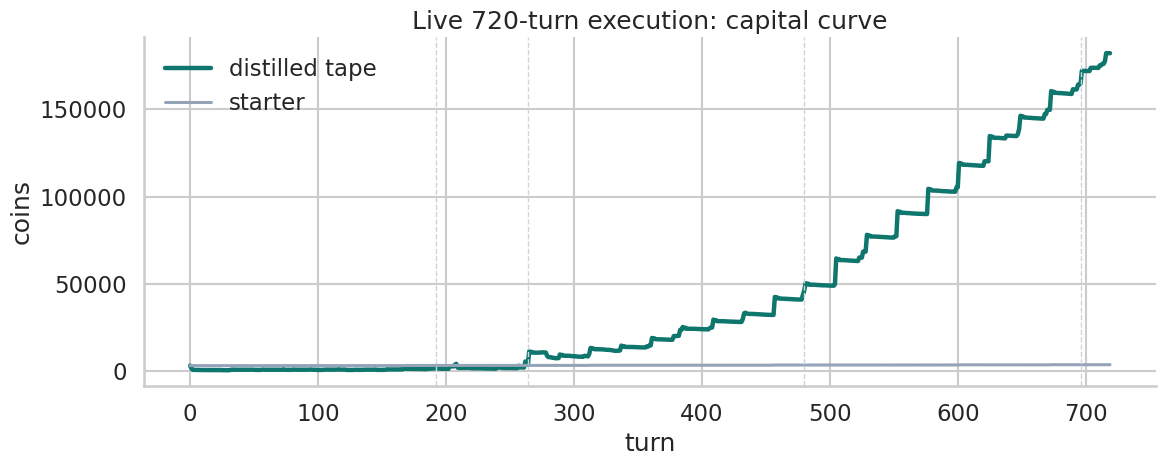

In [14]:
money_a = [float(step[0].observation.farms[0].money) for step in representative.steps]
money_b = [float(step[0].observation.farms[1].money) for step in representative.steps]
turns = np.arange(len(money_a))
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(turns, money_a, lw=3.2, color=COLORS[0], label="distilled tape")
ax.plot(turns, money_b, lw=2.2, color="#94a3b8", label="starter")
for day in (8, 11, 20, 29): ax.axvline(day*24, color="#cbd5e1", ls="--", lw=1)
ax.set(title="Live 720-turn execution: capital curve", xlabel="turn", ylabel="coins")
ax.legend(frameon=False); sns.despine(); plt.tight_layout(); plt.show()


## 6. Package integrity

The competition archive contains exactly one root file, `main.py`. Use this notebook version's **Submit to competition** button and choose `submission.tar.gz`.


In [15]:
ARCHIVE_PATH = MAIN_PATH.parent / "submission.tar.gz"
with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]
print({"artifact": str(ARCHIVE_PATH), "bytes": ARCHIVE_PATH.stat().st_size,
       "sha256": hashlib.sha256(ARCHIVE_PATH.read_bytes()).hexdigest(), "members": ["main.py"]})


{'artifact': '/kaggle/working/submission.tar.gz', 'bytes': 8623, 'sha256': '8379ae7dda302acfc5c8daf9ccffddb679edb2a63aae362b73252293065acbd5', 'members': ['main.py']}


---

## Turn this starter into an adaptive frontier

1. **Behavior-clone by state, not step.** Use public replay observations and actions as supervised examples, then retrieve or predict actions from the current farm state.
2. **Add legality-aware repair.** When a taped action misses, redirect the freed hand to the highest-value nearby care, feed, harvest, water, or drop job.
3. **Condition the market block.** Preserve the tape's capital schedule but size buys and sells from live inventory, price, town demand, and rival exposure.
4. **Ensemble tapes.** Select a schedule by early weed pressure or opponent acreage instead of committing to one episode at step 0.
5. **Keep symmetric gates.** Shared-market ordering makes player position real; every promotion should use both seats and untouched seeds.

The key result is less mystical than it looks: a great Kaggriculture farm is a timed supply chain. This notebook makes one elite public trajectory executable, measurable, and easy to improve. If it saves you days of reverse engineering, an upvote helps other competitors find the evidence and the caveats. 🌾
